In [71]:
import sys
import argparse
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import numpy as np
import pandas as pd



import csv
import gzip
import scipy.io
import numpy as np 

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.pyplot import rc_context


# --- MATPLOTLIB SETTINGS ---
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rc
rc_params = {
    "font.family": "sans-serif", # "text.usetex": True,
    "font.serif" : ['Arial'], # "font.size" : 6,
    "font.weight" : "normal",
    'xtick.labelsize' : 5,
    'ytick.labelsize' : 5,
    'legend.fontsize' : 5,
    'axes.labelsize' : 6,
    'axes.linewidth': 0.8,
    'lines.linewidth' : 1,
    'axes.titlesize' : 7 # figure.titlesize
}
matplotlib.rcParams.update(rc_params)
margins = {  #     vvv margin in inches
    "left"   :     0.2,
    'right' : 1.0,
    'bottom' : 0.15
}
import helper_functions

import warnings
warnings.filterwarnings("ignore")


In [72]:

# --- INIT ---

# which data to use
head_folder = "/".join(os.getcwd().split("/")[:3])
data_head_folder = '%s/Dropbox/aorta_circadian_data/datasets/joint' % head_folder
hvg_to_use = 'prior_knowledge_guided'
cluster_resolution = 0.05
subcluster_resolution = 0.20


# get corresponding paths
adata_path = '%s/adata_qc_filtered.h5ad' % data_head_folder
hvg_folder = '%s/data_annotations/hvg/%s' % (data_head_folder,hvg_to_use)
scvi_res_folder = '%s/scvi_res' % hvg_folder
scvi_mean_embedding_df_path = '%s/scvi_mean_embedding.tsv' % scvi_res_folder
umap_path_out = '%s/scvi_mean_umap_embedding.tsv' % scvi_res_folder


# regular clusters
clustering_folder = '%s/clustering/res_%s' % (scvi_res_folder, str(cluster_resolution))
cluster_df_fileout = '%s/clusters.tsv' % (clustering_folder)


# SMC clusters
subclustering_folder = '%s/subclustering/res_%s' % (clustering_folder,subcluster_resolution)
subcluster_df_fileout = '%s/smc_subclusters.tsv' % (subclustering_folder)



# settings
log10_bf_thresh = 2
frac_circadian_samples_crossing_zero_thresh = 0.05
num_waveform_samples = 300
use_log_prop_fft = True
frac_cell_detected_thresh = 0.1
use_subclusters = False


# folder out
folder_out = '%s/Dropbox/aorta_circadian_data/results/female_ko_misaligned' % head_folder
if use_subclusters:
    folder_out = '%s/smc_subclusters' % folder_out
if not os.path.exists(folder_out):
    os.makedirs(folder_out)


# set the cluster column
if use_subclusters:
    clustering_folder = subclustering_folder
    cluster_df_fileout = subcluster_df_fileout





In [73]:
# --- LOAD THE ADATA ---

import anndata
adata = anndata.read_h5ad(adata_path)

adata



AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'

In [74]:
# --- ADD EMBEDDINGS TO ADATA ---



# ** load embeddings and clusters **
scvi_mean_embedding_df = pd.read_table(scvi_mean_embedding_df_path,sep='\t',index_col='barcode')
umap_embedding_df = pd.read_table(umap_path_out,sep='\t',index_col='barcode')
cluster_df = pd.read_table(cluster_df_fileout,sep='\t',index_col='index')
subcluster_df = pd.read_table(subcluster_df_fileout,sep='\t',index_col='index')


# ** make sure everything in the same order
adata = adata[list(scvi_mean_embedding_df.index)]
umap_umap_embedding_df = umap_embedding_df.loc[list(scvi_mean_embedding_df.index)]
cluster_df = cluster_df.loc[list(scvi_mean_embedding_df.index)]
subcluster_df = subcluster_df.loc[list(scvi_mean_embedding_df.index)]


# ** add embeddings **
adata.obsm["X_scVI"] = np.array(scvi_mean_embedding_df)
adata.obsm["X_scVI_umap"] = np.array(umap_embedding_df)
if use_subclusters:
    adata.obs["cluster"] = np.array(cluster_df['smc_subcluster'])
else:
    adata.obs["cluster"] = np.array(cluster_df['leiden_scvi_cluster'])
adata



AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description', 'cluster'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'
    obsm: 'X_scVI', 'X_scVI_umap'

In [75]:
# --- GET UNIQUE DESCRIPTOINS / CELL TYPES AND SET THE CLUSTER - CELL_TYPE DICT ---

# ** get the unique descriptions **
descriptions = list(adata.obs['description'].unique())

# ** get the unique clusters **
clusters = sorted(list(adata.obs['cluster'].unique()))
clusters = list(filter(lambda x: ~np.isnan(x),clusters)) # get rid of NaN cluster (only relevant for SMC subcluster)
clusters = list(map(lambda x: int(x),clusters))
clusters = sorted(clusters)


# ** get the cluster cell type dict **
if use_subclusters:
    smc_subcluster_cell_type_names = list(map(lambda x: "SMC%s" % int(x), clusters))
    cluster_cell_type_dict = dict(zip(clusters,
                                      smc_subcluster_cell_type_names))
else:
    cluster_cell_type_dict = dict(zip(sorted(list(adata.obs['cluster'].unique())),
                                      ['SMC','Fibroblast','Endothelial', 'Macrophage', 'Erythrocyte', 'T', 'Oligodendrocyte', 'Endothelial2', 'Neuron']))



    

In [76]:
# --- LIMIT CLUSTERS ---

if use_subclusters:
    clusters = [0,1,2,3,4,5]
else:
    clusters = [0,1,2,3]


In [77]:
# --- MAKE THE FOLDER OUT ---

if not os.path.exists(folder_out):
    os.makedirs(folder_out)


In [78]:
# --- MAKE THE FOLDER OUTS ---

# head folder
reg_head_folder = '%s/nonparametric_reg' % clustering_folder
if not os.path.exists(reg_head_folder):
    os.makedirs(reg_head_folder)


# subfolders for each cluster / condition combo
cluster_description_folder_out_dict = {}
for cluster in clusters:
    cluster_reg_folder = '%s/cluster_%s' % (reg_head_folder,cluster)
    if not os.path.exists(cluster_reg_folder):
        os.makedirs(cluster_reg_folder)
    for description in descriptions:
        cluster_description_reg_folder = '%s/%s' % (cluster_reg_folder,description)
        if not os.path.exists(cluster_description_reg_folder):
            os.makedirs(cluster_description_reg_folder)
            
        # update dict
        if cluster not in cluster_description_folder_out_dict:
            cluster_description_folder_out_dict[cluster] = {}
        cluster_description_folder_out_dict[cluster][description] = cluster_description_reg_folder

    
    

In [79]:
# --- LOAD THE GENES TO ESTIMATE ---

genes_to_est_fileout = '%s/genes_to_est.txt' % reg_head_folder
with open(genes_to_est_fileout) as file_obj:
    reg_genes_to_est = list(map(lambda x: x.replace('\n',""), file_obj.readlines()))
    
    
len(reg_genes_to_est)

22193

In [80]:
# --- SET DESCRIPTION TO male aligned bmal1-control ---

description = 'female aligned bmal1-ko'


In [81]:
# --- GET THE METRIC DF'S FOR EACH CLUSTER ---
import tqdm

cluster_metric_dfs = []
for cluster in tqdm.tqdm(clusters):
    
    
    # ** load metric df **
    metric_path = '%s/de_novo_metrics.tsv' % cluster_description_folder_out_dict[cluster][description]
    metric_df = pd.read_table(metric_path,index_col='gene',sep='\t')
    
    # ** load gene parameters **
    gene_log_alpha_path = '%s/gene_log_alpha.tsv' % cluster_description_folder_out_dict[cluster][description]
    gene_log_beta_path = '%s/gene_log_beta.tsv' % cluster_description_folder_out_dict[cluster][description]
    gene_log_min_max_path = '%s/log_min_max.tsv' % cluster_description_folder_out_dict[cluster][description]
    gene_log_alpha_df = pd.read_table(gene_log_alpha_path,sep='\t',index_col='gene')
    gene_log_beta_df = pd.read_table(gene_log_beta_path,sep='\t',index_col='gene')
    gene_log_min_max_df = pd.read_table(gene_log_min_max_path,sep='\t',index_col='gene')
    
    # ** compute the expected waveforms **
    gene_expected_beta = np.array((np.exp(gene_log_alpha_df) / (np.exp(gene_log_alpha_df) + np.exp(gene_log_beta_df))))
    gene_log_min = np.array(gene_log_min_max_df['log_min']).reshape(-1,1)
    gene_log_max = np.array(gene_log_min_max_df['log_max']).reshape(-1,1)
    gene_expected_log_prop = (gene_expected_beta * (gene_log_max - gene_log_min)) + gene_log_min
    
    # ** compute the gene mesors **
    gene_expected_mesor = np.mean(gene_expected_log_prop,axis=1)
    metric_df['expected_mesor'] = gene_expected_mesor
    
    # ** compute the expected acrophases and amplitudes **
    num_grid_points = 4
    fft_res = np.fft.fft(gene_expected_log_prop,axis=1)
    freqs = np.fft.fftfreq(num_grid_points,d=24.0/num_grid_points)
    periods = 1 / freqs
    amps = abs(fft_res)
    circadian_index = np.where(np.isin(periods,[24]))[0].item()
    expected_acrophase = ((2 * np.pi) - np.arctan2(fft_res[:,circadian_index].imag,fft_res[:,circadian_index].real) % (2 * np.pi)).flatten()
    expected_amp = amps[:,circadian_index,].flatten()
    metric_df['expected_acrophase'] = expected_acrophase
    metric_df['expected_amp'] = expected_amp
    
    # ** compute fraction detected **
    sub_adata = adata[adata.obs['cluster'] == cluster]
    sub_adata = sub_adata[:,metric_df.index]
    val = np.sum(sub_adata.X > 0,axis=0)
    val = np.array(val).flatten()
    sub_adata.var['num_cell_detected'] = val
    sub_adata.var['frac_cell_detected'] = val / sub_adata.shape[0]
    metric_df['frac_cell_detected'] = np.array(sub_adata.var['frac_cell_detected'])
    metric_df['num_cell_detected'] = np.array(sub_adata.var['num_cell_detected'])

    
    
    # ** add **
    cluster_metric_dfs.append(metric_df)
    


100%|█████████████████████████████████████████████| 4/4 [00:43<00:00, 10.80s/it]


In [82]:
# --- FILTER THE CLUSTER METRIC DF'S BASED ON FRACTION CELLS DETECTED (BUT KEEP CLOCK AND UBIQ GENES) ----


# ** load clock and ubiq genes **
clock_and_ubiq_path = '%s/Desktop/tempo/data/core_clock_and_ubiq_genes.txt' % head_folder
clock_and_ubiq_genes = np.array(pd.read_table(clock_and_ubiq_path,header=None).iloc[:,0])

# ** get hemoglobin genes **
hemoglobin_genes = list(filter(lambda x: x[:2] == 'Hb' and '-' in x, adata.var_names))

# ** filter **
cluster_metric_dfs = list(map(lambda x: x[(x['frac_cell_detected'] >= frac_cell_detected_thresh) | np.isin(x.index,clock_and_ubiq_genes)], cluster_metric_dfs))
cluster_metric_dfs = list(map(lambda x: x[~np.isin(x.index,hemoglobin_genes)], cluster_metric_dfs))





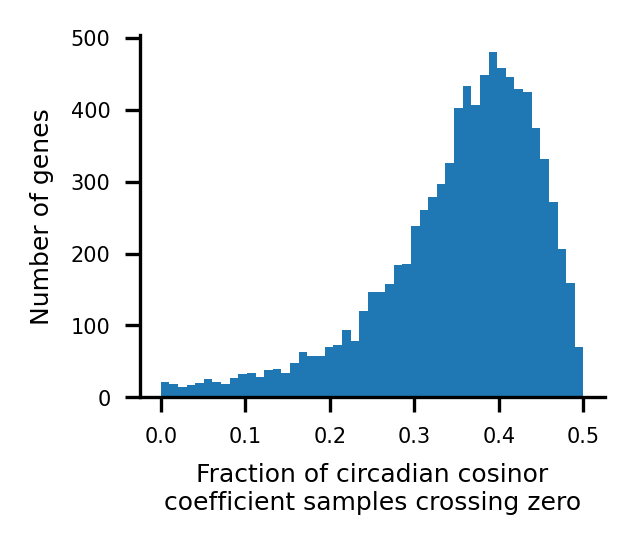

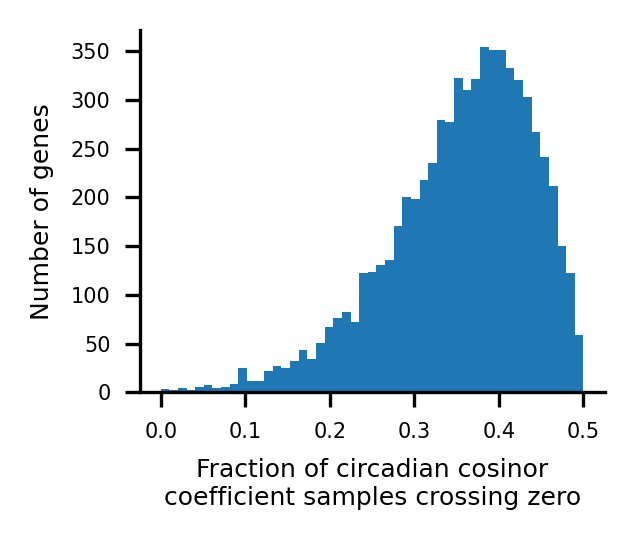

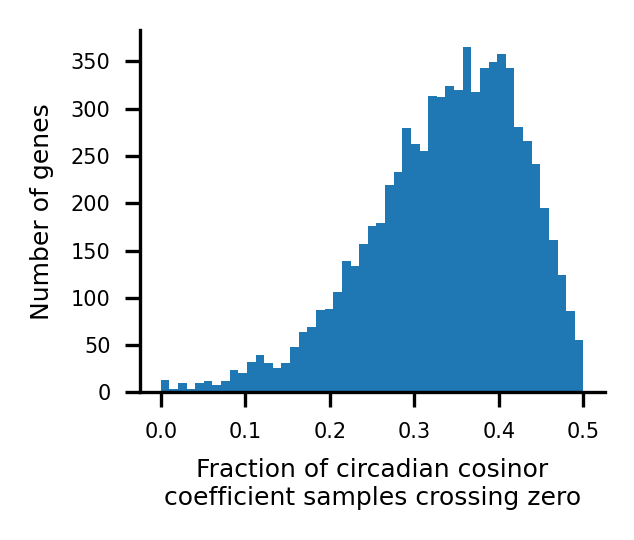

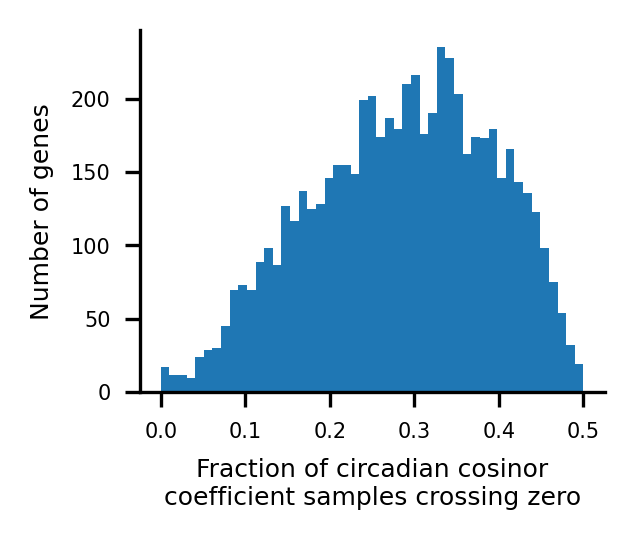

In [83]:
# --- LOOK AT THE CYCLER STATISTIC DISTRIBUTION IN EACH CELL TYPE ---


for cluster, metric_df in enumerate(cluster_metric_dfs):
    
    fig, ax = plt.subplots(figsize = (2,1.6),dpi=300)
    plt.hist(metric_df['frac_circadian_samples_crossing_zero'],bins=np.linspace(0,0.5,50))
    sns.despine()
    plt.xlabel("Fraction of circadian cosinor\ncoefficient samples crossing zero")
    plt.ylabel("Number of genes")
    subfolder_out = '%s/cycler_statistic_distribution' % folder_out
    if not os.path.exists(subfolder_out):
        os.makedirs(subfolder_out)
    fileout = '%s/cluster_%s.pdf' % (subfolder_out,cluster_cell_type_dict[cluster])
    plt.savefig(fileout,bbox_inches='tight')
    plt.show()



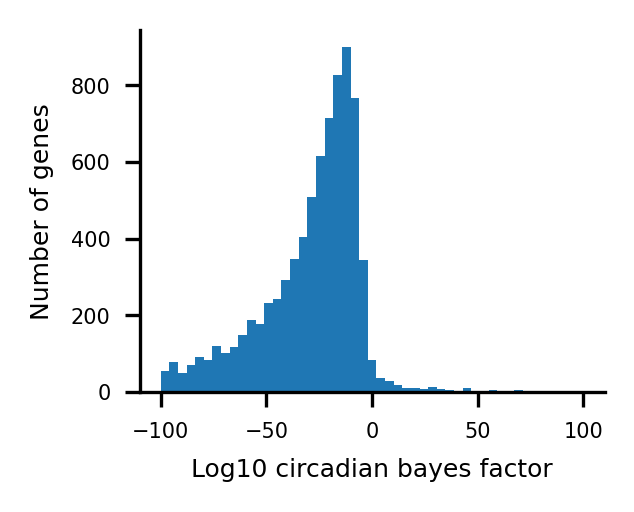

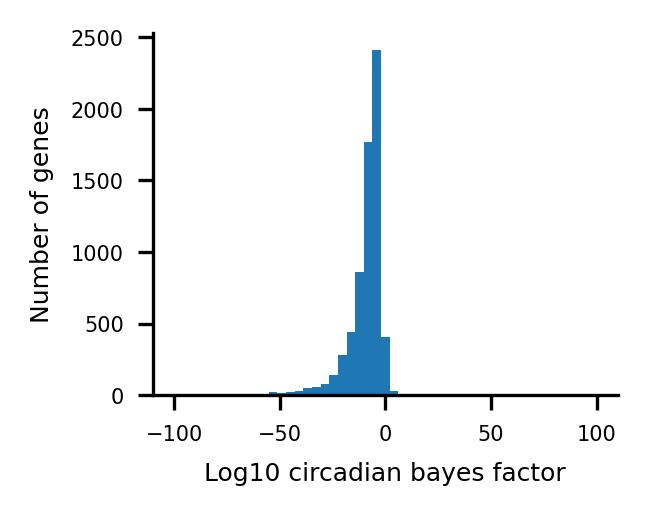

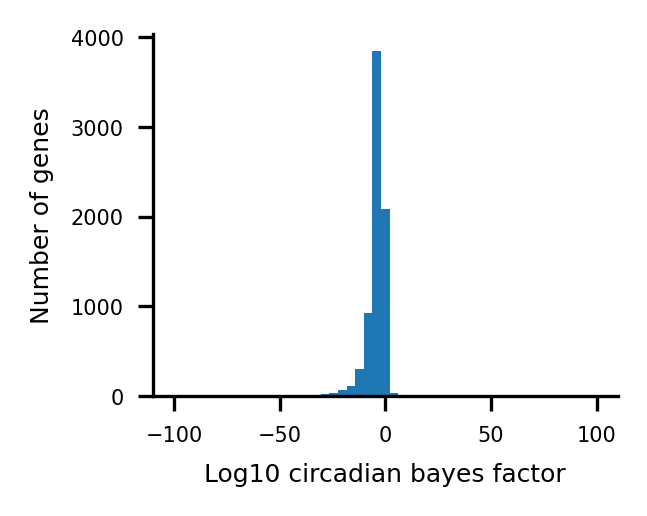

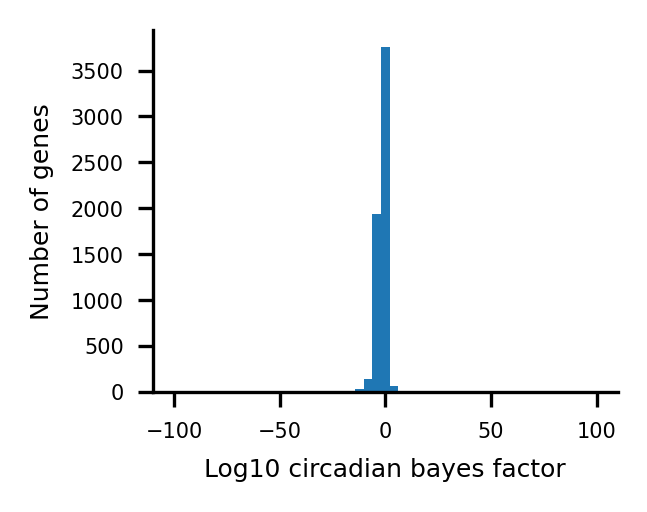

In [84]:
# --- LOOK AT THE BF CYCLER STATISTIC DISTRIBUTION IN EACH CELL TYPE ---

    
for cluster, metric_df in enumerate(cluster_metric_dfs):
    
    fig, ax = plt.subplots(figsize = (2,1.6),dpi=300)
    plt.hist(metric_df['waveform_over_circadian_component_subtracted_log10_bf'], bins=np.linspace(-100,100,50)) # bins=np.linspace(0,0.5,50)
    sns.despine()
    plt.xlabel("Log10 circadian bayes factor")
    plt.ylabel("Number of genes")
    plt.show()




In [85]:
# --- GET CYCLERS IN EACH ---


cluster_cycler_metric_dfs = []
for cluster in clusters:
    print(cluster)

    # get the corresponding metric DF for the cluster
    cluster_cycler_metric_df = cluster_metric_dfs[cluster][cluster_metric_dfs[cluster]['waveform_over_circadian_component_subtracted_log10_bf'] >= log10_bf_thresh]
    # cluster_cycler_metric_df = cluster_metric_dfs[cluster][cluster_metric_dfs[cluster]['frac_circadian_samples_crossing_zero'] <= frac_circadian_samples_crossing_zero_thresh]
    cluster_cycler_metric_df = cluster_cycler_metric_df.sort_values('waveform_over_circadian_component_subtracted_log10_bf',ascending=False)
    cluster_cycler_metric_dfs.append(cluster_cycler_metric_df)










0
1
2
3


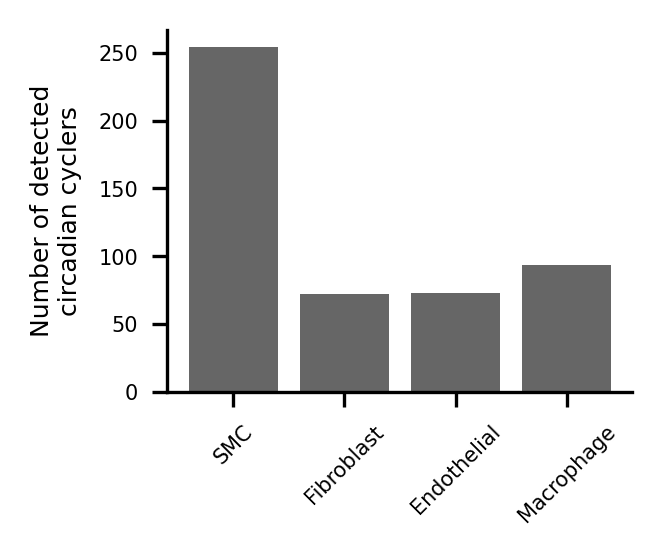

In [86]:
# --- HOW MANY CYCLERS ARE THERE IN EACH CELL TYPE IN MALE? ---

# ** get the number of cyclers in each **
num_cyclers_list = []
for cluster_cycler_metric_df in cluster_cycler_metric_dfs:
    num_cyclers_list.append(len(cluster_cycler_metric_df))

    
    
# ** viz **
fig, ax = plt.subplots(figsize = (2,1.6),dpi=300)
plt.bar(clusters,num_cyclers_list,color='k',alpha=0.6)
# plt.xticks(clusters,['SMC','Fibroblast', 'Endothelial', 'Macrophage', 'Unknown1','Unknown2','Unknown3'],rotation=45)
plt.xticks(clusters,list(map(lambda x: cluster_cell_type_dict[x],clusters)),rotation=45)
sns.despine()
plt.ylabel("Number of detected\ncircadian cyclers")
fileout = '%s/num_cyclers_per_cluster.pdf' % folder_out
plt.savefig(fileout,bbox_inches='tight')
plt.show()









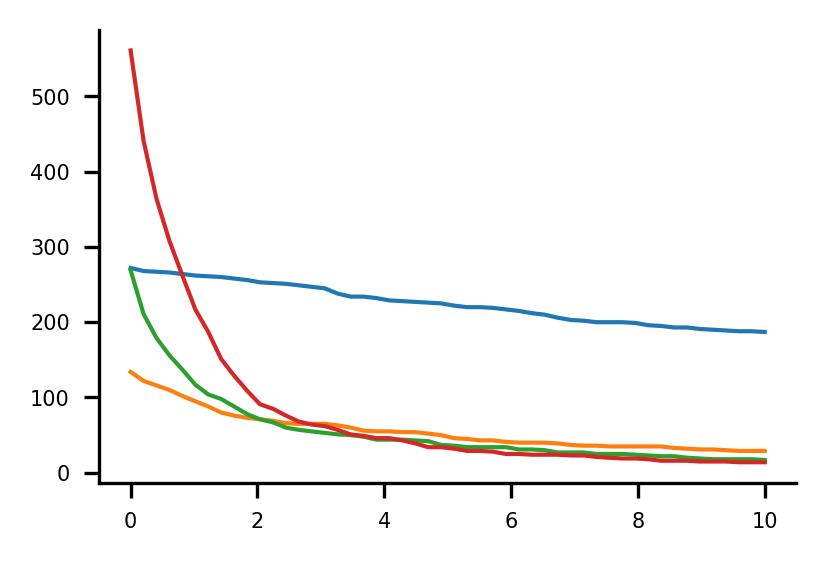

In [87]:
# --- LOOK AT HOW NUMBER OF CYCLERS IS SENSITIVE ON THRESHOLD IN EACH CELL TYPE ---


# ** get the max BF across cell types **
max_log10_bf_thresh = -1
for metric_df in cluster_metric_dfs:
    val = np.max(metric_df['waveform_over_circadian_component_subtracted_log10_bf'])
    if val > max_log10_bf_thresh:
        max_log10_bf_thresh = val

        
# ** set the grid **
log10_bf_thresh_grid = np.linspace(0,10)

# ** viz **
fig,ax=plt.subplots(figsize=(3,2),dpi=300)
for metric_df in cluster_metric_dfs:
    num_cyclers_per_thresh = []
    for temp_log10_bf_thresh in log10_bf_thresh_grid:
        cycler_metric_df = metric_df[metric_df['waveform_over_circadian_component_subtracted_log10_bf'] >= temp_log10_bf_thresh]
        num_cyclers_per_thresh.append(cycler_metric_df.shape[0])
    plt.plot(log10_bf_thresh_grid,num_cyclers_per_thresh)
sns.despine()
plt.show()
        



In [88]:
# --- WRITE OUT THE CYCLERS FOR EACH ---



for cluster in clusters:
    print(cluster)

    # get the corresponding metric DF for the cluster
    cluster_cycler_metric_df = cluster_cycler_metric_dfs[cluster]
    
    # sort
    cluster_cycler_metric_df = cluster_cycler_metric_df.sort_values(['waveform_over_circadian_component_subtracted_log10_bf'],ascending=False)


    # make the subfolder and write
    subfolder_out = '%s/cyclers' % (folder_out)
    if not os.path.exists(subfolder_out):
        os.makedirs(subfolder_out)
    fileout = '%s/cluster_%s_cyclers.tsv' % (subfolder_out,cluster_cell_type_dict[cluster])
    cluster_cycler_metric_df.to_csv(fileout,sep='\t')
    









0
1
2
3


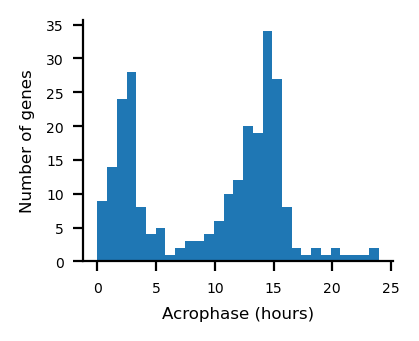

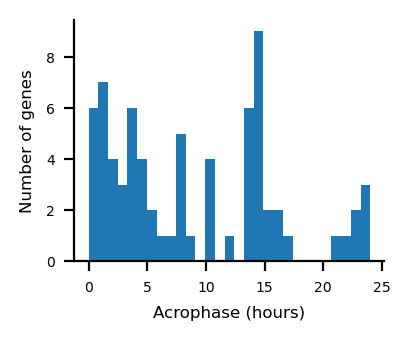

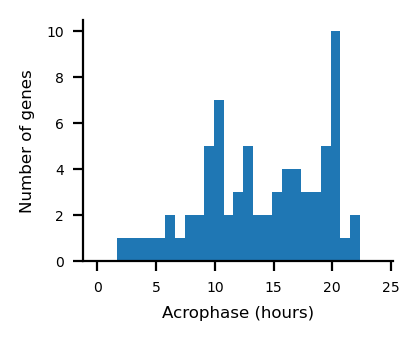

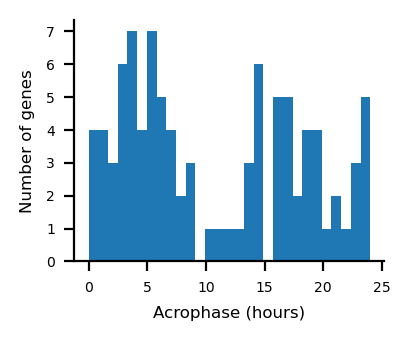

In [89]:
# --- LOOK AT THE ACROPHASE DISTRIBUTION FOR CYCLERS ---

for cluster,cluster_cycler_metric_df in zip(clusters,cluster_cycler_metric_dfs):
    
    fig,ax=plt.subplots(figsize=(2,1.6),dpi=200)
    plt.hist((cluster_cycler_metric_df['expected_acrophase'] / np.pi) * 12.0,bins=np.linspace(0,24,30))
    sns.despine()
    plt.xlabel("Acrophase (hours)")
    plt.ylabel("Number of genes")
    fileout = '%s/cluster_%s_cycler_acrophase_distribution.pdf' % (subfolder_out,cluster_cell_type_dict[cluster])
    plt.savefig(fileout,bbox_inches='tight')
    plt.show()


Dropping 96 keys
Dropping 102 gene sets based on min size threshold
60
90
83
37
33
58
96
129
106
39
12
26
Dropping 183 keys
Dropping 104 gene sets based on min size threshold
32
37
41
27
20
20
30
30
28
14
12
22
Dropping 154 keys
Dropping 118 gene sets based on min size threshold
10
13
21
32
40
51
48
37
32
35
30
19
Dropping 113 keys
Dropping 138 gene sets based on min size threshold
61
82
86
81
62
38
22
35
44
53
45
51


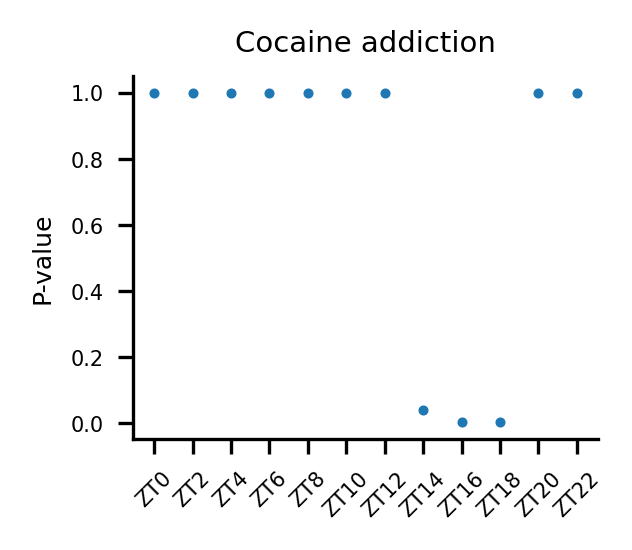

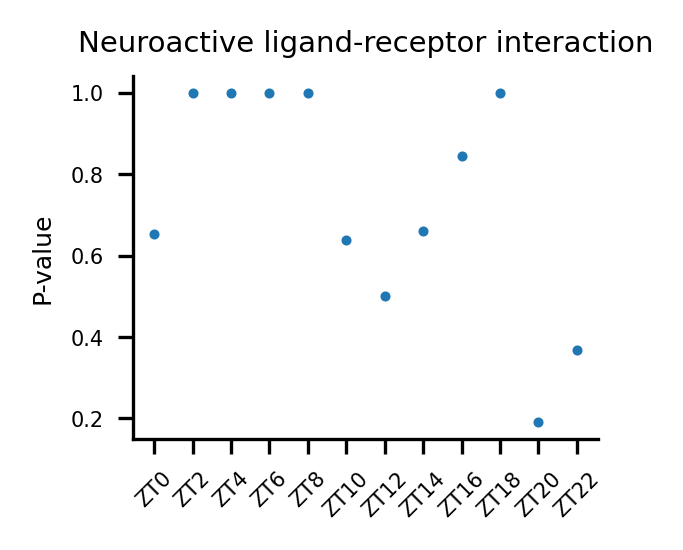

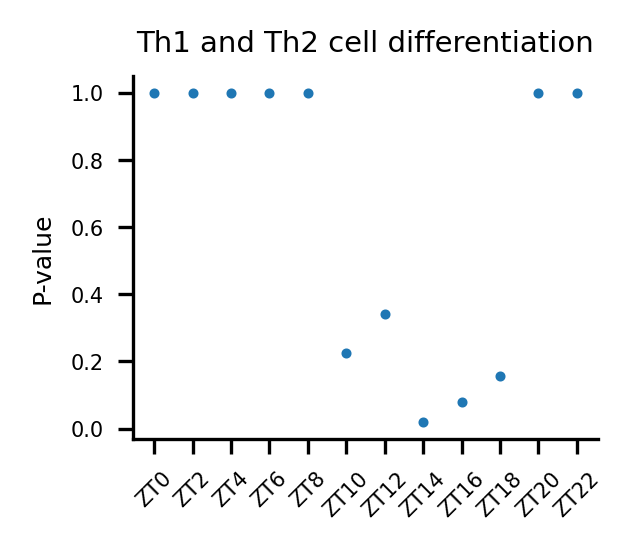

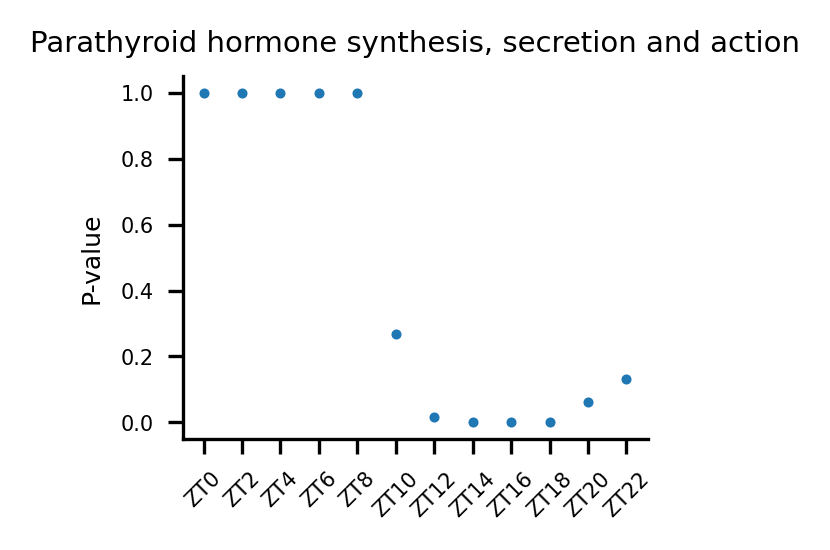

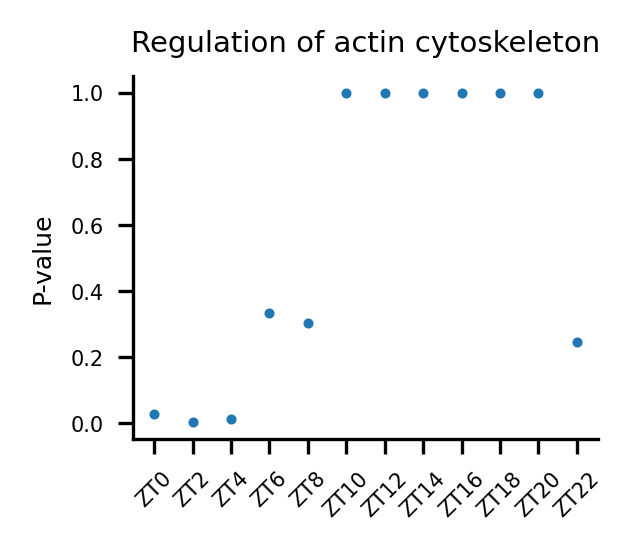

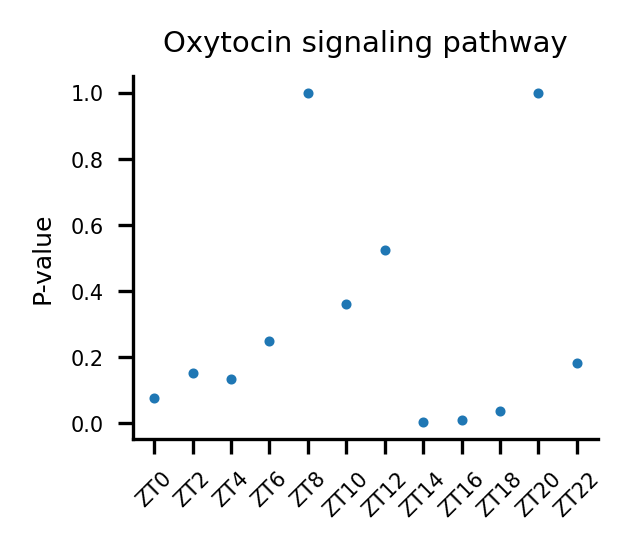

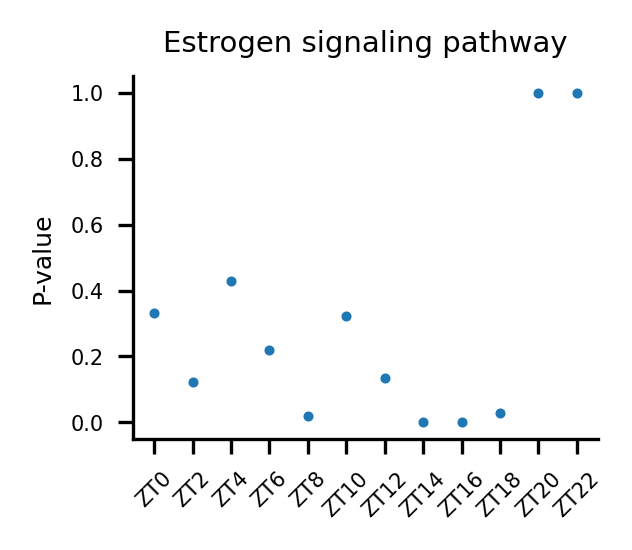

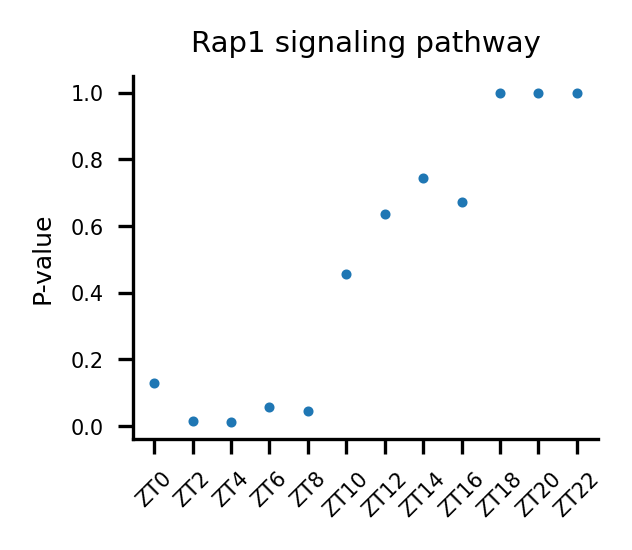

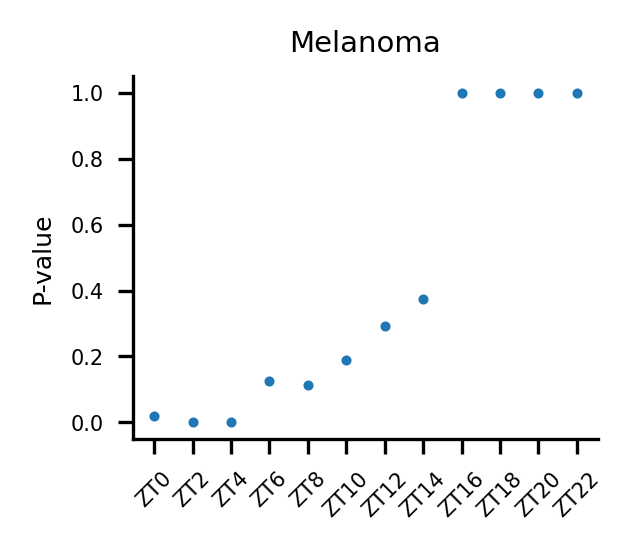

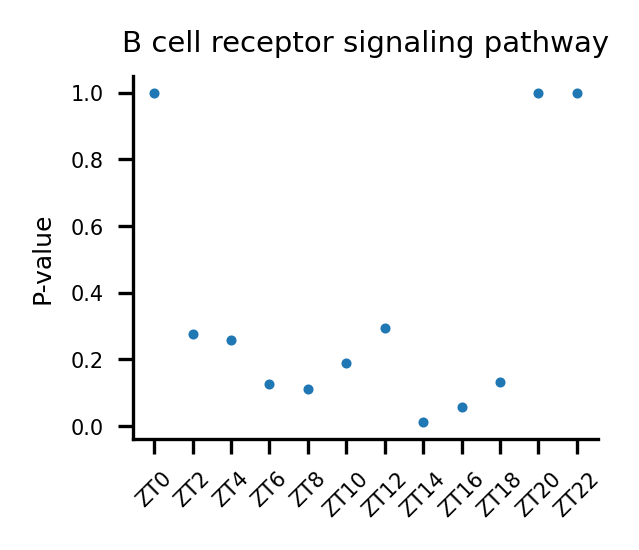

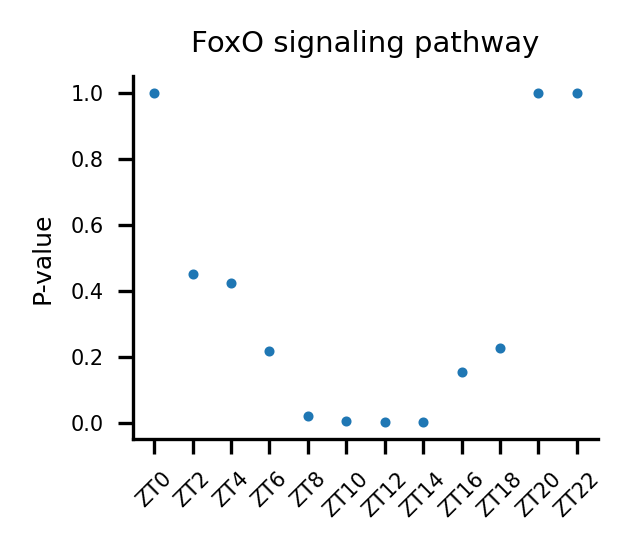

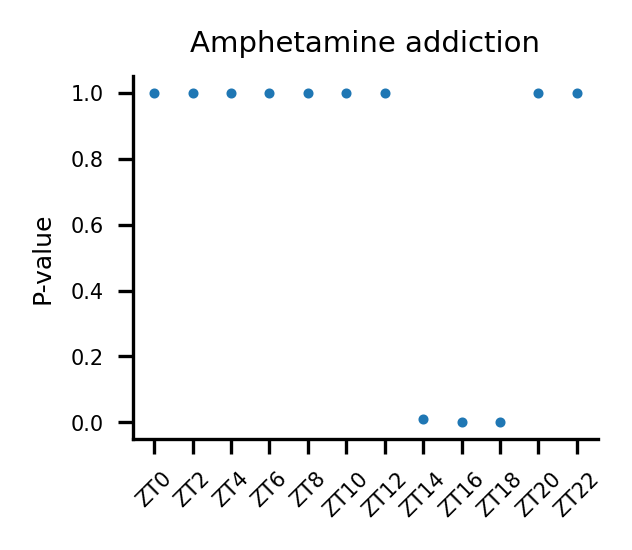

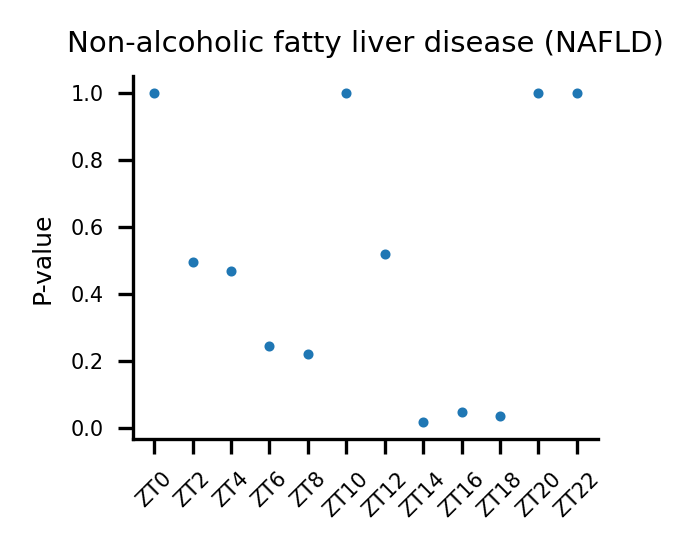

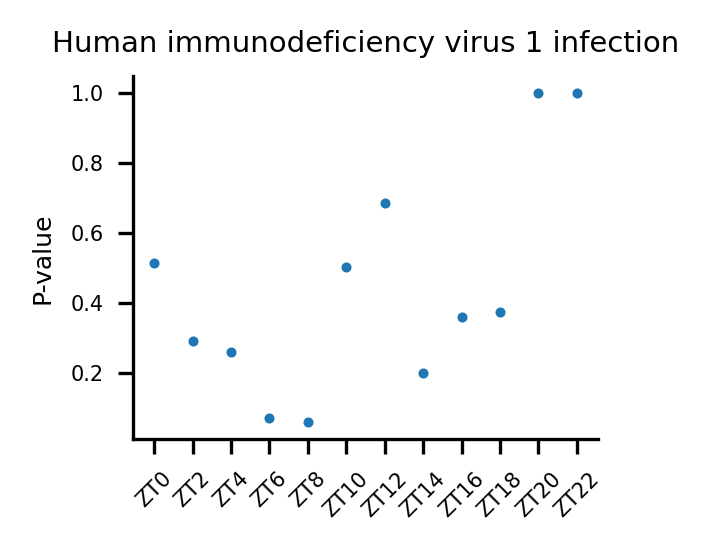

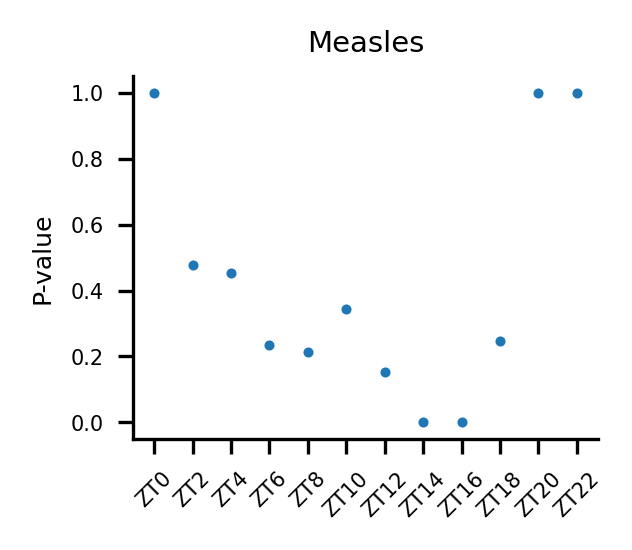

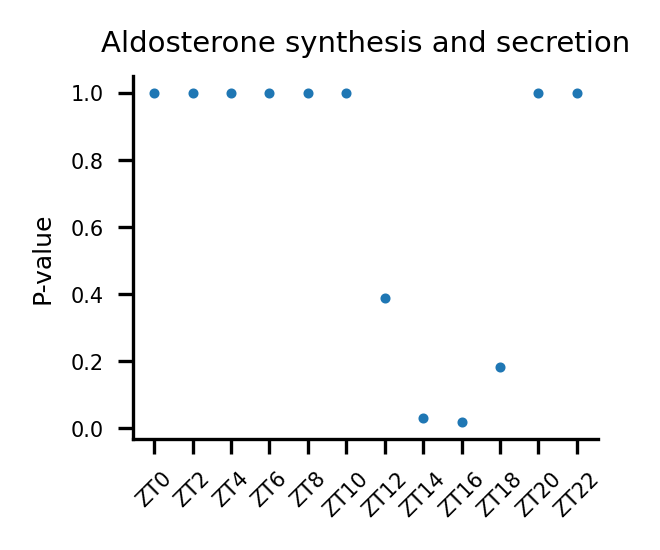

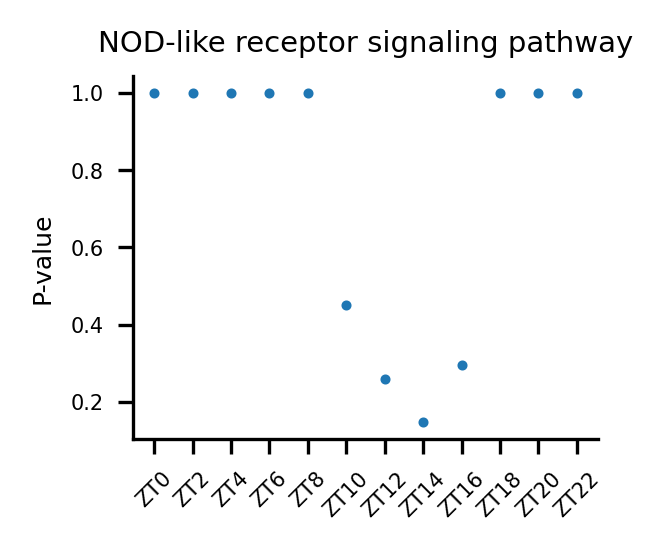

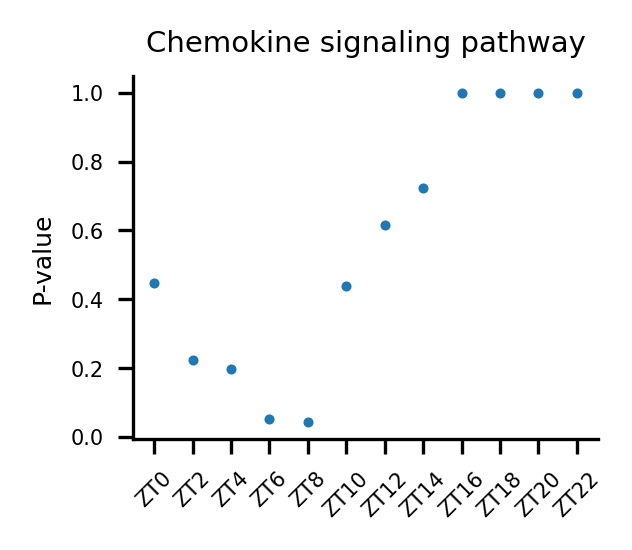

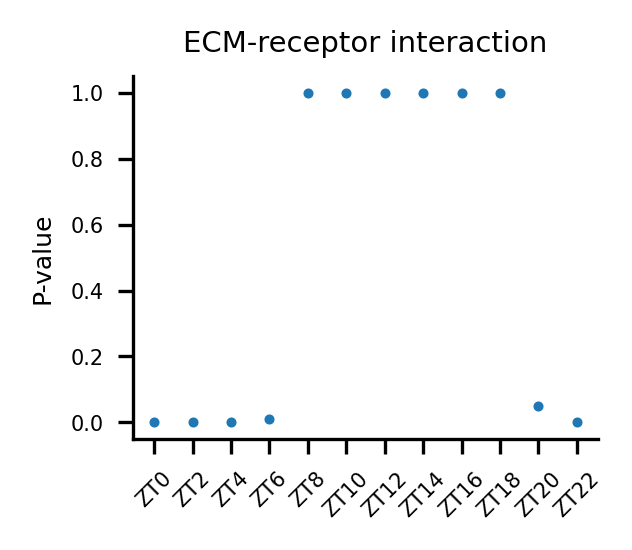

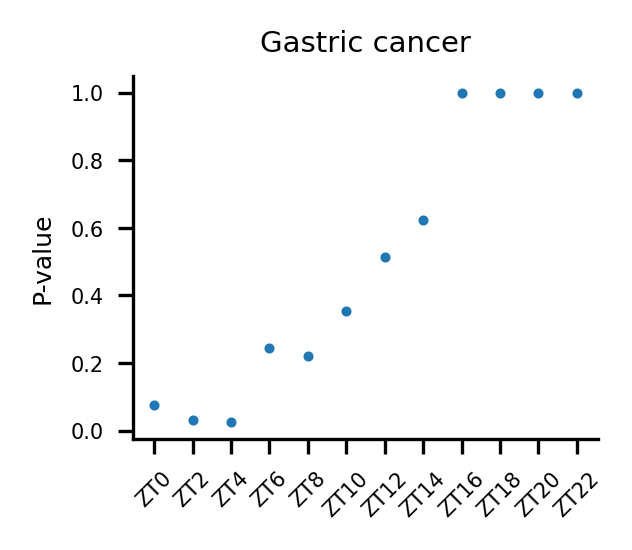

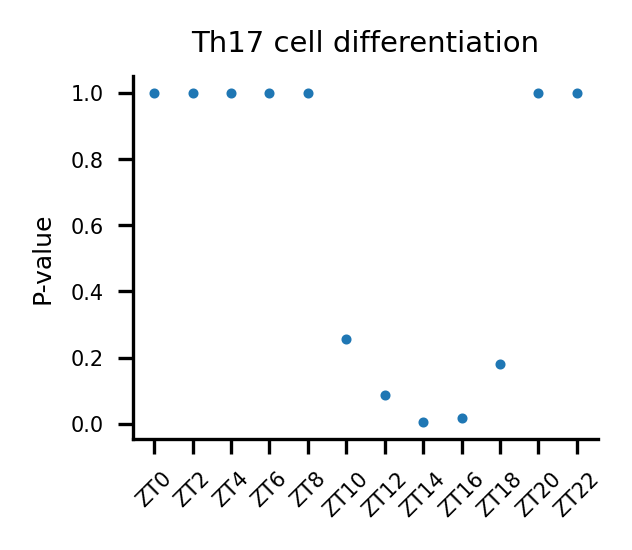

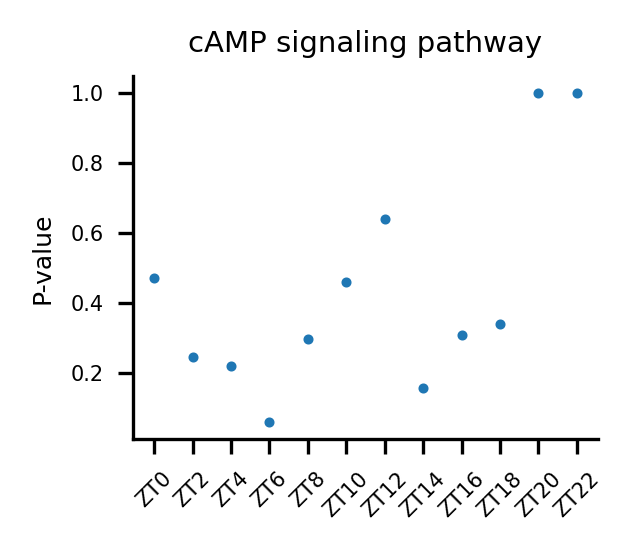

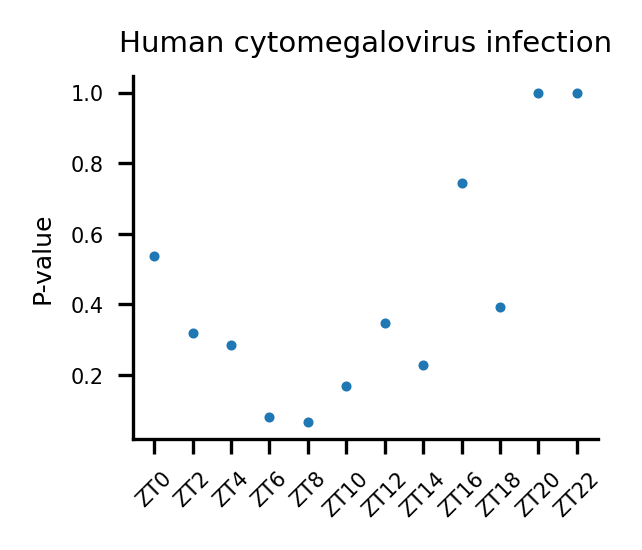

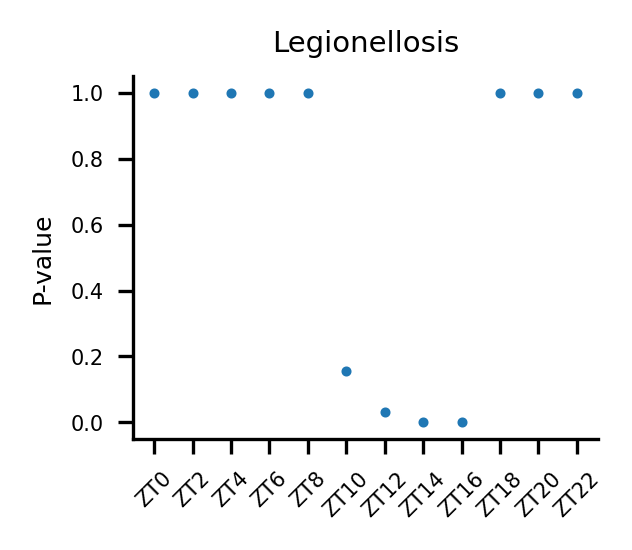

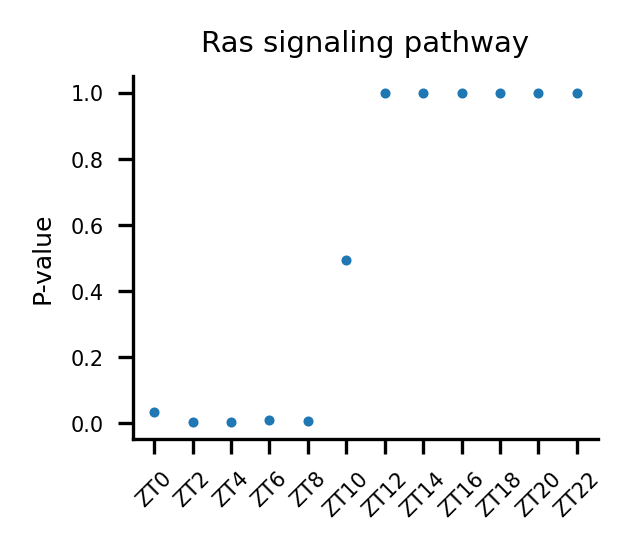

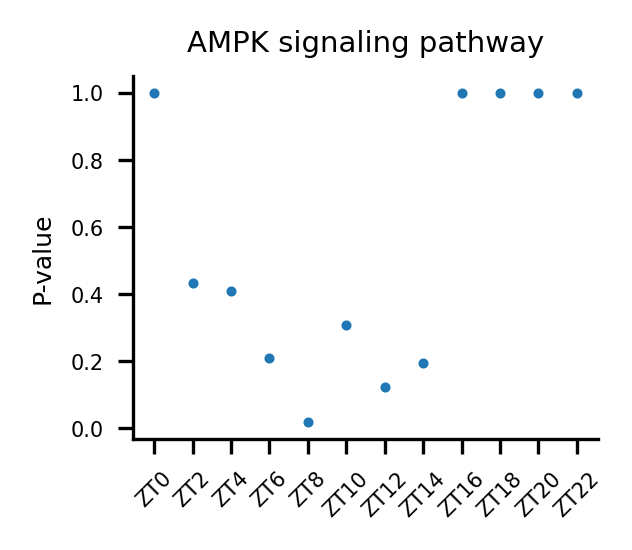

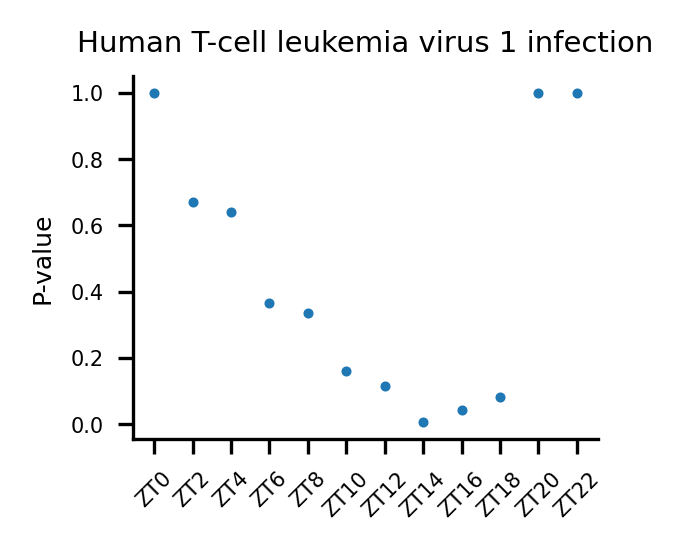

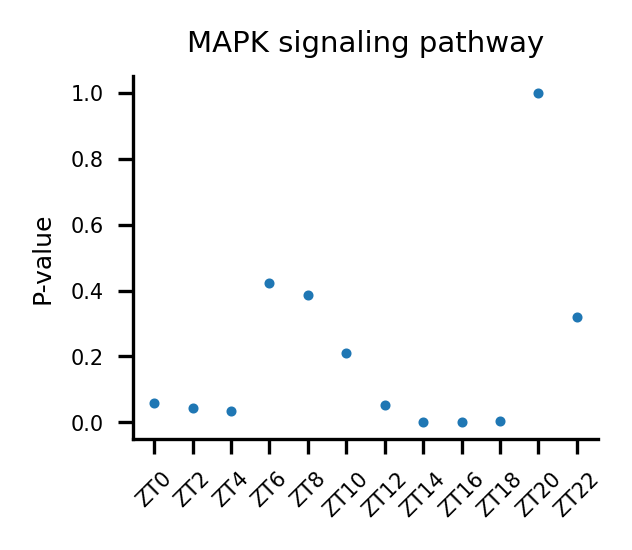

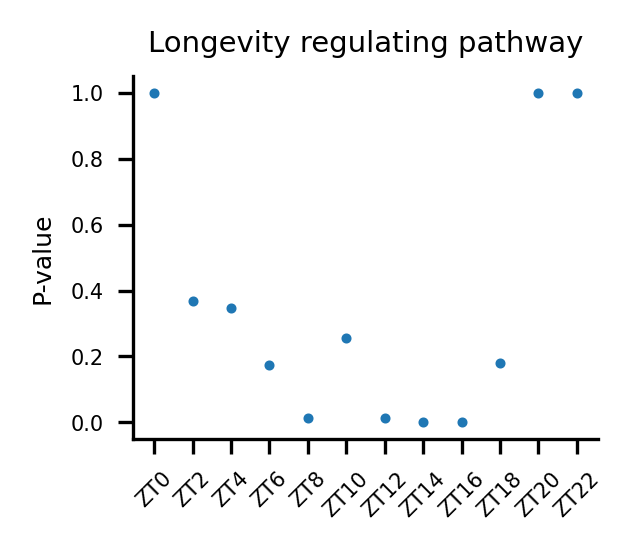

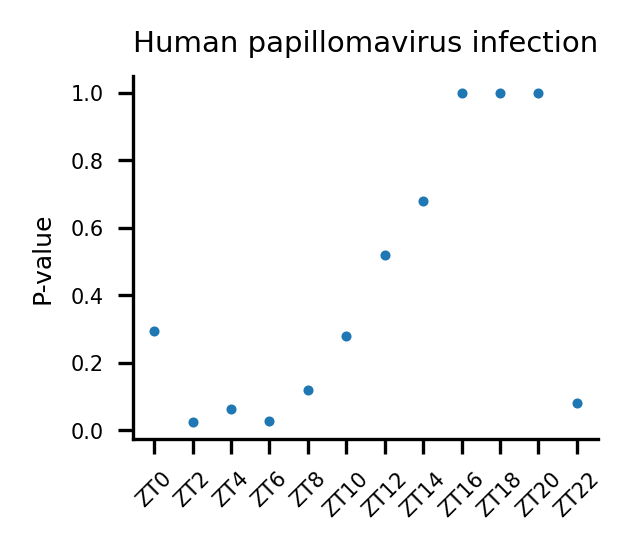

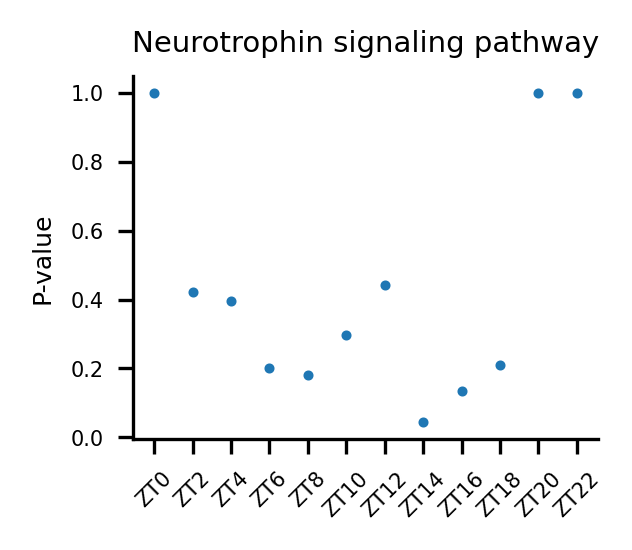

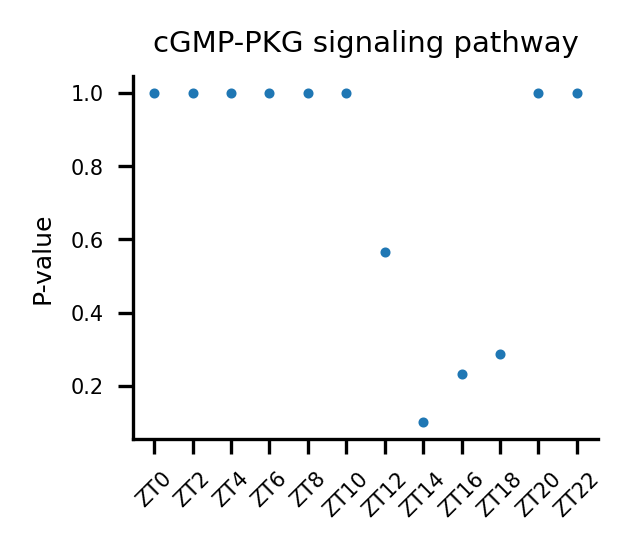

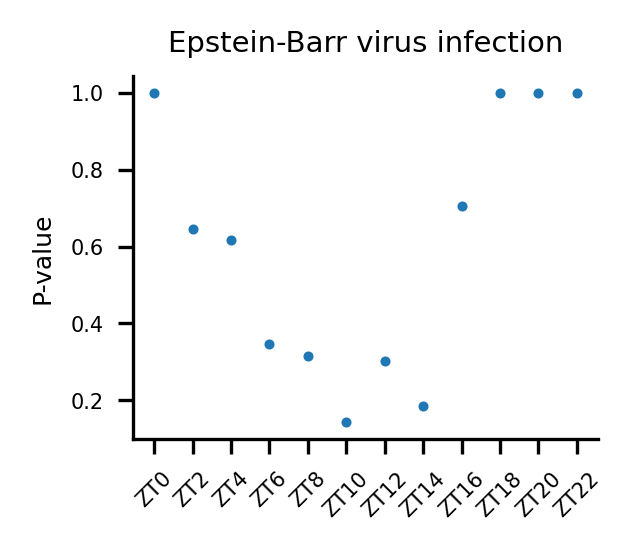

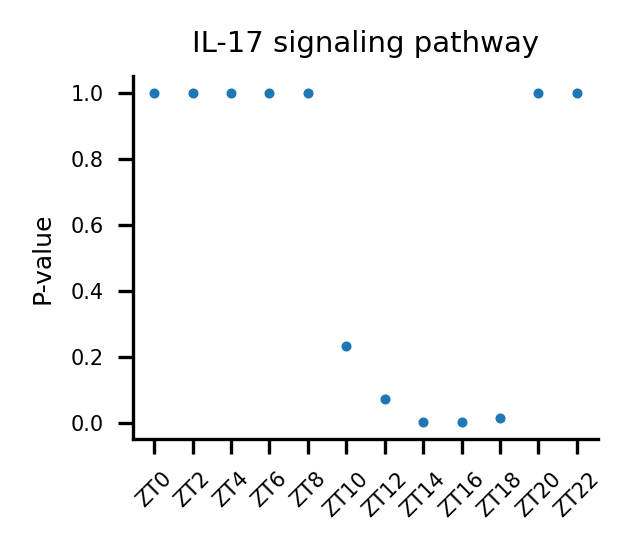

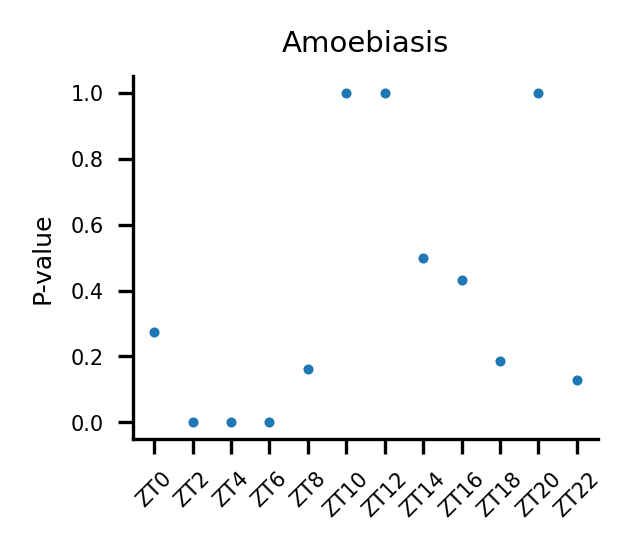

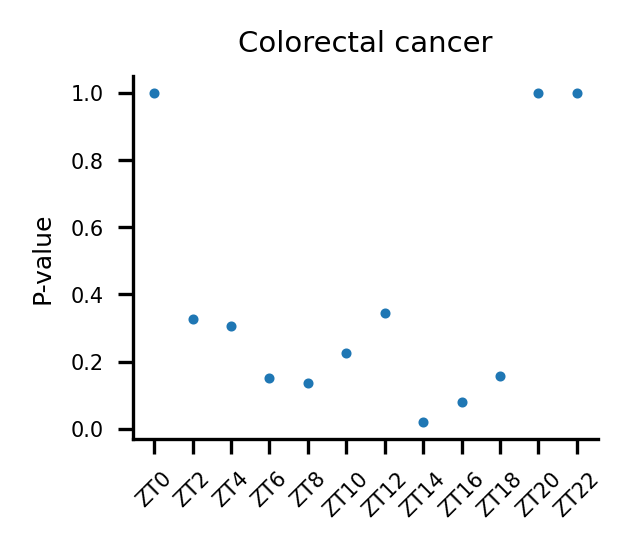

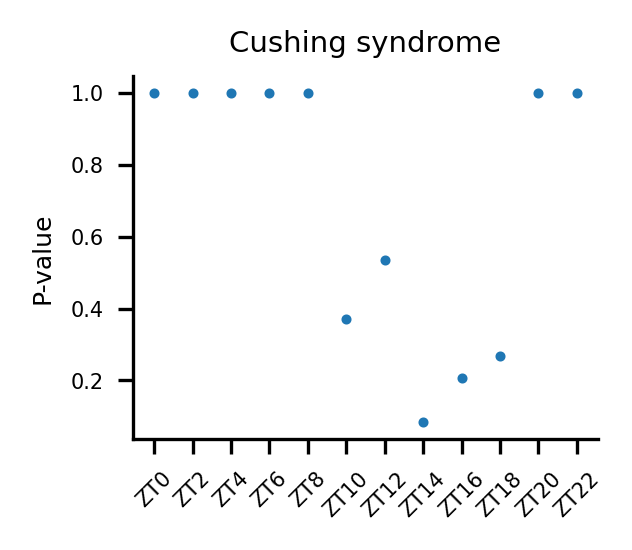

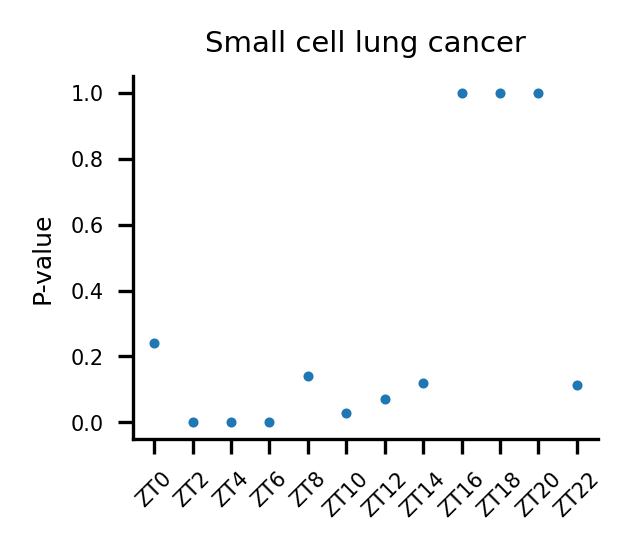

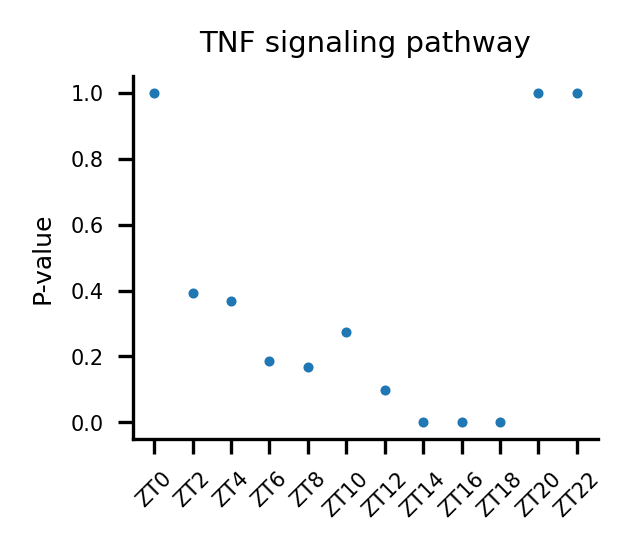

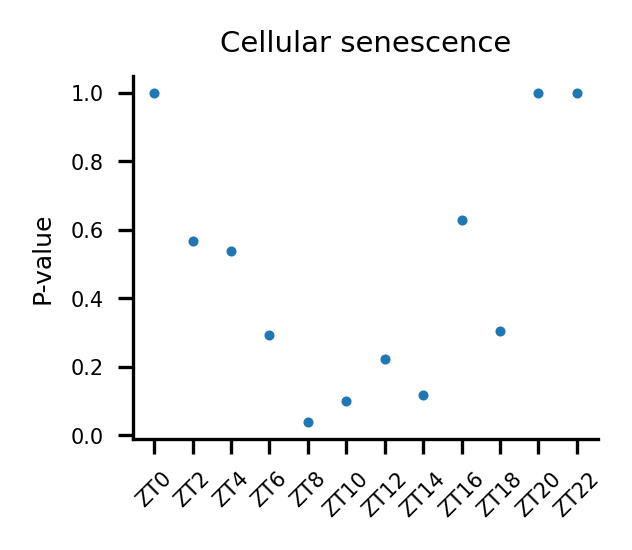

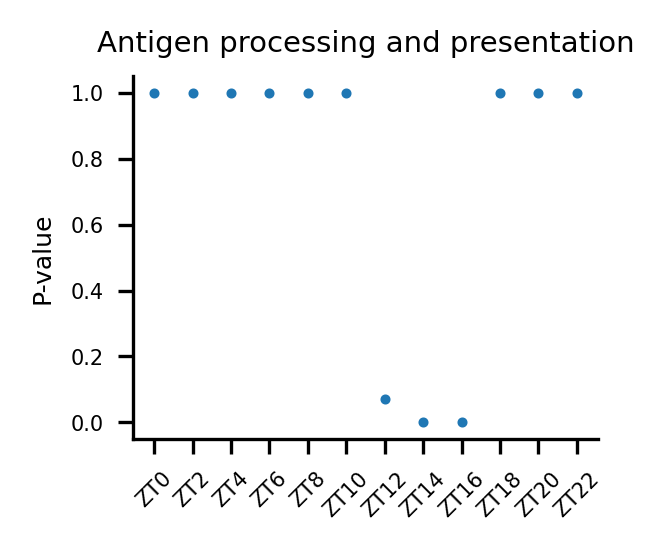

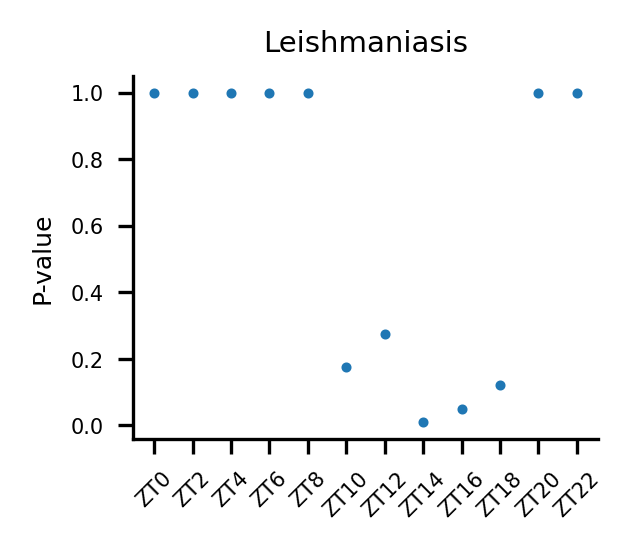

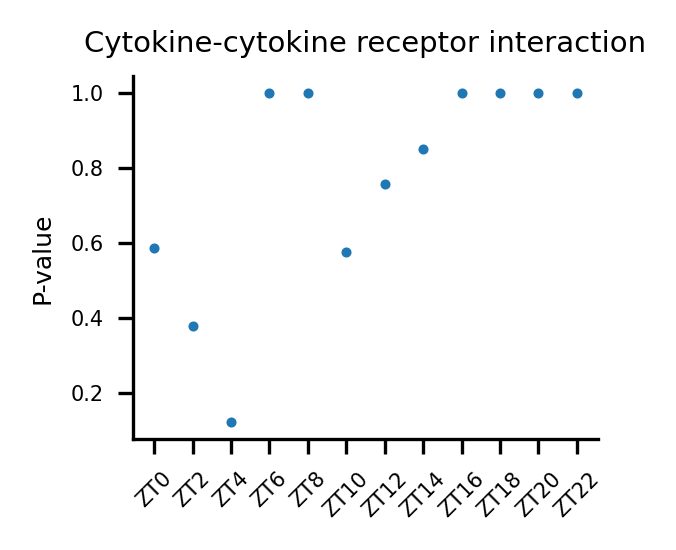

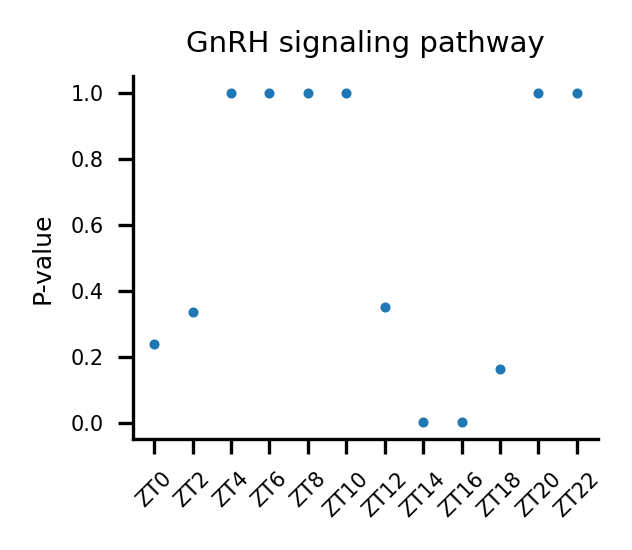

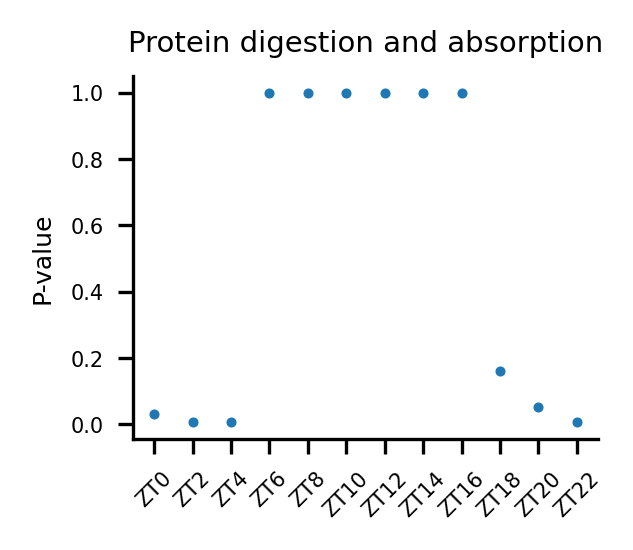

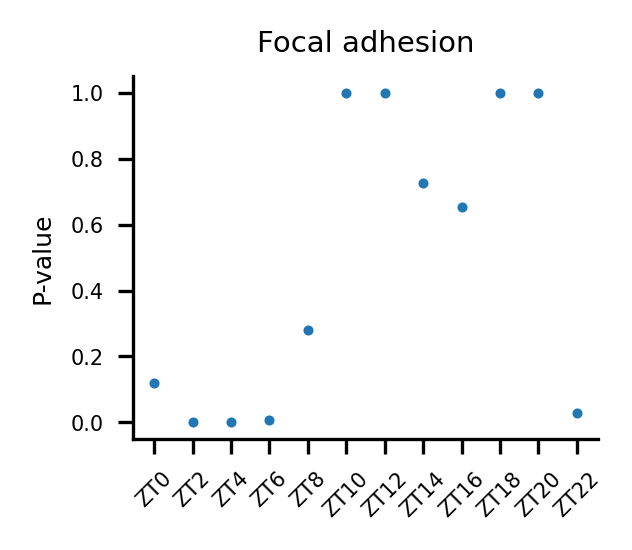

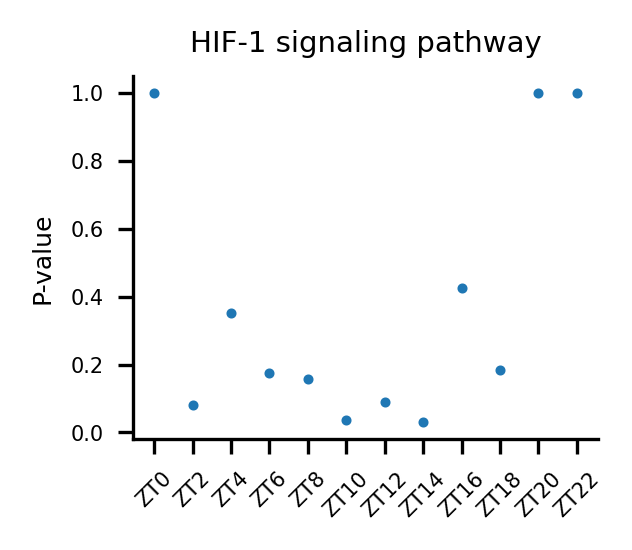

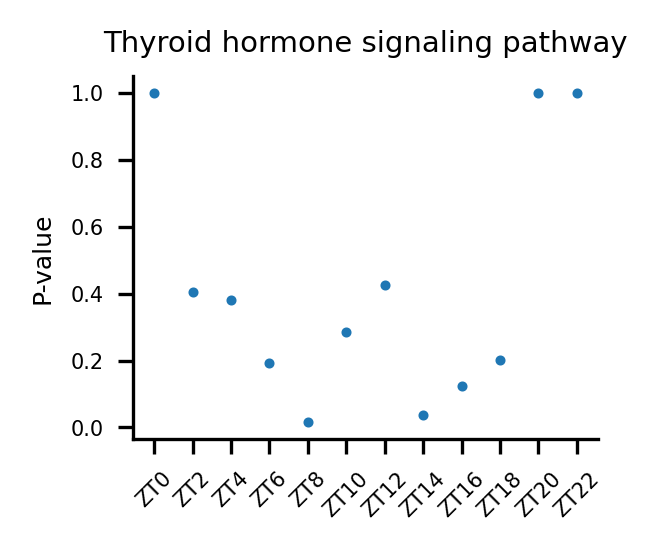

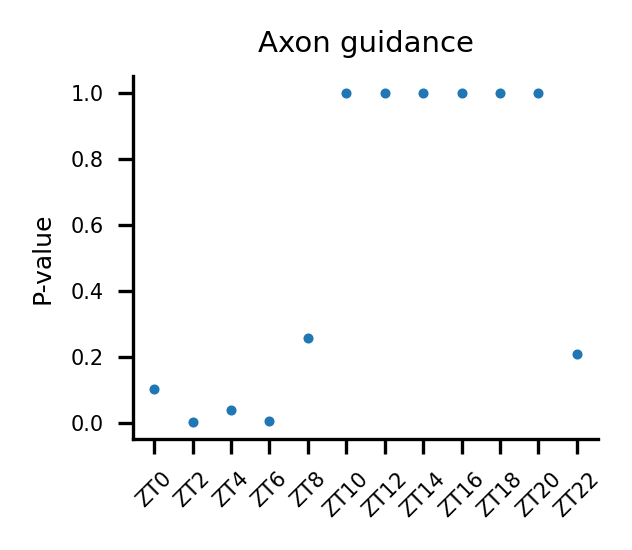

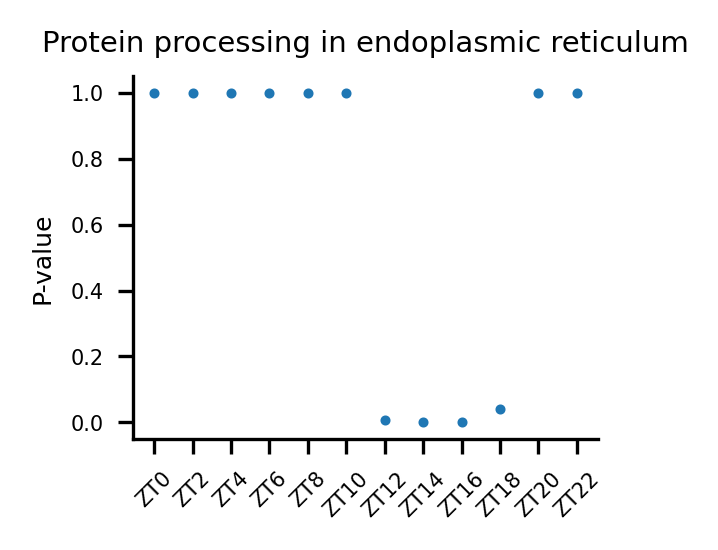

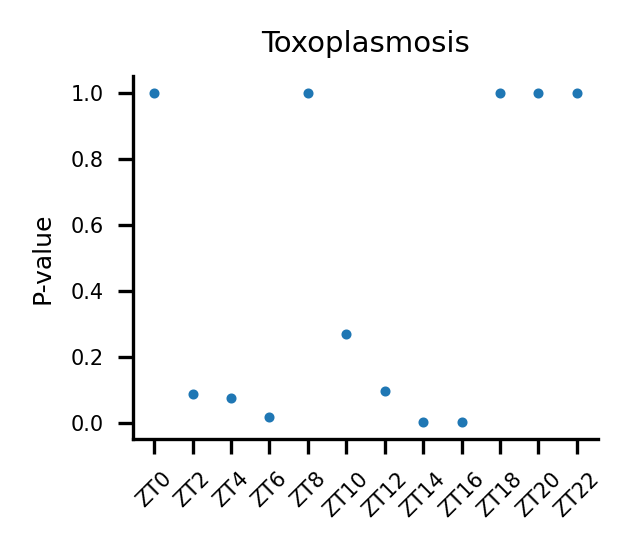

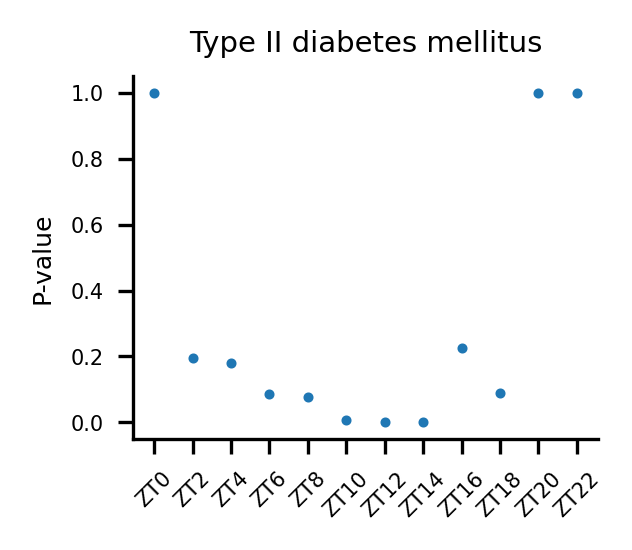

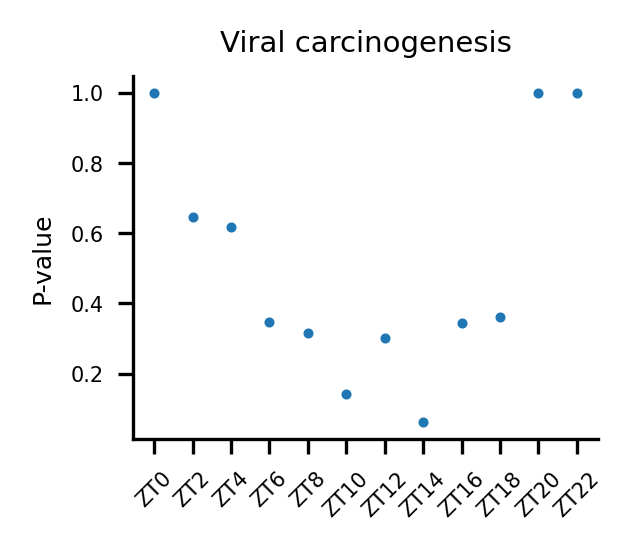

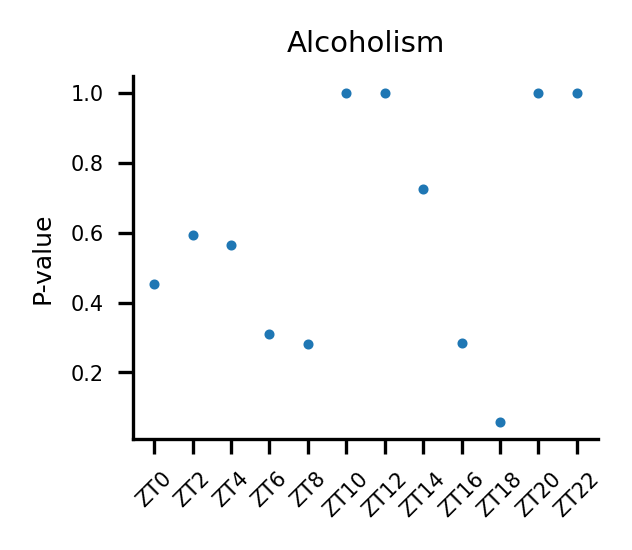

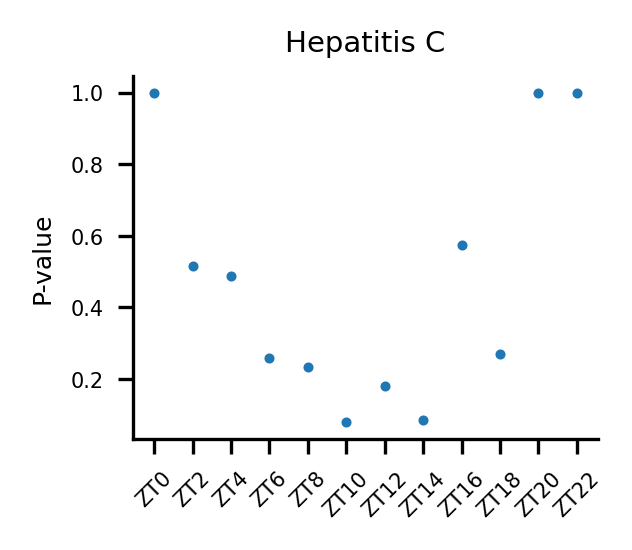

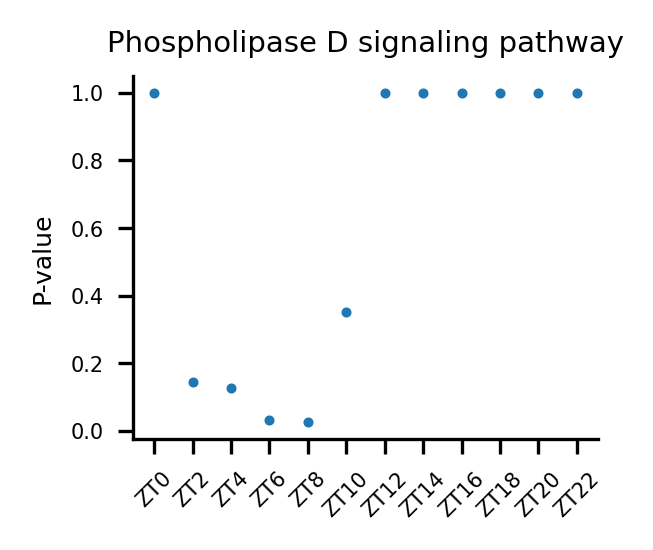

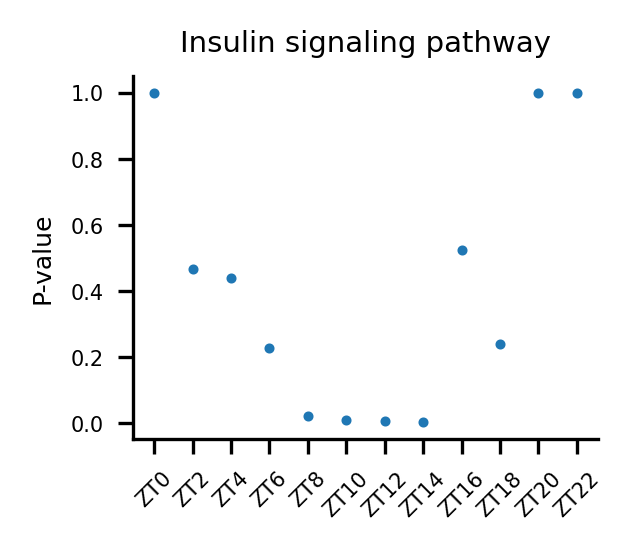

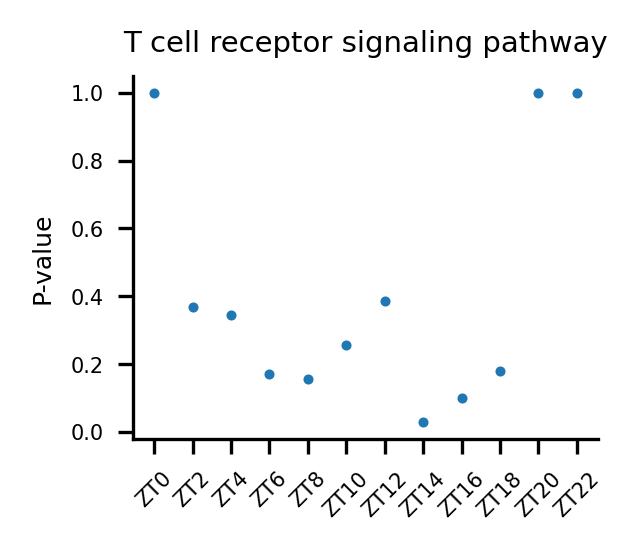

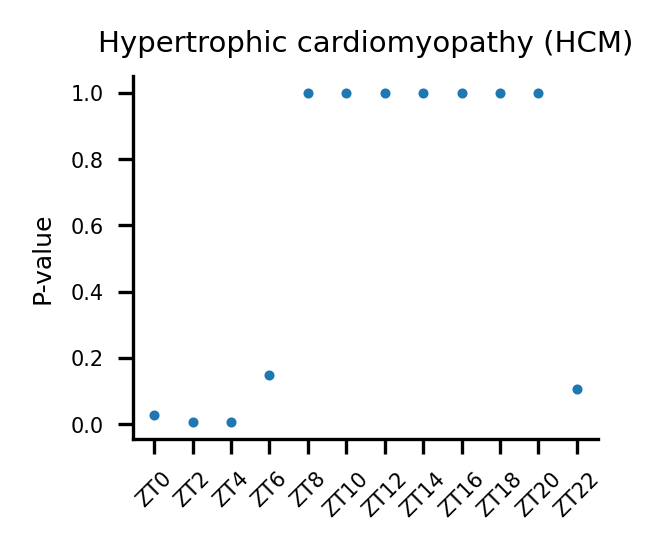

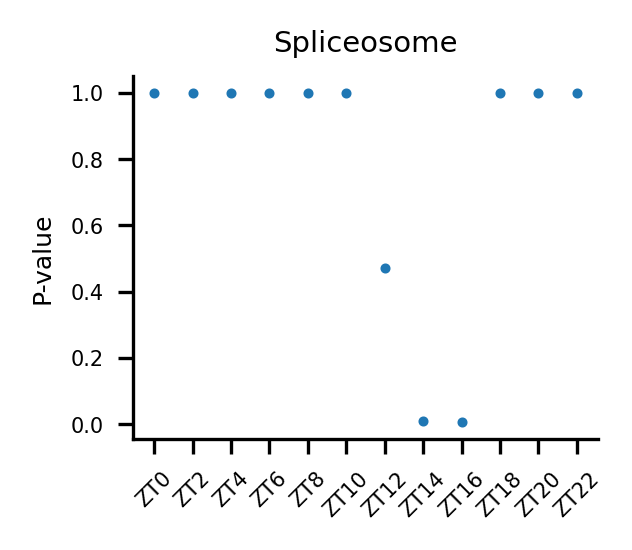

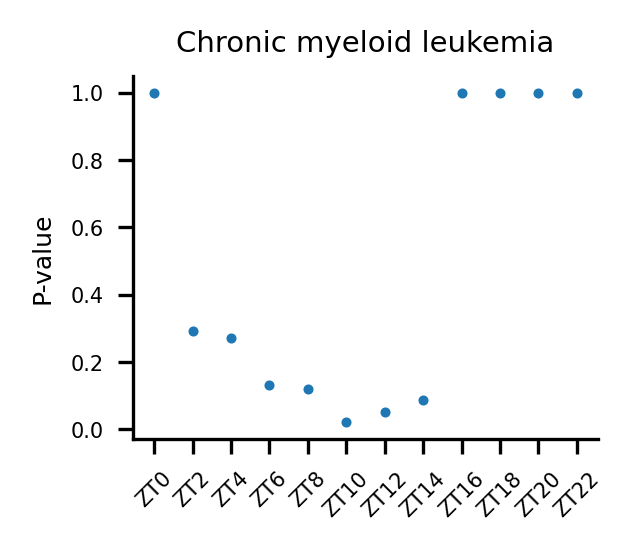

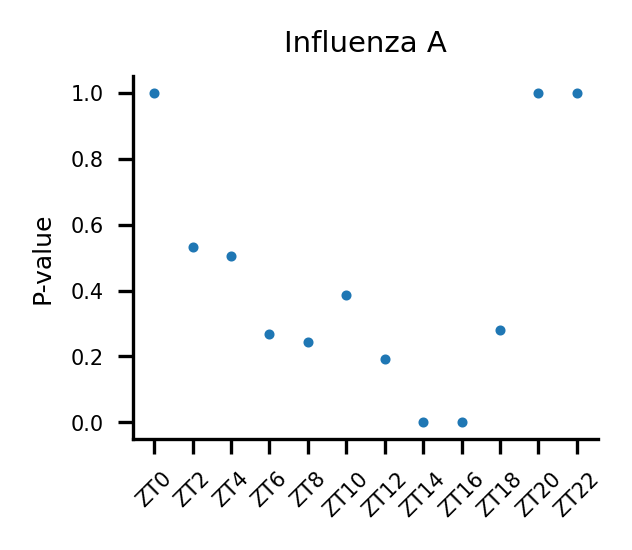

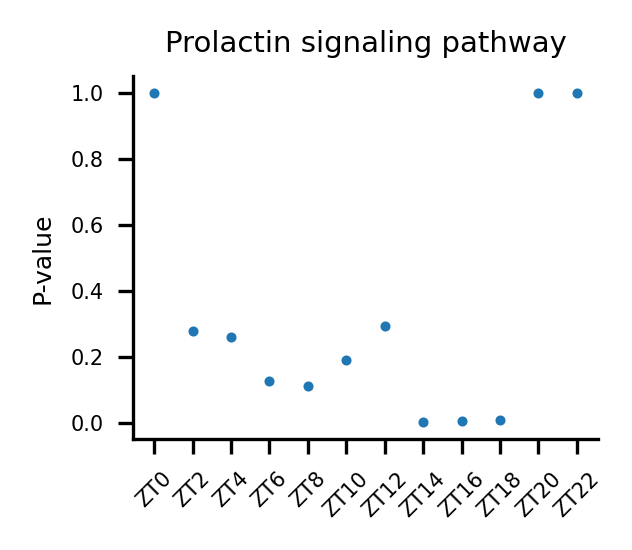

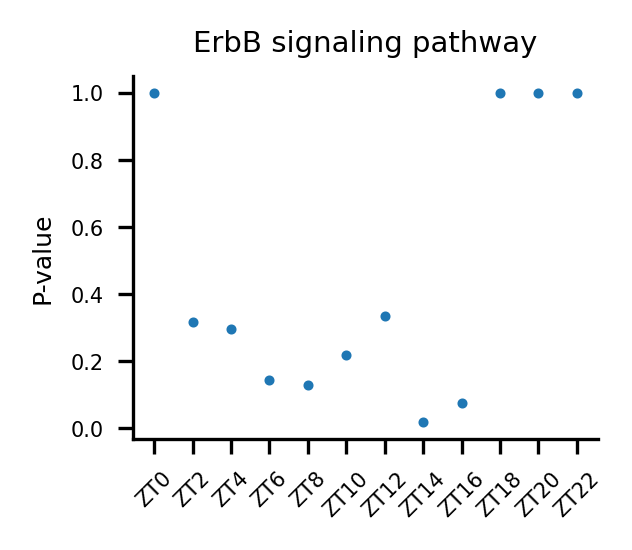

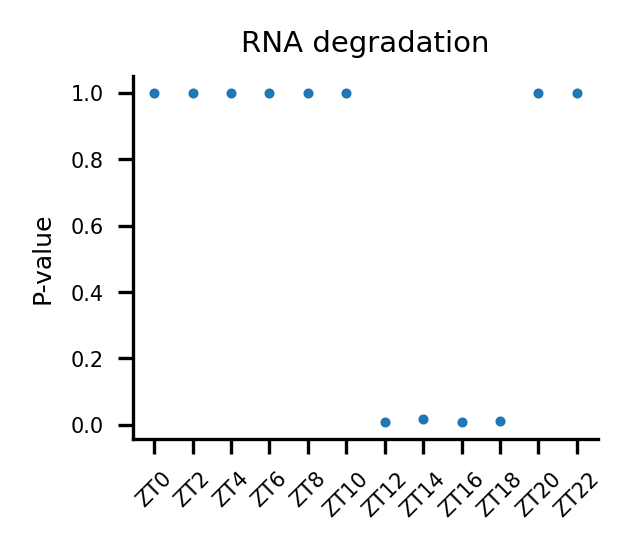

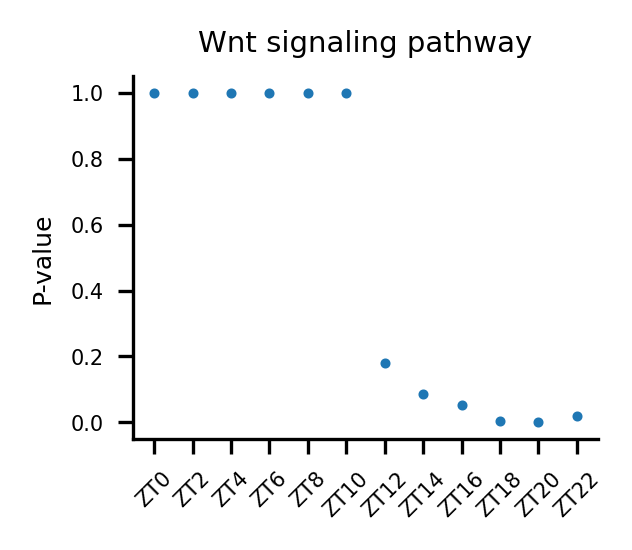

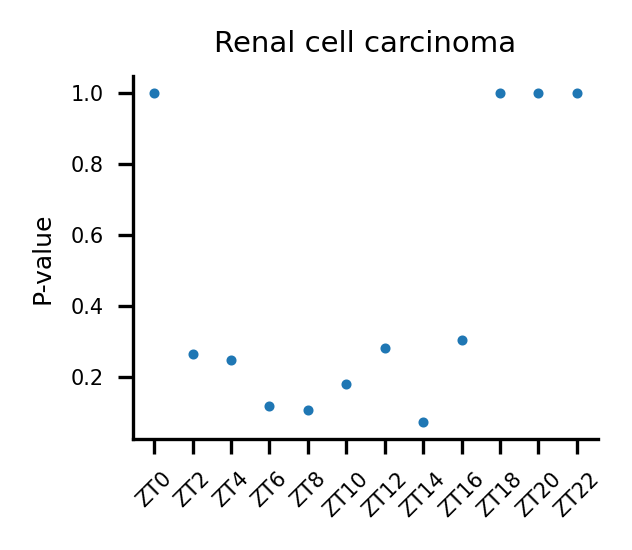

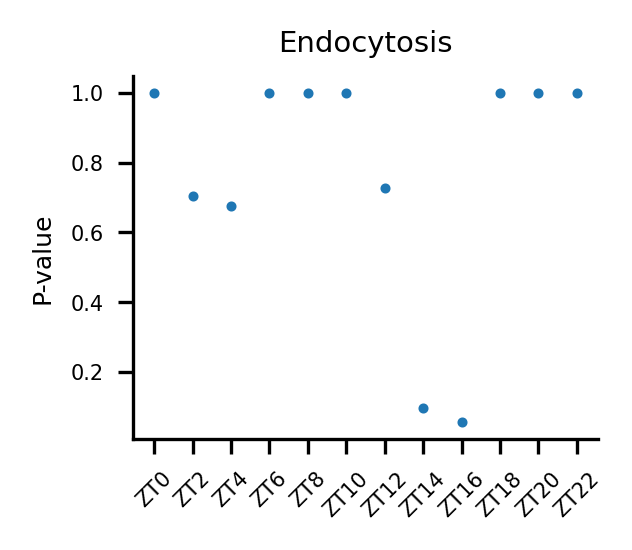

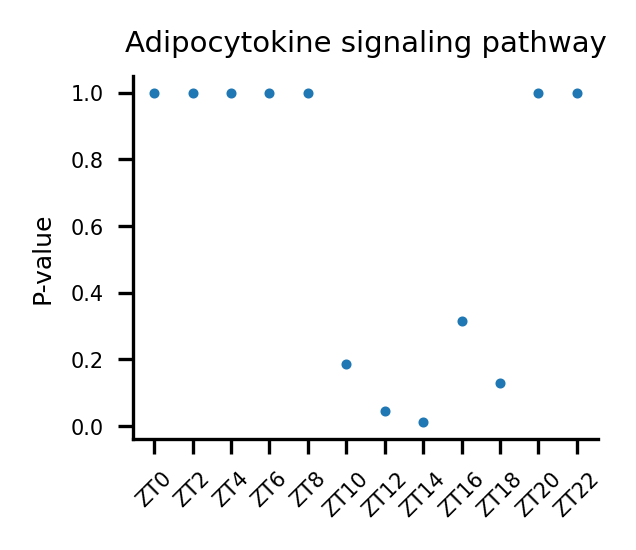

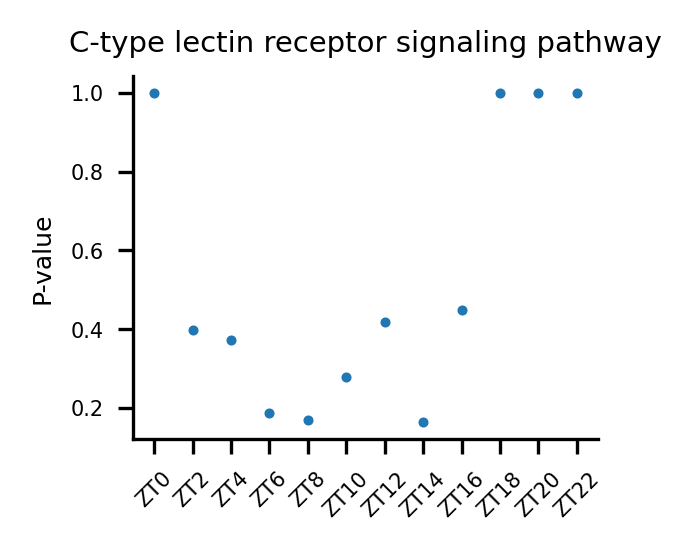

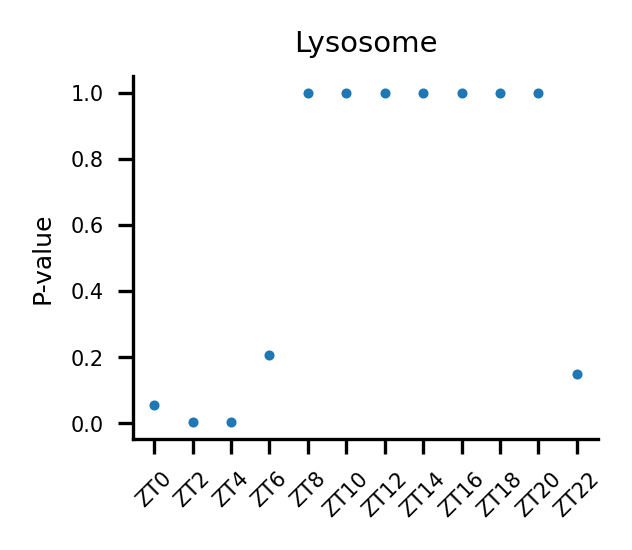

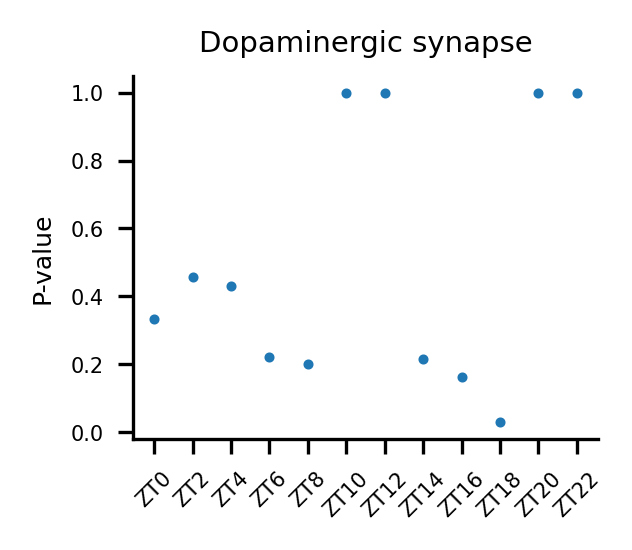

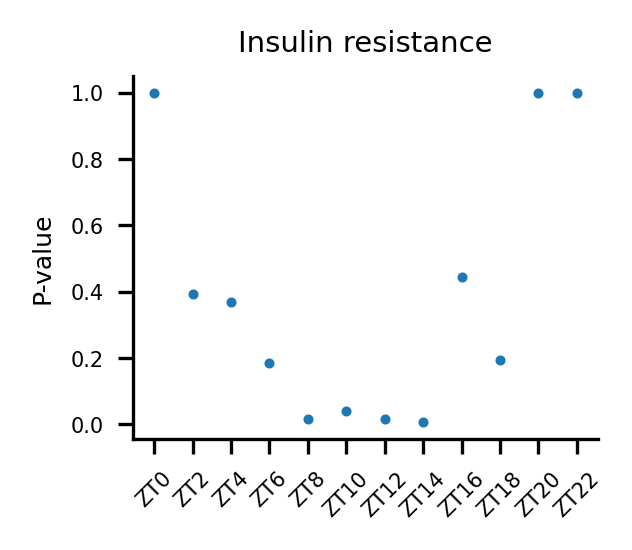

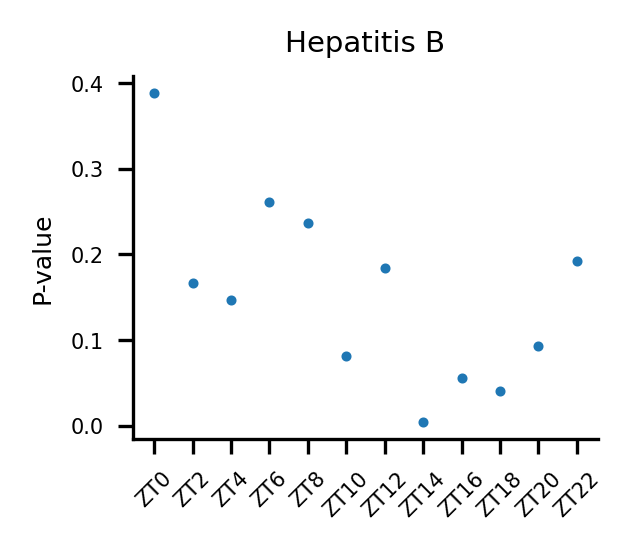

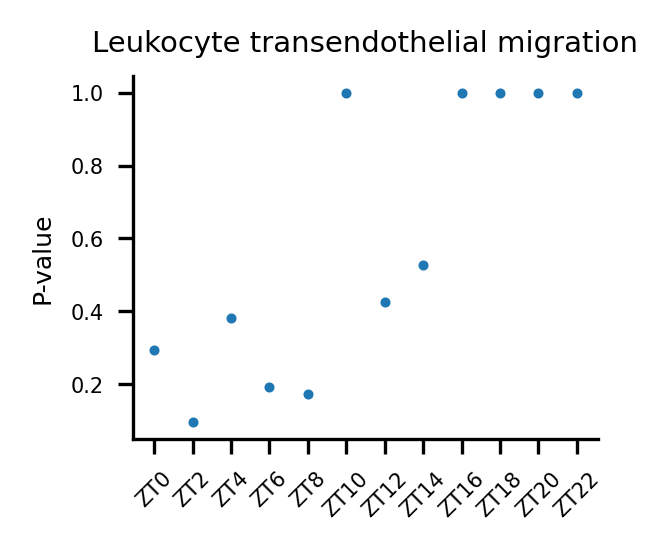

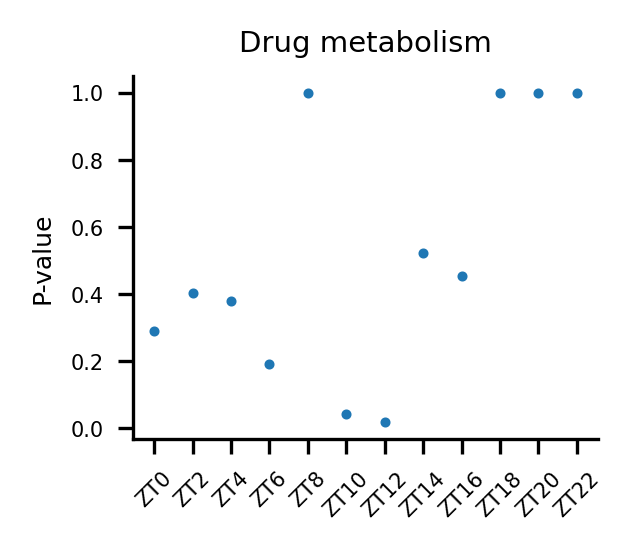

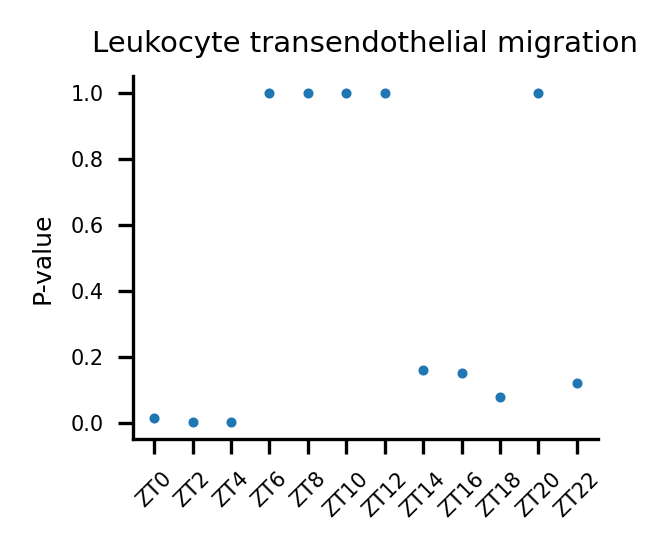

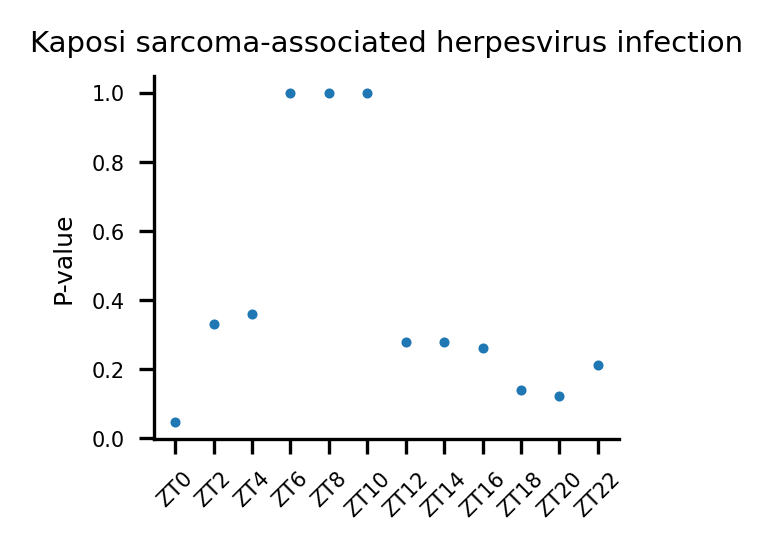

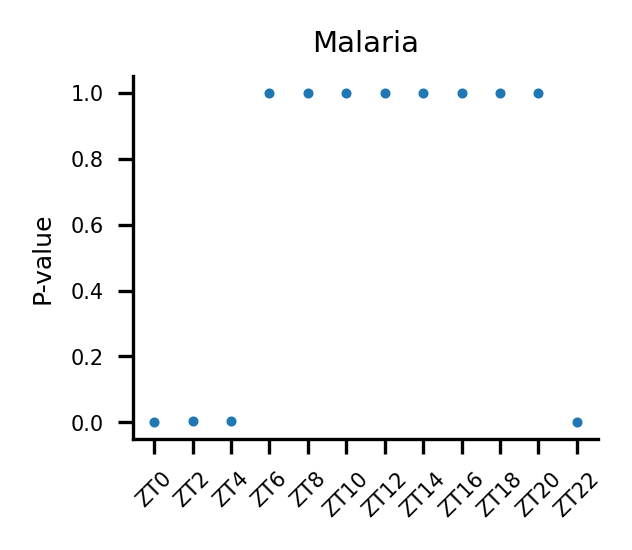

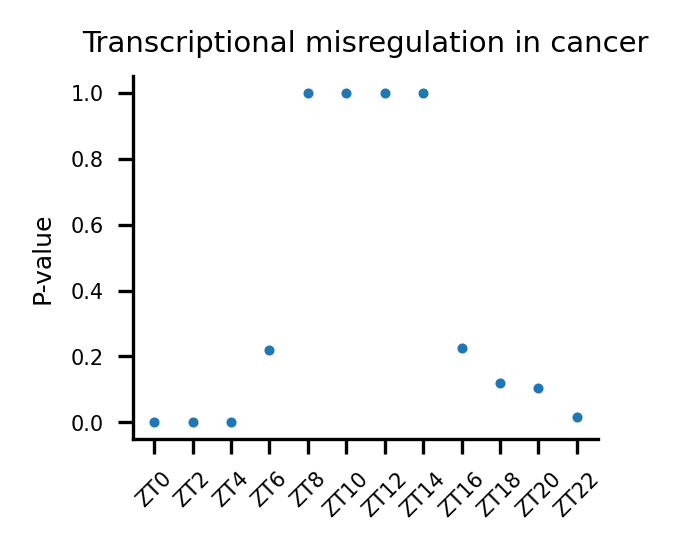

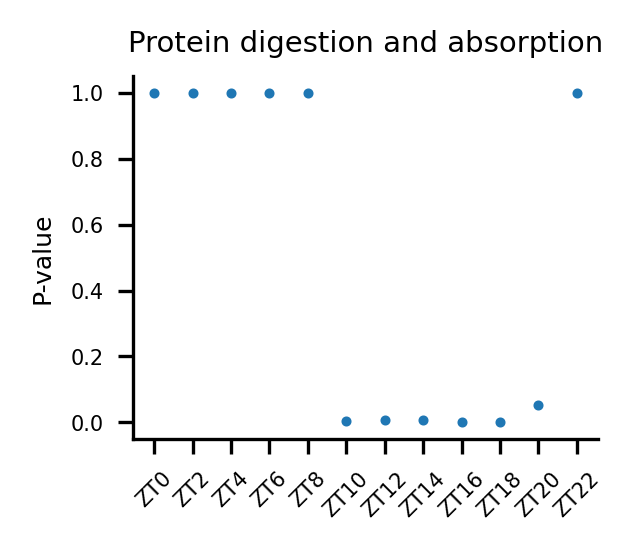

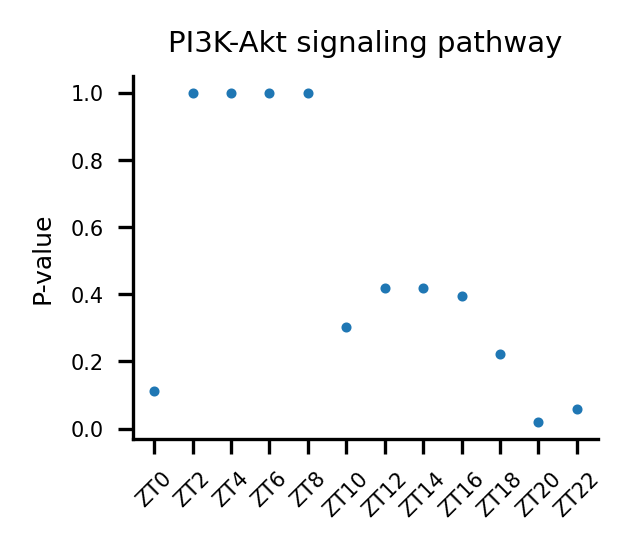

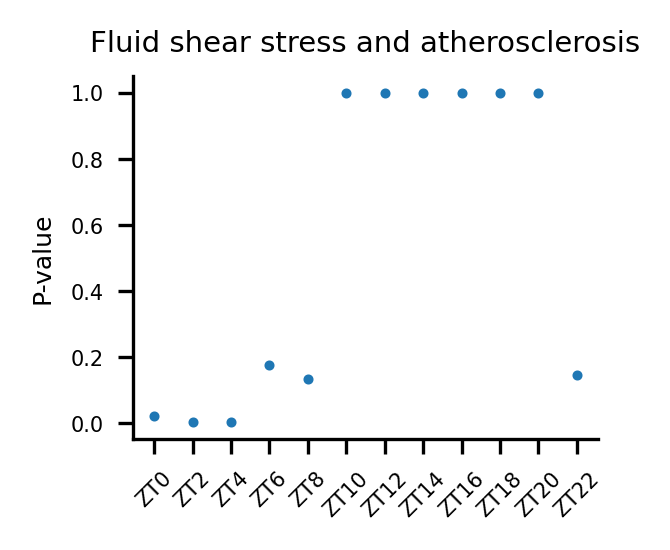

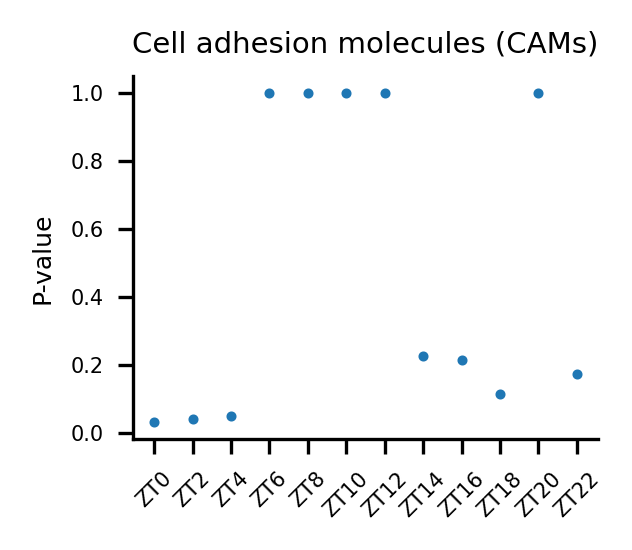

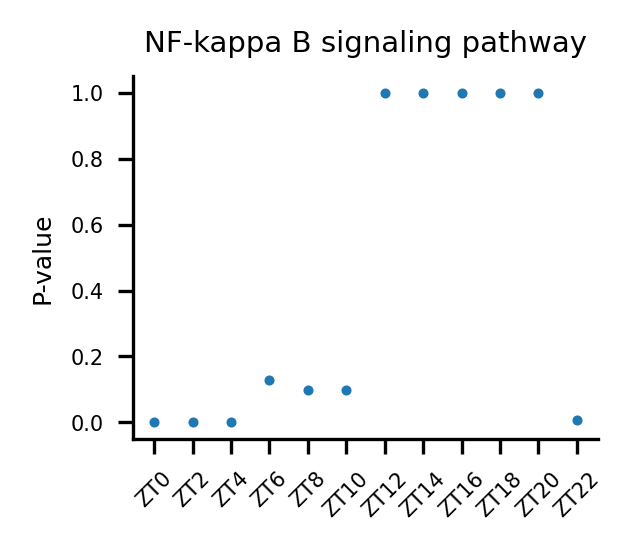

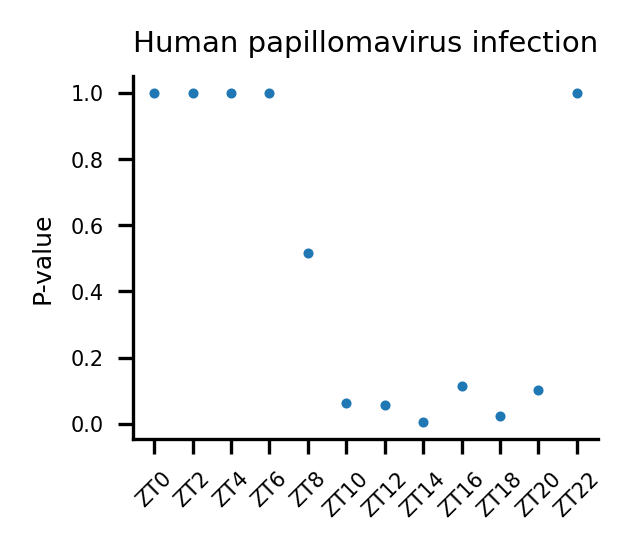

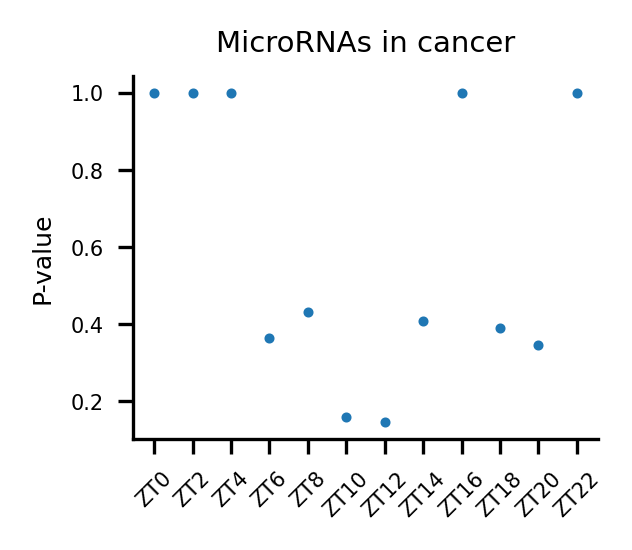

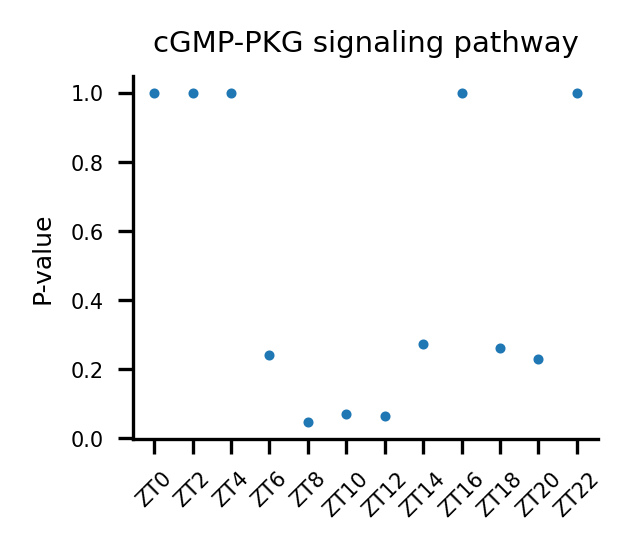

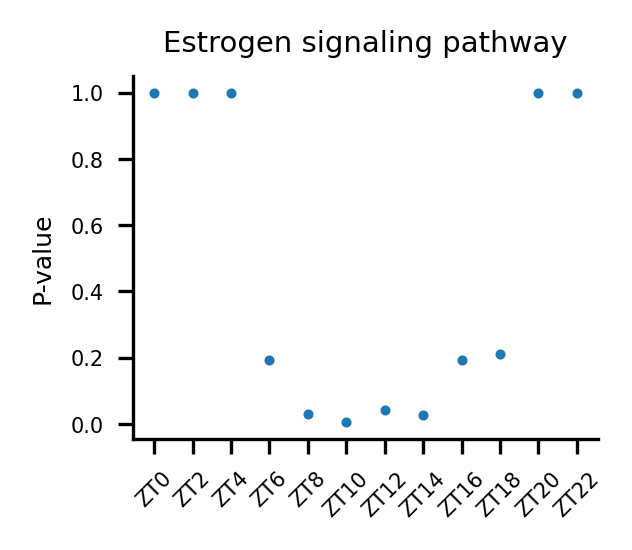

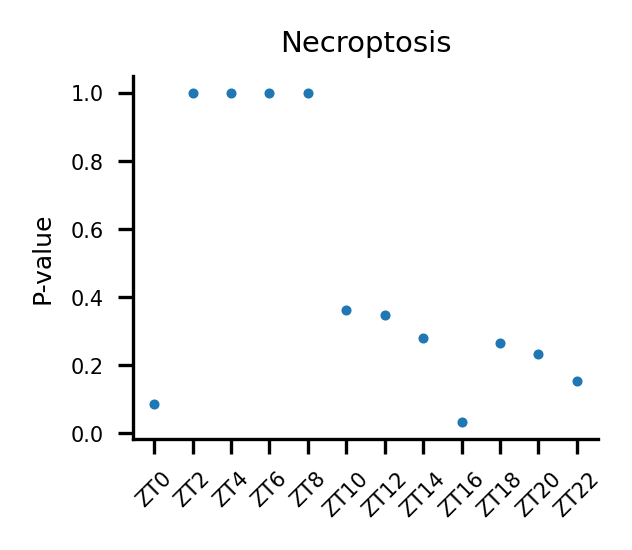

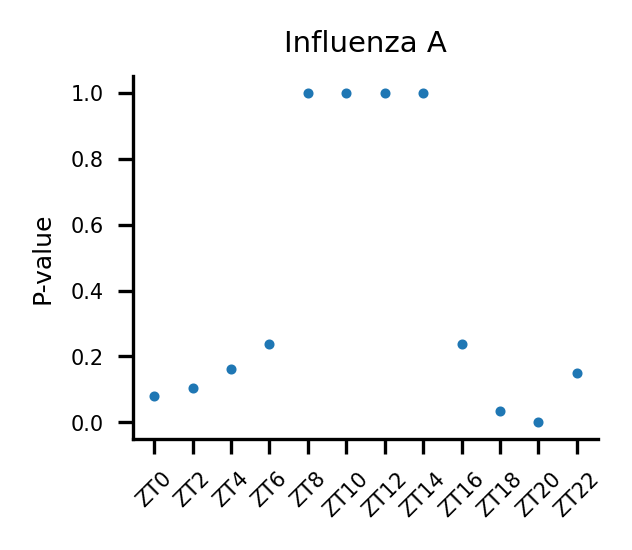

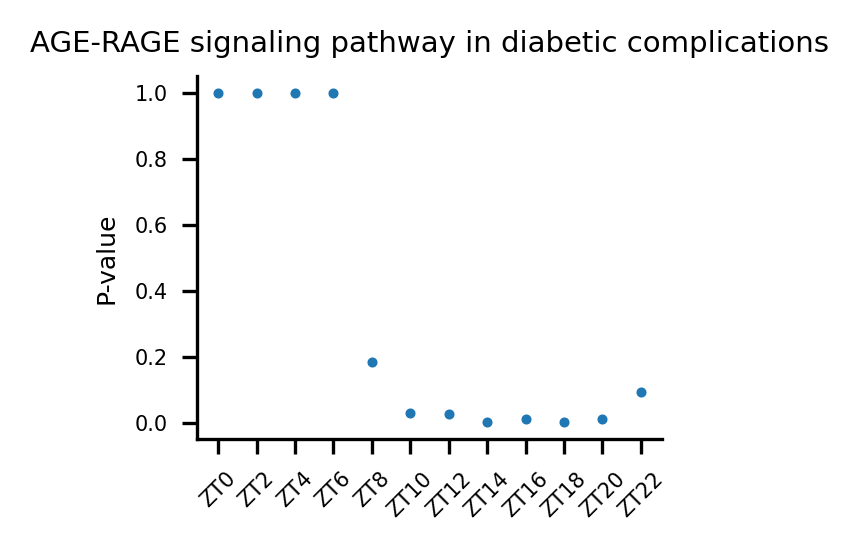

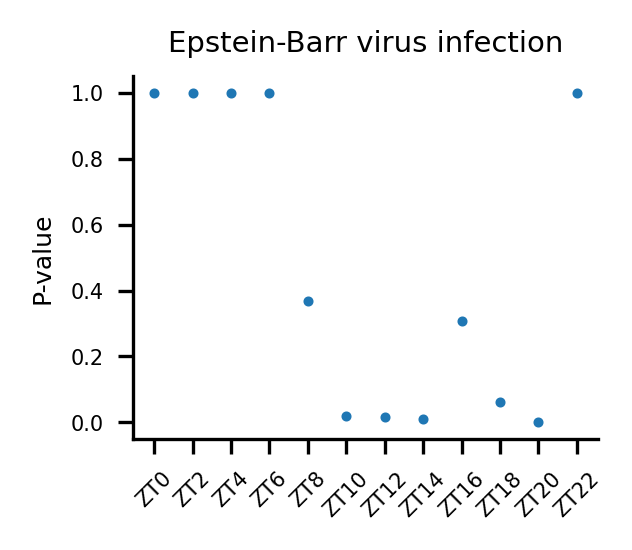

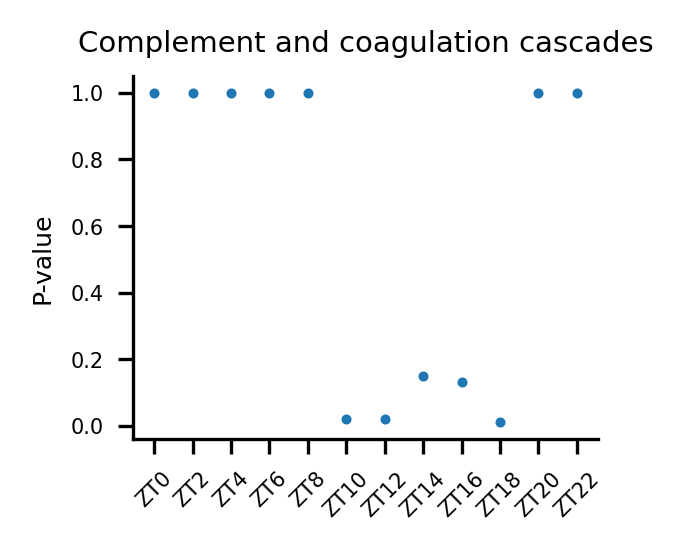

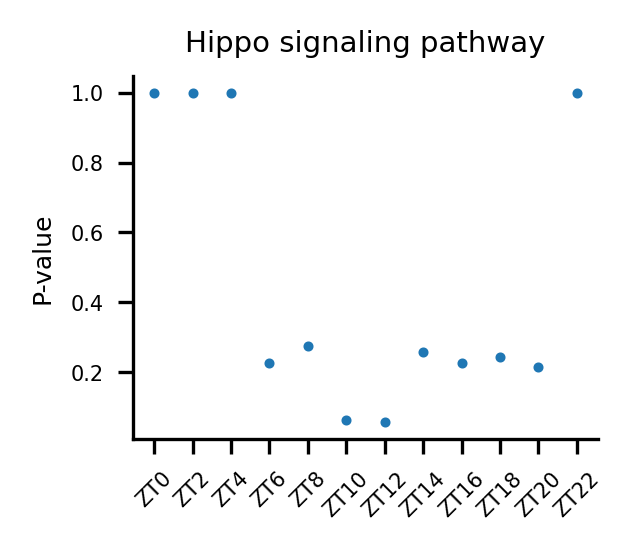

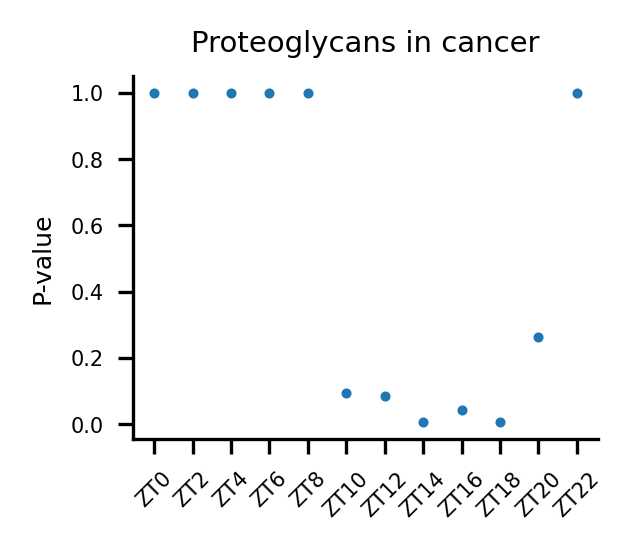

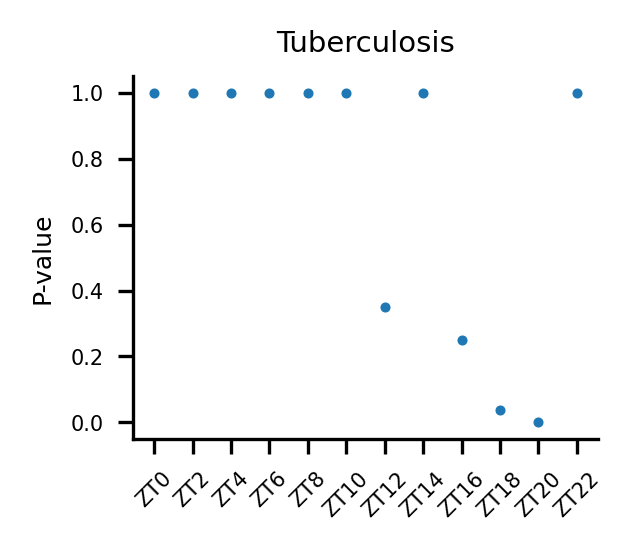

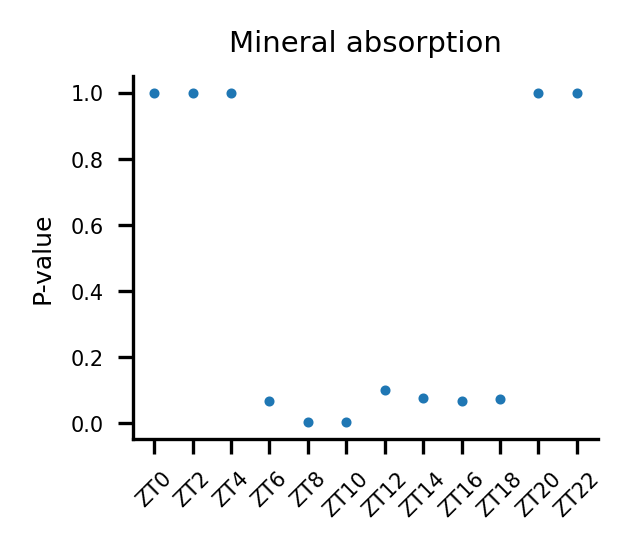

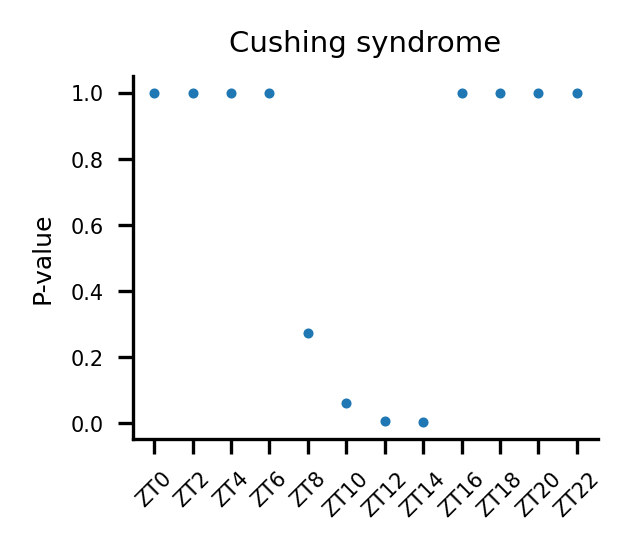

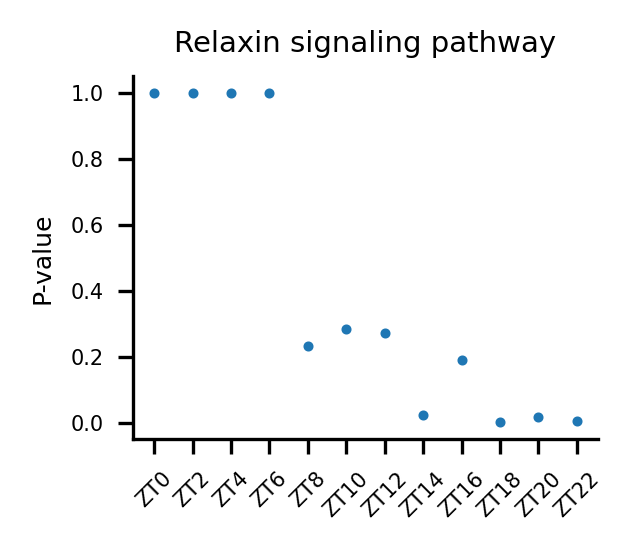

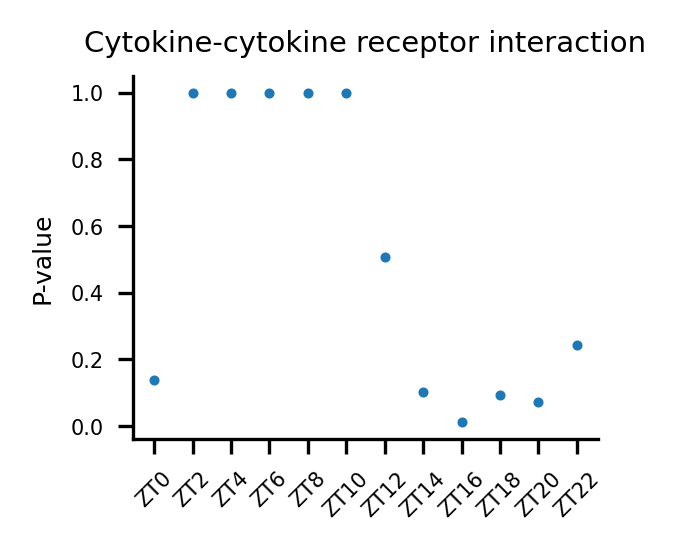

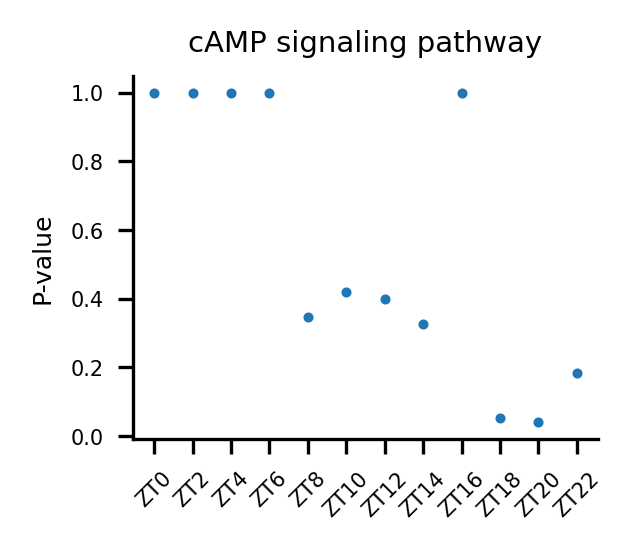

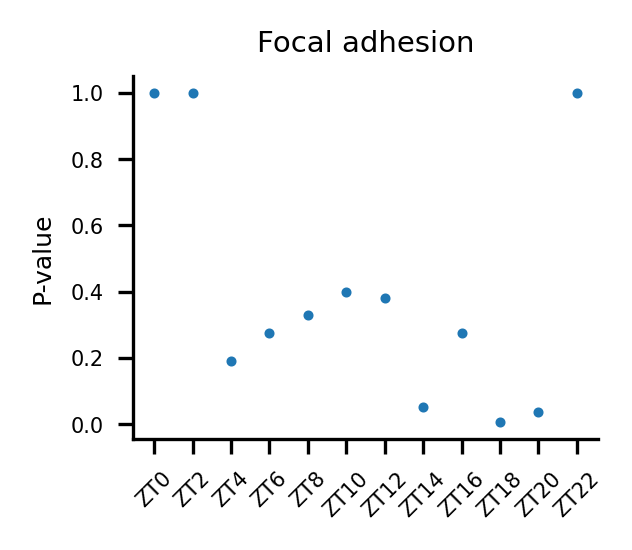

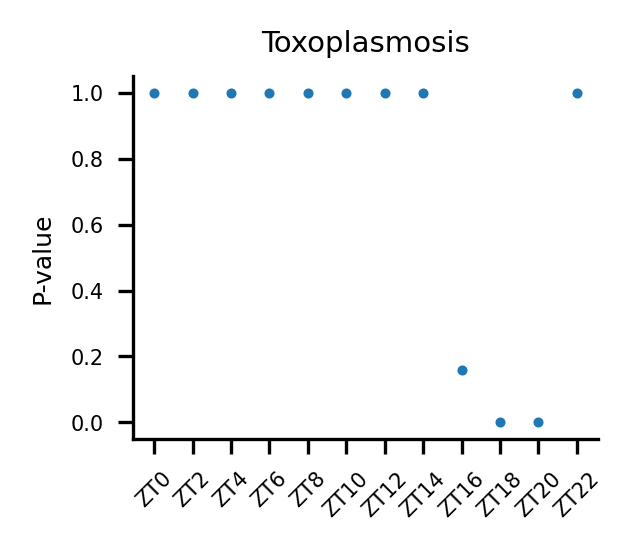

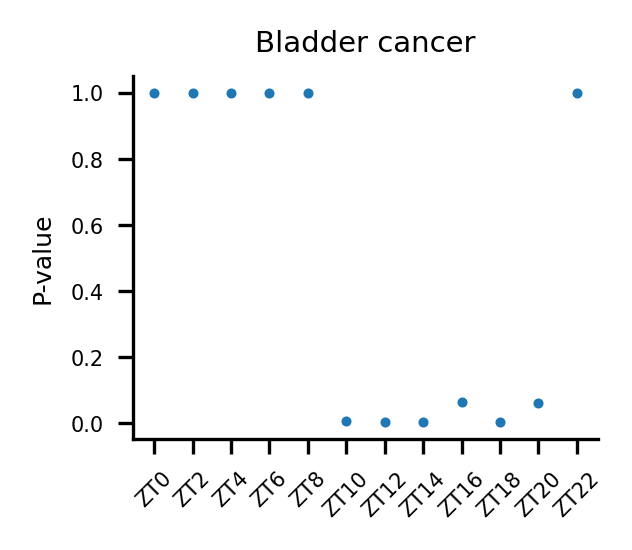

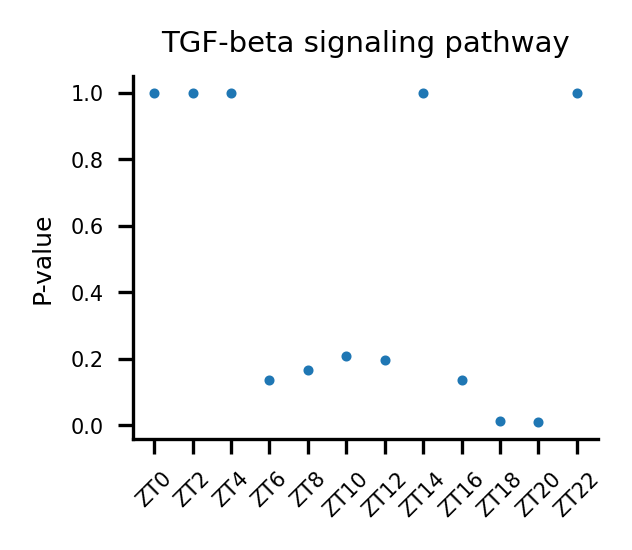

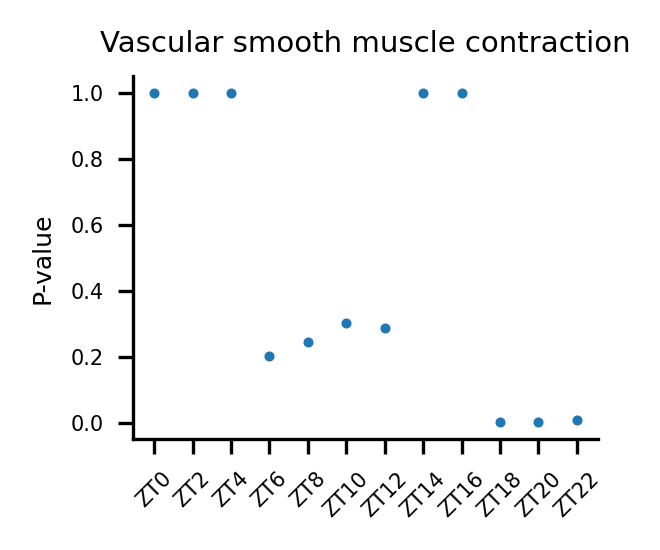

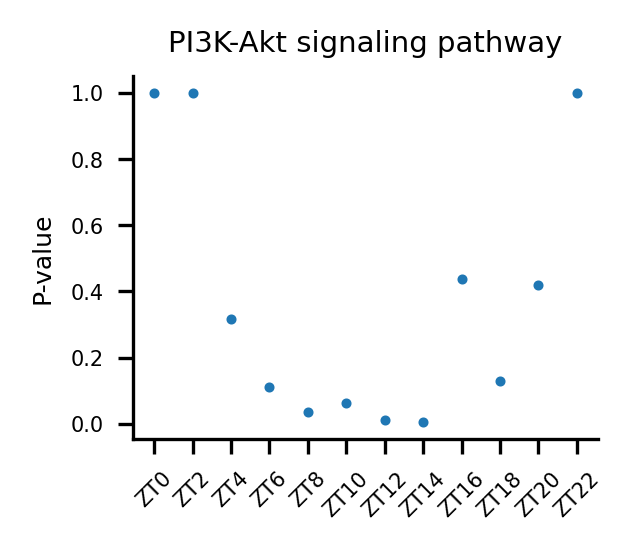

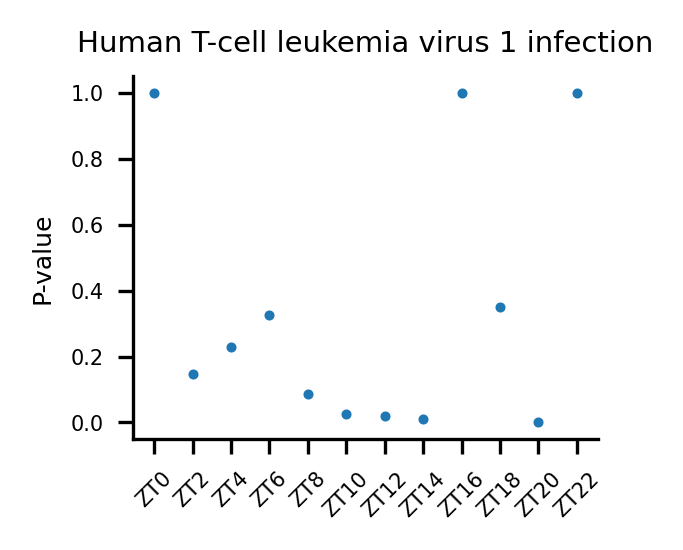

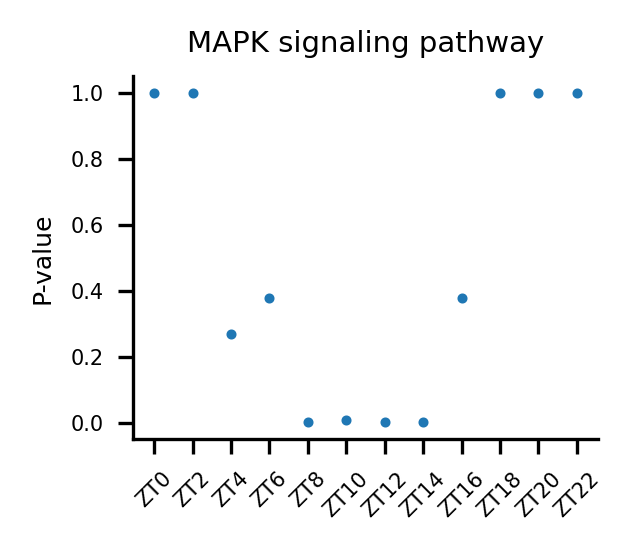

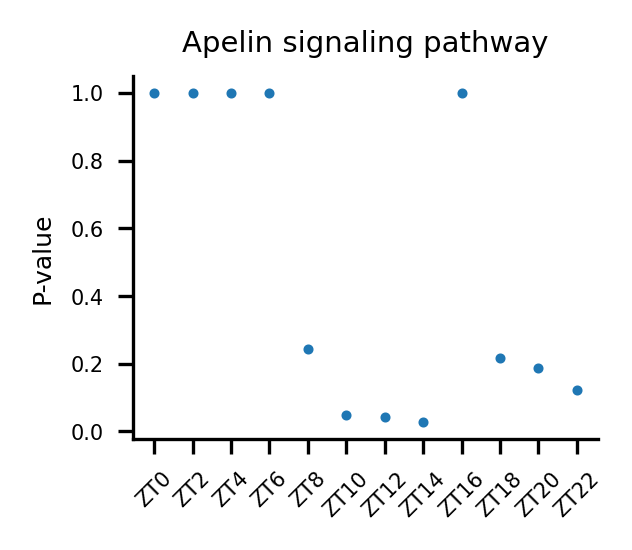

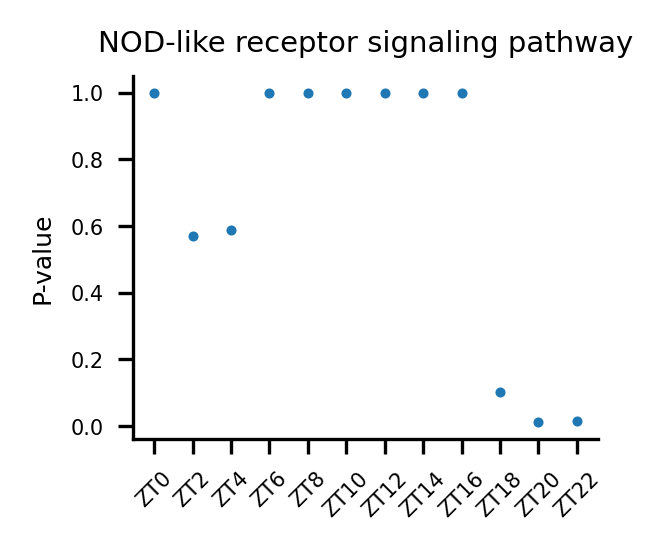

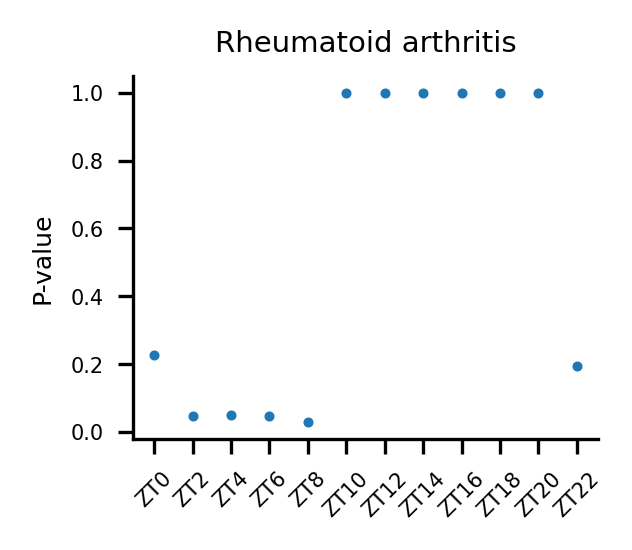

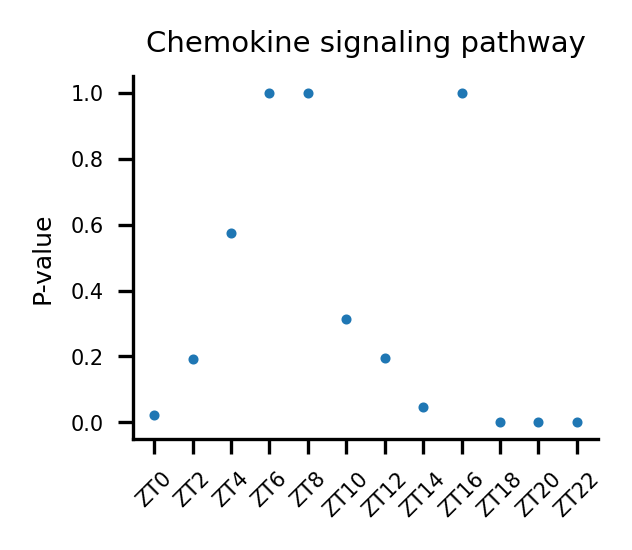

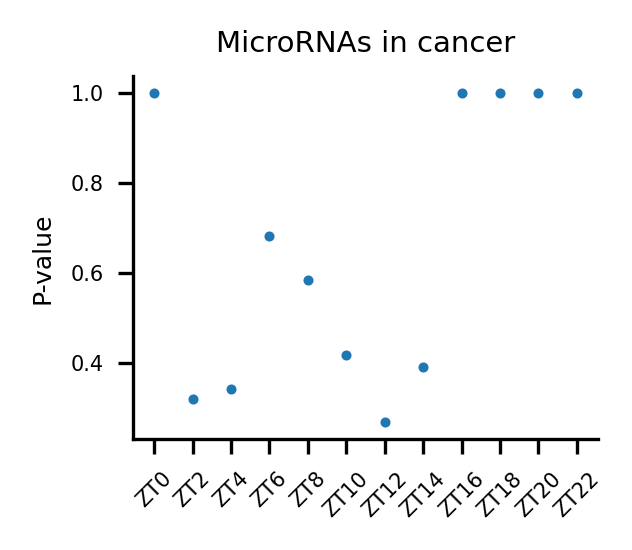

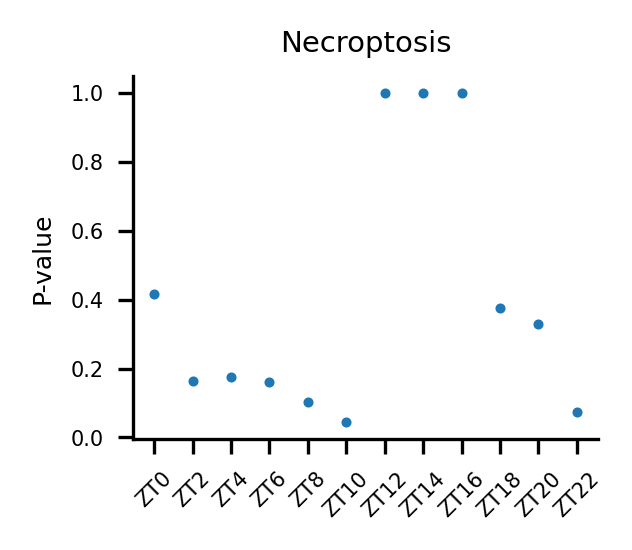

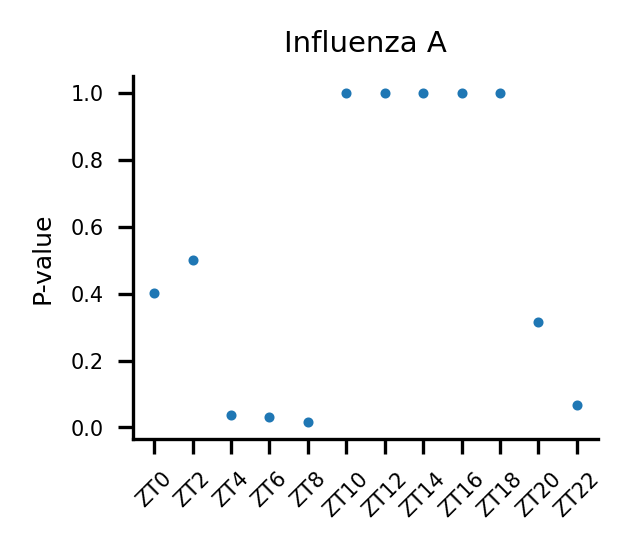

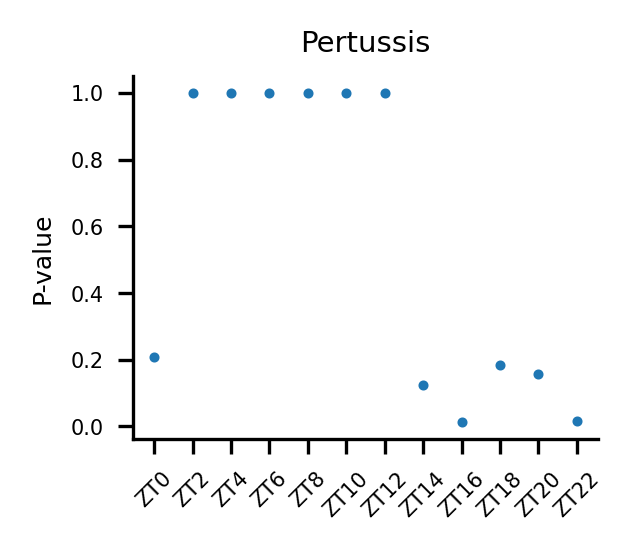

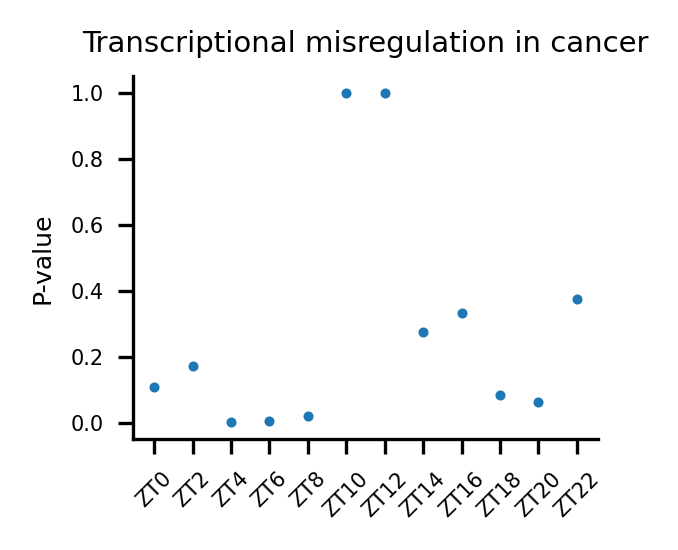

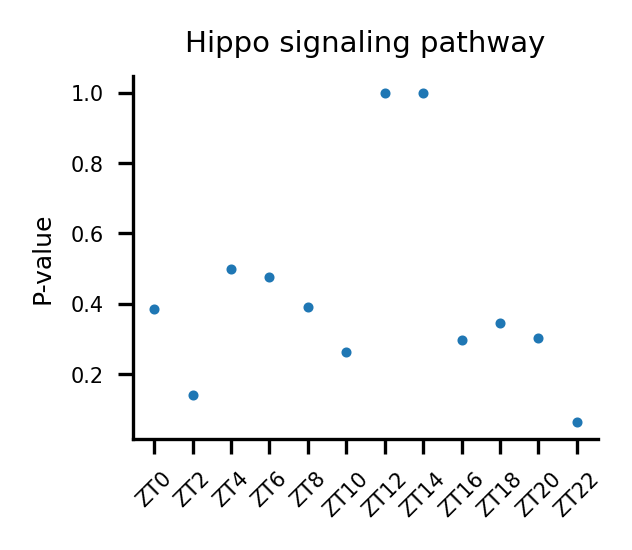

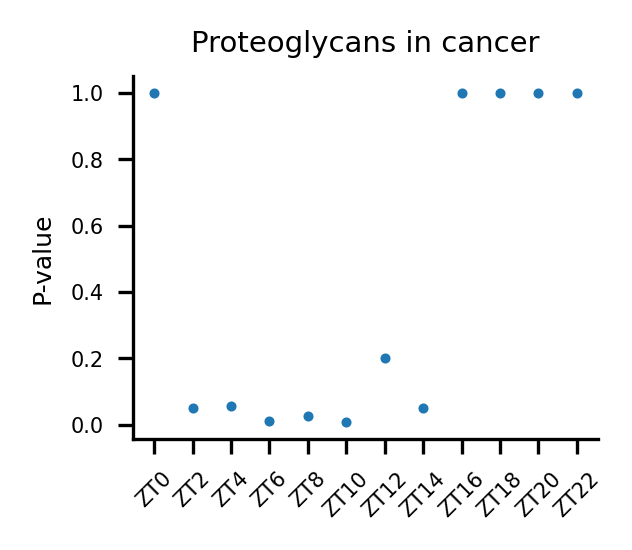

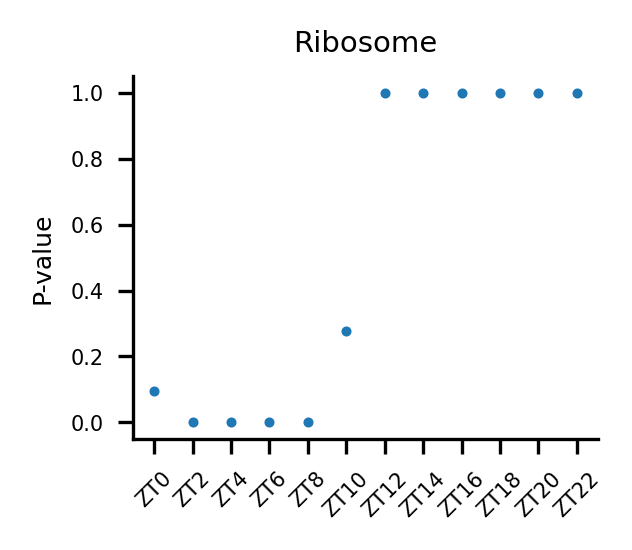

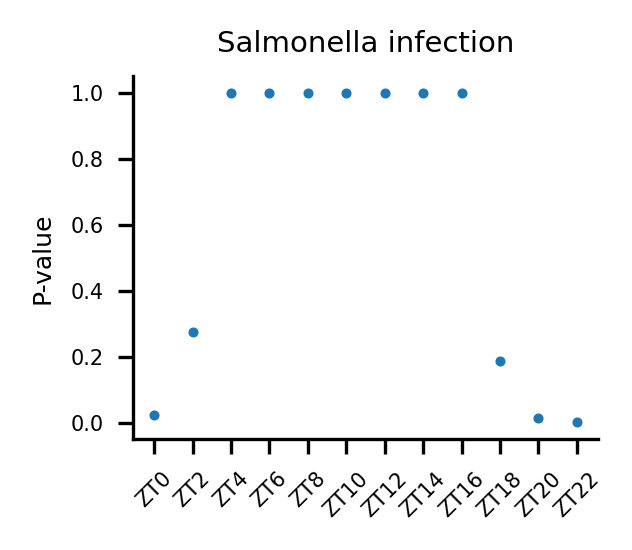

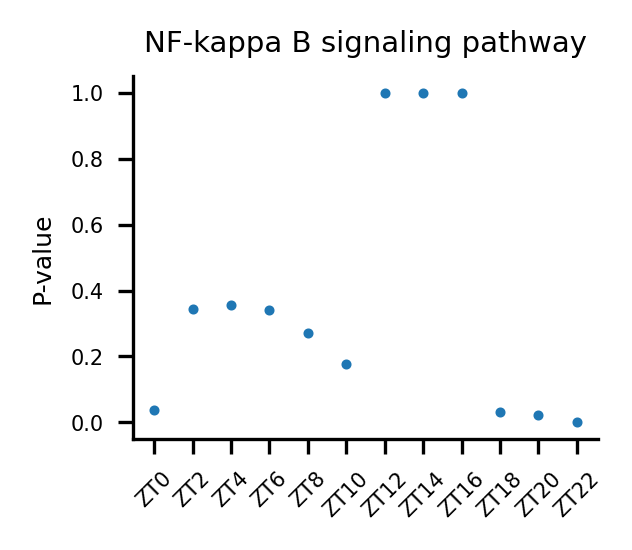

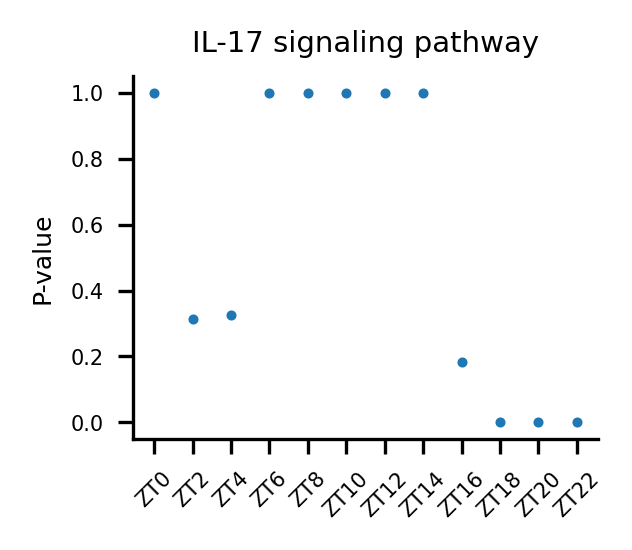

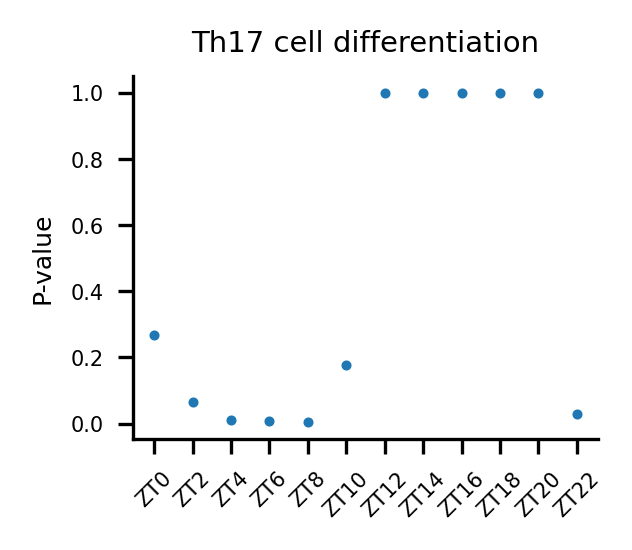

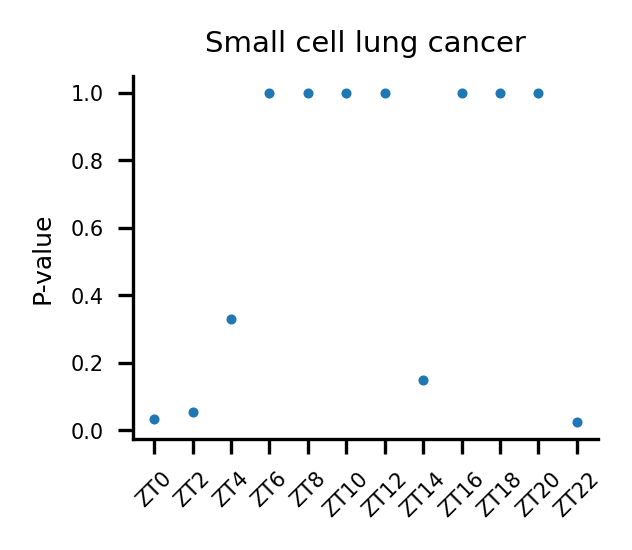

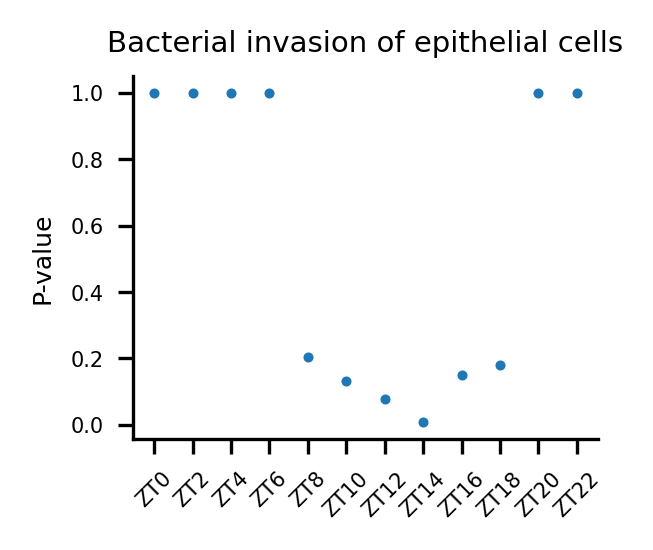

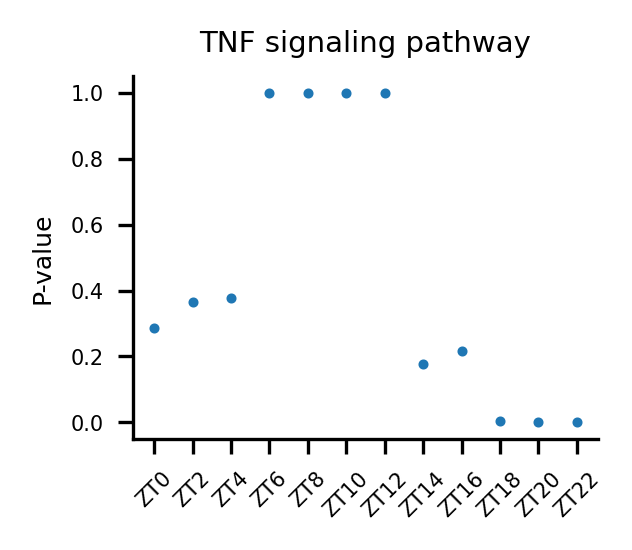

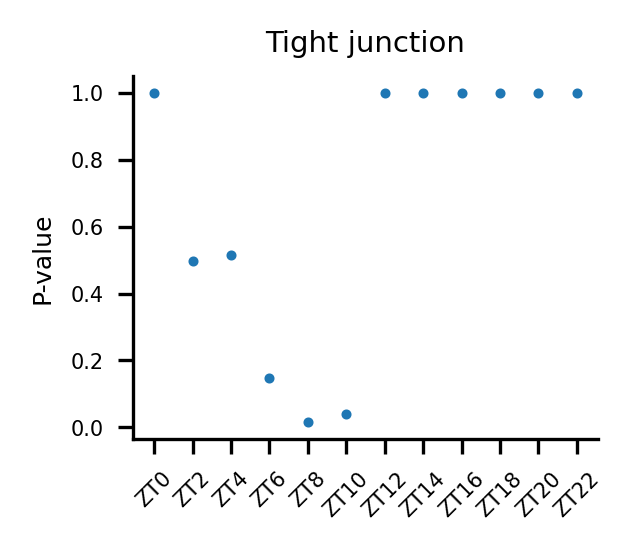

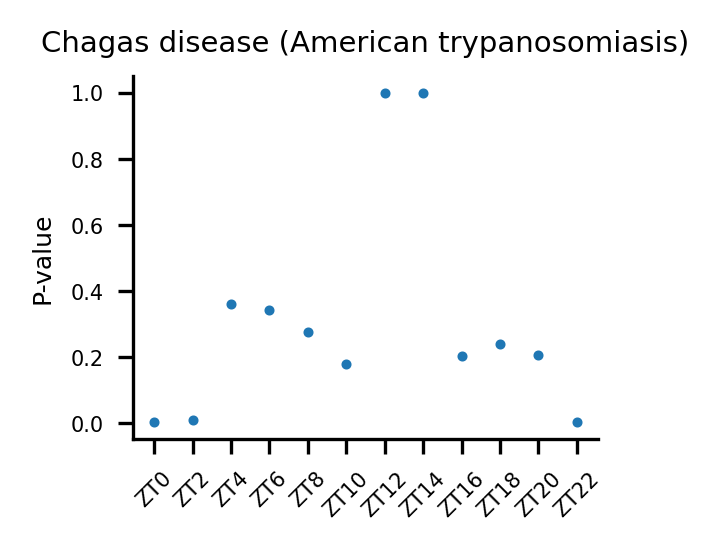

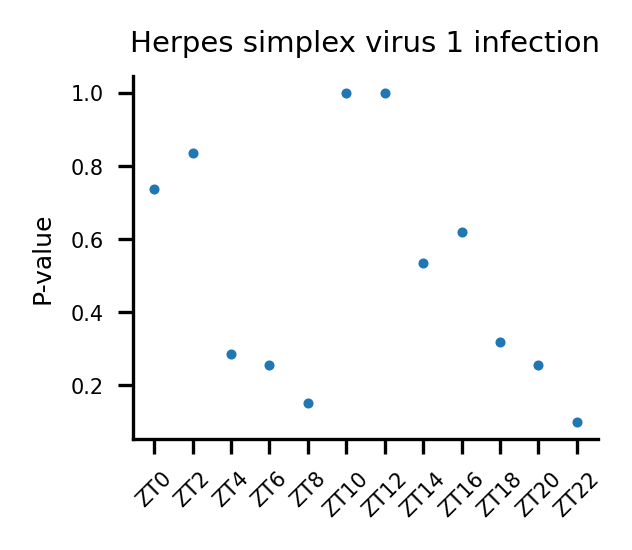

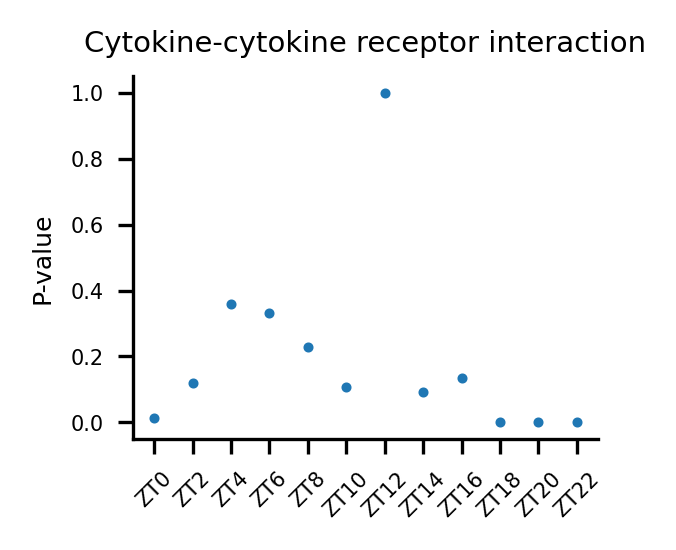

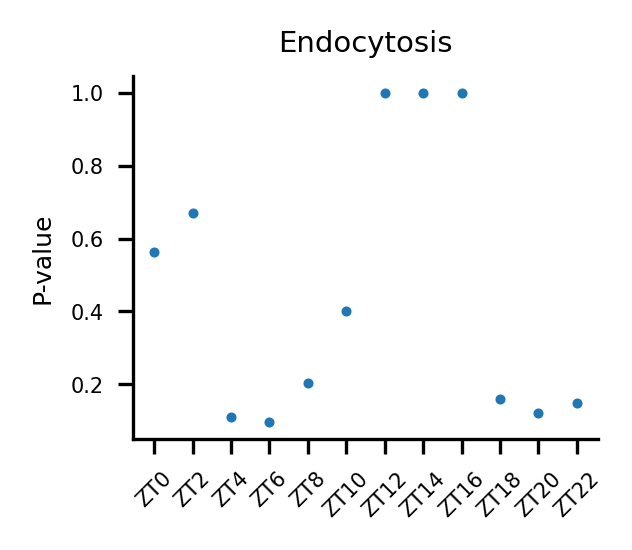

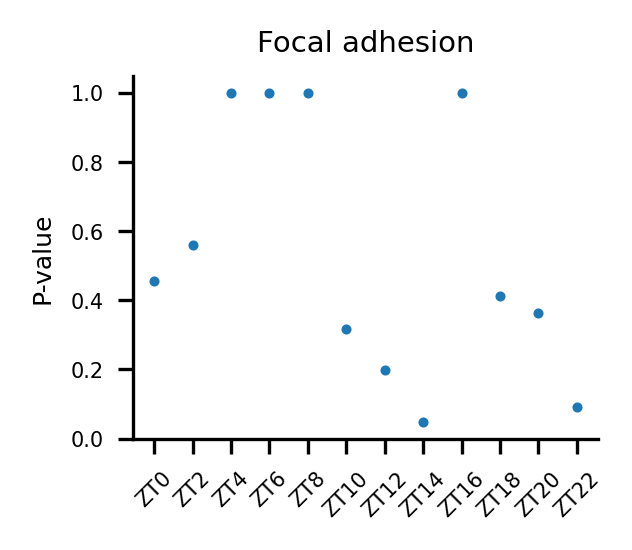

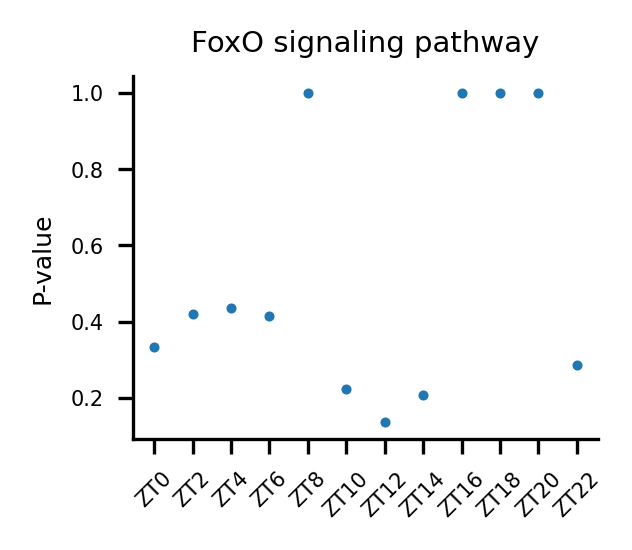

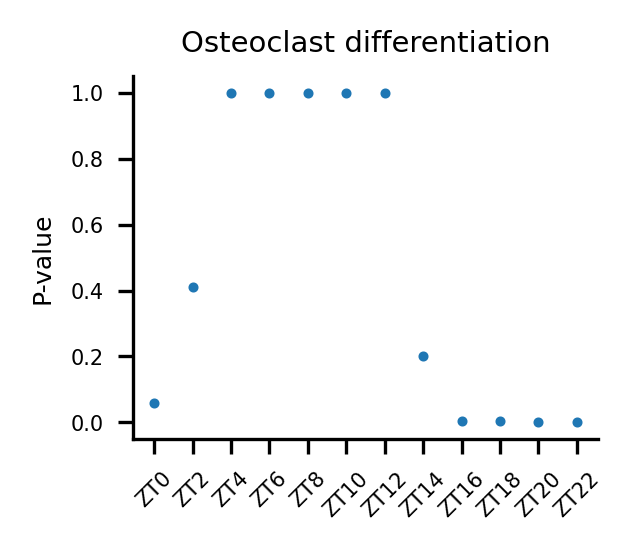

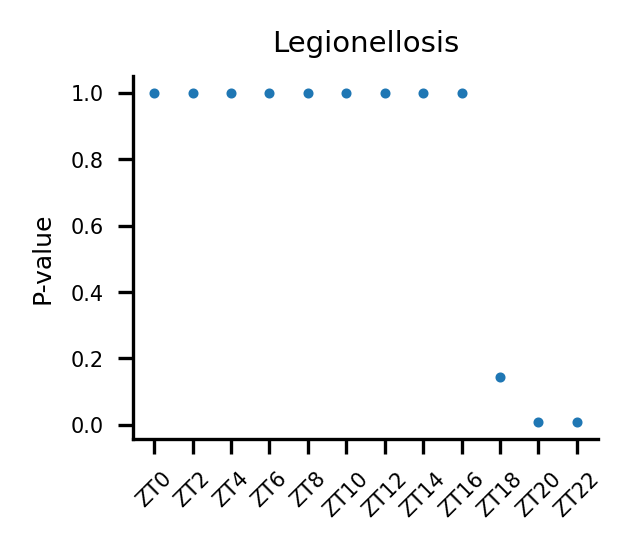

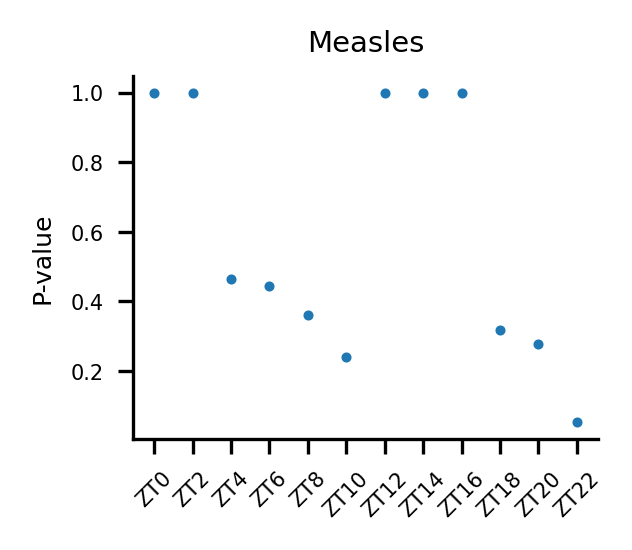

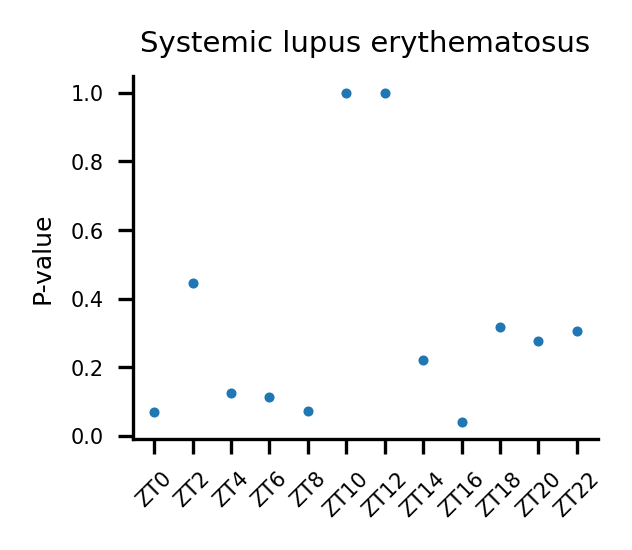

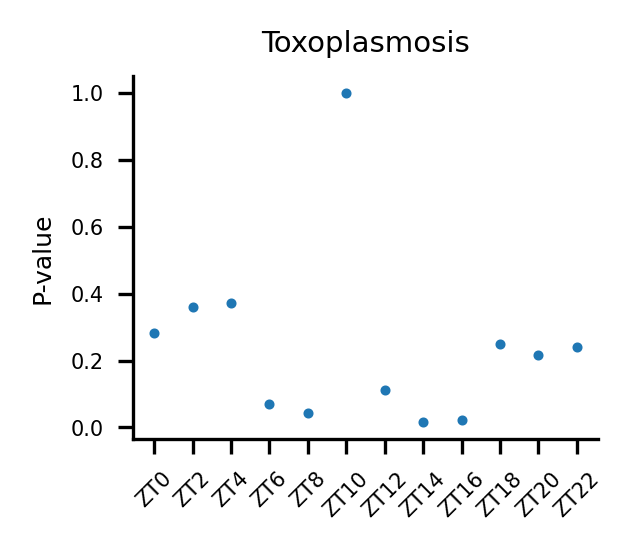

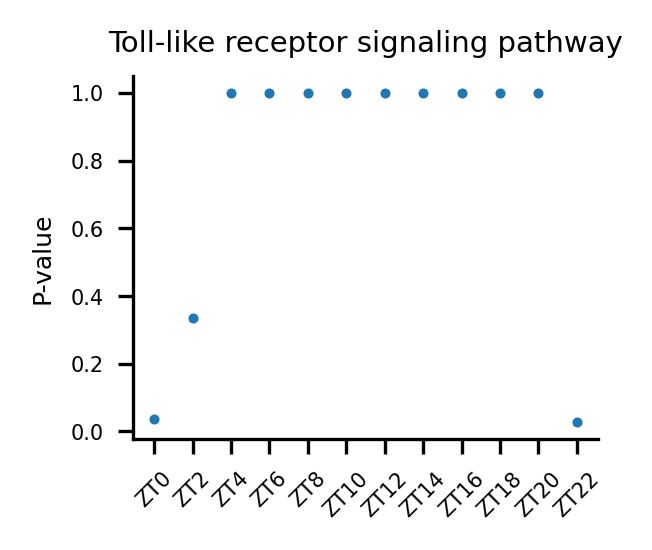

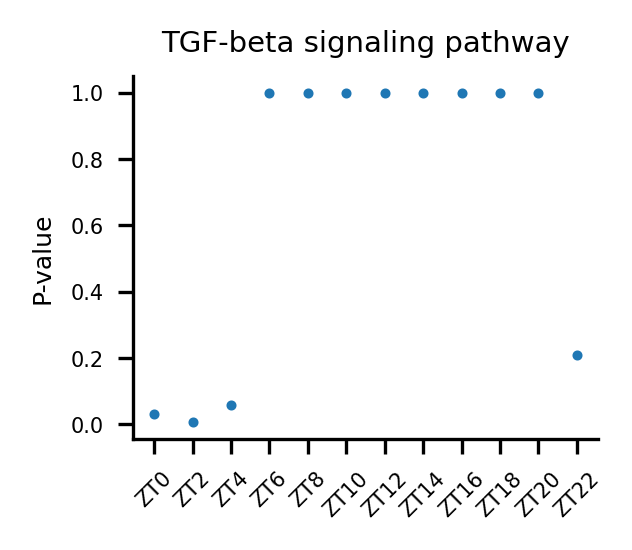

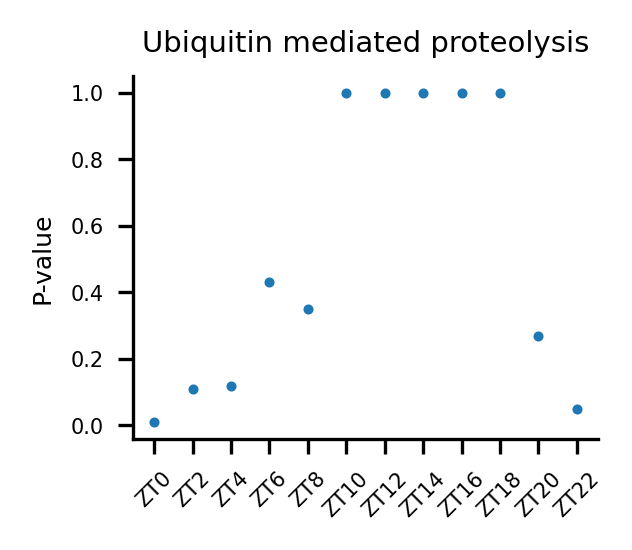

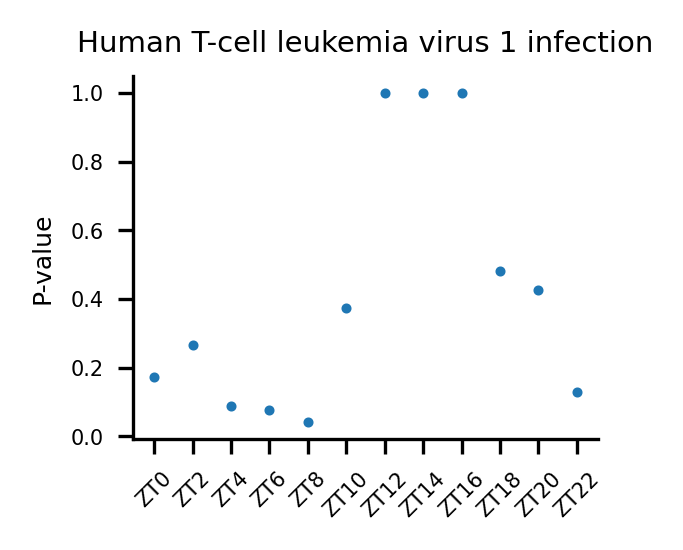

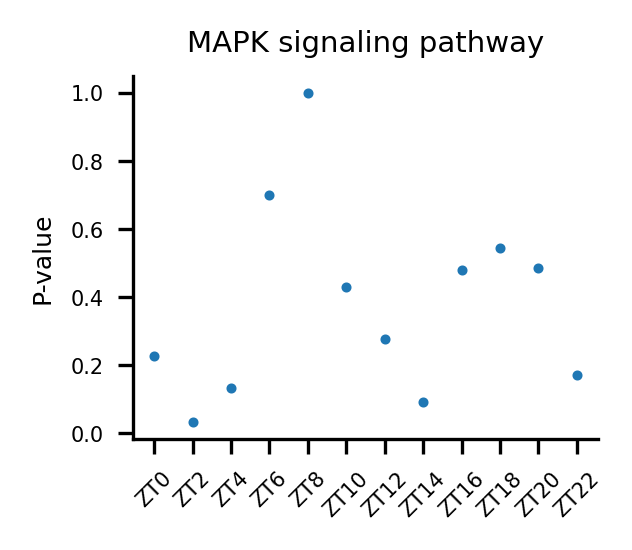

In [90]:
# --- GET PATHWAYS WITH NON-UNIFORM PEAK TIMES ---


import importlib
import helper_functions
importlib.reload(helper_functions)


# command to show all libraries.
# res.get_libraries()

# ** set params **
enrichment_gene_set = 'KEGG_2019_Mouse' # KEGG_2016 GO_Biological_Process_2018
ontology = enrichment_gene_set
num_waveform_samples = 500
num_grid_points = 24
min_gene_set_size = 3
max_interval_hours = 14
for cluster in clusters:
    
    # genes_with_params = list(cluster_cycler_metric_dfs[cluster].index) # list(cluster_cycler_metric_dfs[cluster].index) # reg_genes_to_est
    # genes_with_params = reg_genes_to_est
    genes_with_params = list(cluster_metric_dfs[cluster][cluster_metric_dfs[cluster]['waveform_over_circadian_component_subtracted_log10_bf'] >= 1].index)
    subfolder_out = '%s/pathway_enrichment/%s/cluster_%s' % (folder_out,enrichment_gene_set,cluster)
    if not os.path.exists(subfolder_out):
        os.makedirs(subfolder_out)


    # ** load gene set dict **
    gene_set_dict_of_dicts = helper_functions.get_gene_set_dicts(head_folder,genes_with_params)

    # # ** filter the gene set **
    import bayesian_gene_set_enrichment
    gene_set_dict_of_dicts[ontology] = bayesian_gene_set_enrichment.filter_gsea_dict(gene_set_dict_of_dicts[ontology],genes_with_params)
    gene_set_names_to_drop = list(filter(lambda x: len(gene_set_dict_of_dicts[ontology][x]) < min_gene_set_size, list(gene_set_dict_of_dicts[ontology].keys())))
    print('Dropping %s gene sets based on min size threshold' % (len(gene_set_names_to_drop)))
    for gene_set_name in gene_set_names_to_drop:
        del gene_set_dict_of_dicts[ontology][gene_set_name]





    # --- GET THE gene_set_acrophase_interval_df ---


    # ** get sampled log prop **
    import torch
    sampled_log_prop,genes_with_params = helper_functions.get_log_prop_samples(cluster,description,num_waveform_samples,cluster_description_folder_out_dict,gene_list=genes_with_params)

    # ** get sampled fft **
    sampled_fft = np.fft.fft(sampled_log_prop.numpy(),axis=1)
    sampled_acrophase = ((2 * np.pi) - np.arctan2(sampled_fft[:,circadian_index,:].imag, sampled_fft[:,circadian_index,:].real)) % (2 * np.pi)

    # ** get the gene set densities **
    gene_set_densities = np.zeros((len(gene_set_dict_of_dicts[ontology]), num_grid_points))
    for i, gene_set_name in enumerate(gene_set_dict_of_dicts[ontology]):
        gene_set_list = gene_set_dict_of_dicts[ontology][gene_set_name]
        gene_set_indices = np.where(np.isin(np.array(genes_with_params),gene_set_list))[0]
        gene_set_acrophase_samples = sampled_acrophase[:,gene_set_indices].flatten()

        # bin
        phases_discretized_indices = np.round((gene_set_acrophase_samples / (2 * np.pi)) * num_grid_points) # convert [0,1] to [0,num_grid_points] (float), and then discretize
        phases_discretized_indices[np.where(phases_discretized_indices == num_grid_points)] = 0 # since bins actually go from [0,num_grid_points - 1], let's wrap back around
        phases_discretized_indices = phases_discretized_indices.astype(int)

        # get density
        bin_density = np.zeros((num_grid_points))
        for bin_index in np.arange(0,num_grid_points):
            bin_density[bin_index] = np.sum(phases_discretized_indices == bin_index)
        bin_density = bin_density / np.sum(bin_density)
        gene_set_densities[i,:] = bin_density



    import tempo
    from tempo import cell_posterior
    gene_set_names = np.array(list(gene_set_dict_of_dicts[ontology].keys()))
    tempo_dist = cell_posterior.ThetaPosteriorDist(torch.Tensor(gene_set_densities))
    gene_set_confidence_intervals = tempo_dist.compute_confidence_interval(confidence = 0.75)
    gene_set_confidence_interval_sizes = np.sum(gene_set_confidence_intervals,axis=1)
    passing_get_set_indices = np.where(gene_set_confidence_interval_sizes <= max_interval_hours)[0]


    # ** make the gene set acrophase interval df **
    gene_set_acrophase_interval_df = pd.DataFrame()
    gene_set_acrophase_interval_df['gene_set'] = gene_set_names
    gene_set_acrophase_interval_df['num_genes'] = list(map(lambda x: len(gene_set_dict_of_dicts[ontology][x]), gene_set_names))
    gene_set_acrophase_interval_df['map_phase_hours'] = np.argmax(gene_set_densities,axis=1)
    gene_set_acrophase_interval_df['interval_width'] = gene_set_confidence_interval_sizes
    gene_set_acrophase_interval_df = gene_set_acrophase_interval_df.set_index("gene_set")
    gene_set_acrophase_interval_df = gene_set_acrophase_interval_df.sort_values(['interval_width'])


    # ** write out gene set acrophase interval df **
    fileout = '%s/gene_set_acrophase_interval.tsv' % subfolder_out
    gene_set_acrophase_interval_df.to_csv(fileout,sep='\t')





    # --- GET THE GENE SET DENSITIES AND INTERVALS ---



    # ** get the gene acrophase densities **
    gene_acrophase_densities = np.zeros((sampled_acrophase.shape[1], num_grid_points))
    for gene_index in range(0,sampled_acrophase.shape[1]):
        gene_set_acrophase_samples = sampled_acrophase[:,gene_index]

        # bin
        phases_discretized_indices = np.round((gene_set_acrophase_samples / (2 * np.pi)) * num_grid_points) # convert [0,1] to [0,num_grid_points] (float), and then discretize
        phases_discretized_indices[np.where(phases_discretized_indices == num_grid_points)] = 0 # since bins actually go from [0,num_grid_points - 1], let's wrap back around
        phases_discretized_indices = phases_discretized_indices.astype(int)

        # get density
        bin_density = np.zeros((num_grid_points))
        for bin_index in np.arange(0,num_grid_points):
            bin_density[bin_index] = np.sum(phases_discretized_indices == bin_index)
        bin_density = bin_density / np.sum(bin_density)
        gene_acrophase_densities[gene_index,:] = bin_density



    # ** get the acrophase confidence intervals **
    tempo_dist = cell_posterior.ThetaPosteriorDist(torch.Tensor(gene_acrophase_densities))
    gene_acrophase_confidence_intervals = tempo_dist.compute_confidence_interval(confidence = 0.70)
    gene_acrophase_confidence_interval_sizes = np.sum(gene_acrophase_confidence_intervals,axis=1)

    # shift back
    import copy
    shifted_gene_acrophase_confidence_intervals = copy.deepcopy(torch.Tensor(gene_acrophase_confidence_intervals))
    for gene_index in range(0,len(tempo_dist.map_indices)):
        shifted_gene_acrophase_confidence_intervals[gene_index,:] = torch.roll(shifted_gene_acrophase_confidence_intervals[gene_index,:], shifts= tempo_dist.map_indices[gene_index].item())
    gene_acrophase_confidence_intervals = shifted_gene_acrophase_confidence_intervals.numpy()





    # --- COMPUTE ENRICHMENTS AT EACH TIME POINT ---


    import gseapy
    import warnings
    warnings.filterwarnings("ignore")


    enrichment_res_dfs_per_time = []
    for bin_index in np.arange(0,num_grid_points,2):

        # ** get genes **
        acrophase_genes = np.array(genes_with_params)[np.where(gene_acrophase_confidence_intervals[:,bin_index] == 1)]

        print(len(acrophase_genes))

        # ** run enrichment **
        res = gseapy.enrichr(gene_list=list(acrophase_genes),
                             gene_sets = enrichment_gene_set,
                            organism = 'mouse',
                            background = reg_genes_to_est,
                            cutoff=1.0)


        # get the DF
        res_df = res.results
        res_df = res_df.set_index("Term")

        # convert genes to mouse format (from human)
        res_df['Genes'] = list(map(lambda y: ";".join(list(map(lambda x: x.lower().capitalize(), y.split(";")))), list(res_df['Genes'])))

        # add
        enrichment_res_dfs_per_time.append(res_df)


    # ** get the unique terms **
    unique_terms = set()
    for enrichment_res_df_per_time in enrichment_res_dfs_per_time:
        unique_terms.update(set(enrichment_res_df_per_time.index))
    unique_terms = sorted(list(unique_terms))



    # ** fill missing terms in each **
    for i, enrichment_res_df_per_time in enumerate(enrichment_res_dfs_per_time):

        # get the missing terms 
        missing_terms = set(unique_terms).difference(set(enrichment_res_dfs_per_time[i].index))

        # init new DF
        new_df = pd.DataFrame()

        # fill relevant columns
        new_df['Term'] = list(missing_terms)
        new_df['P-value'] = 1.0
        new_df['Genes'] = ''
        new_df = new_df.set_index("Term")

        # fill columns w/ empty vals
        for col in enrichment_res_df_per_time.columns:
            if col not in ['P-value', 'Term','Genes']:
                new_df[col] = np.nan
                break



        # update the enrichment df (and make sure in same order)
        enrichment_res_dfs_per_time[i] = pd.concat((enrichment_res_df_per_time,new_df),axis=0).loc[unique_terms]



    # ** make the enrichment_time_mat **
    num_time_points = len(enrichment_res_dfs_per_time)
    enrichment_time_mat = np.ones((len(unique_terms),num_time_points))
    for time_index in range(0,num_time_points):

        # add
        enrichment_time_mat[:,time_index] = np.array(enrichment_res_dfs_per_time[time_index]['P-value'])


    # ** make the enrichment_time_df **
    enrichment_time_df = pd.DataFrame()
    for time_index in range(0,num_time_points):
        enrichment_time_df['ZT%s' % int((time_index / num_time_points) * 24)] = enrichment_time_mat[:,time_index]
    enrichment_time_df['Term'] = unique_terms
    enrichment_time_df = enrichment_time_df.set_index("Term")
    enrichment_time_df = enrichment_time_df.loc[np.min(enrichment_time_df,axis=1).sort_values().index]


    # ** get the BH.Q corrected minimum p vals **
    import statsmodels
    from statsmodels import stats
    from statsmodels.stats import multitest
    old_p_vals = np.min(enrichment_time_df,axis=1)
    new_p_vals = statsmodels.stats.multitest.fdrcorrection(old_p_vals, alpha=0.05, method='indep', is_sorted=False)[1]
    min_bh_q_df = pd.DataFrame()
    min_bh_q_df['raw_min_p_val'] = old_p_vals
    min_bh_q_df['min_q_val'] = new_p_vals
    min_bh_q_df['term'] = np.array(enrichment_time_df.index)
    min_bh_q_df = min_bh_q_df.set_index("term")

    # write out
    fileout = '%s/min_bh_q_df.tsv' % subfolder_out
    min_bh_q_df.to_csv(fileout,sep='\t')



    # --- GET THE SIGNIFICANT PATHWAYS CHANGING OVER TIME ---


    # ** write out the enrichment **
    fileout = '%s/gene_set_enrichment_df.tsv' % subfolder_out
    enrichment_time_df.to_csv(fileout,sep='\t')

    # ** restrict enrichment_time_df and gene_set_acrophase_interval_df to their intersection keys **
    intersection_gene_sets = list(set(enrichment_time_df.index).intersection(set(gene_set_acrophase_interval_df.index)))
    enrichment_time_df = enrichment_time_df.loc[intersection_gene_sets]
    gene_set_acrophase_interval_df = gene_set_acrophase_interval_df.loc[intersection_gene_sets]
    min_bh_q_df = min_bh_q_df.loc[intersection_gene_sets]

    # ** restrict enrichment_df to only gene sets whose confidence intervals pass the threshold **
    enrichment_time_df = enrichment_time_df.loc[gene_set_acrophase_interval_df['interval_width'] <= max_interval_hours]
    min_bh_q_df = min_bh_q_df.loc[gene_set_acrophase_interval_df['interval_width'] <= max_interval_hours]

    # ** restrict enrichment_time_df to only those that pass significance at one time point **
    signif_enrichment_time_df = enrichment_time_df[min_bh_q_df['min_q_val'] <= 0.30]

    # ** write out the signif enrichment **
    fileout = '%s/signif_gene_set_enrichment_df.tsv' % subfolder_out
    signif_enrichment_time_df.to_csv(fileout,sep='\t')







    # --- VIZ ---

    # ** write out plots **
    sub_subfolder_out = '%s/plots' % (subfolder_out)
    if not os.path.exists(sub_subfolder_out):
        os.makedirs(sub_subfolder_out)

    for i, term in enumerate(signif_enrichment_time_df.index):
        fig,ax=plt.subplots(figsize=(2,1.6),dpi=300)
        plt.scatter(signif_enrichment_time_df.columns,signif_enrichment_time_df.loc[term],s=2)
        plt.xticks(rotation=45)
        plt.ylabel("P-value")
        plt.title(term)
        sns.despine()
        fileout = '%s/%s.pdf' % (sub_subfolder_out,term.replace("/", "-"))
        plt.savefig(fileout,bbox_inches='tight')








In [91]:
# # --- GET GENE SET DICTIONARIES ---

# import importlib
# importlib.reload(helper_functions)
# gene_set_dict_of_dicts = helper_functions.get_gene_set_dicts(head_folder,reg_genes_to_est)



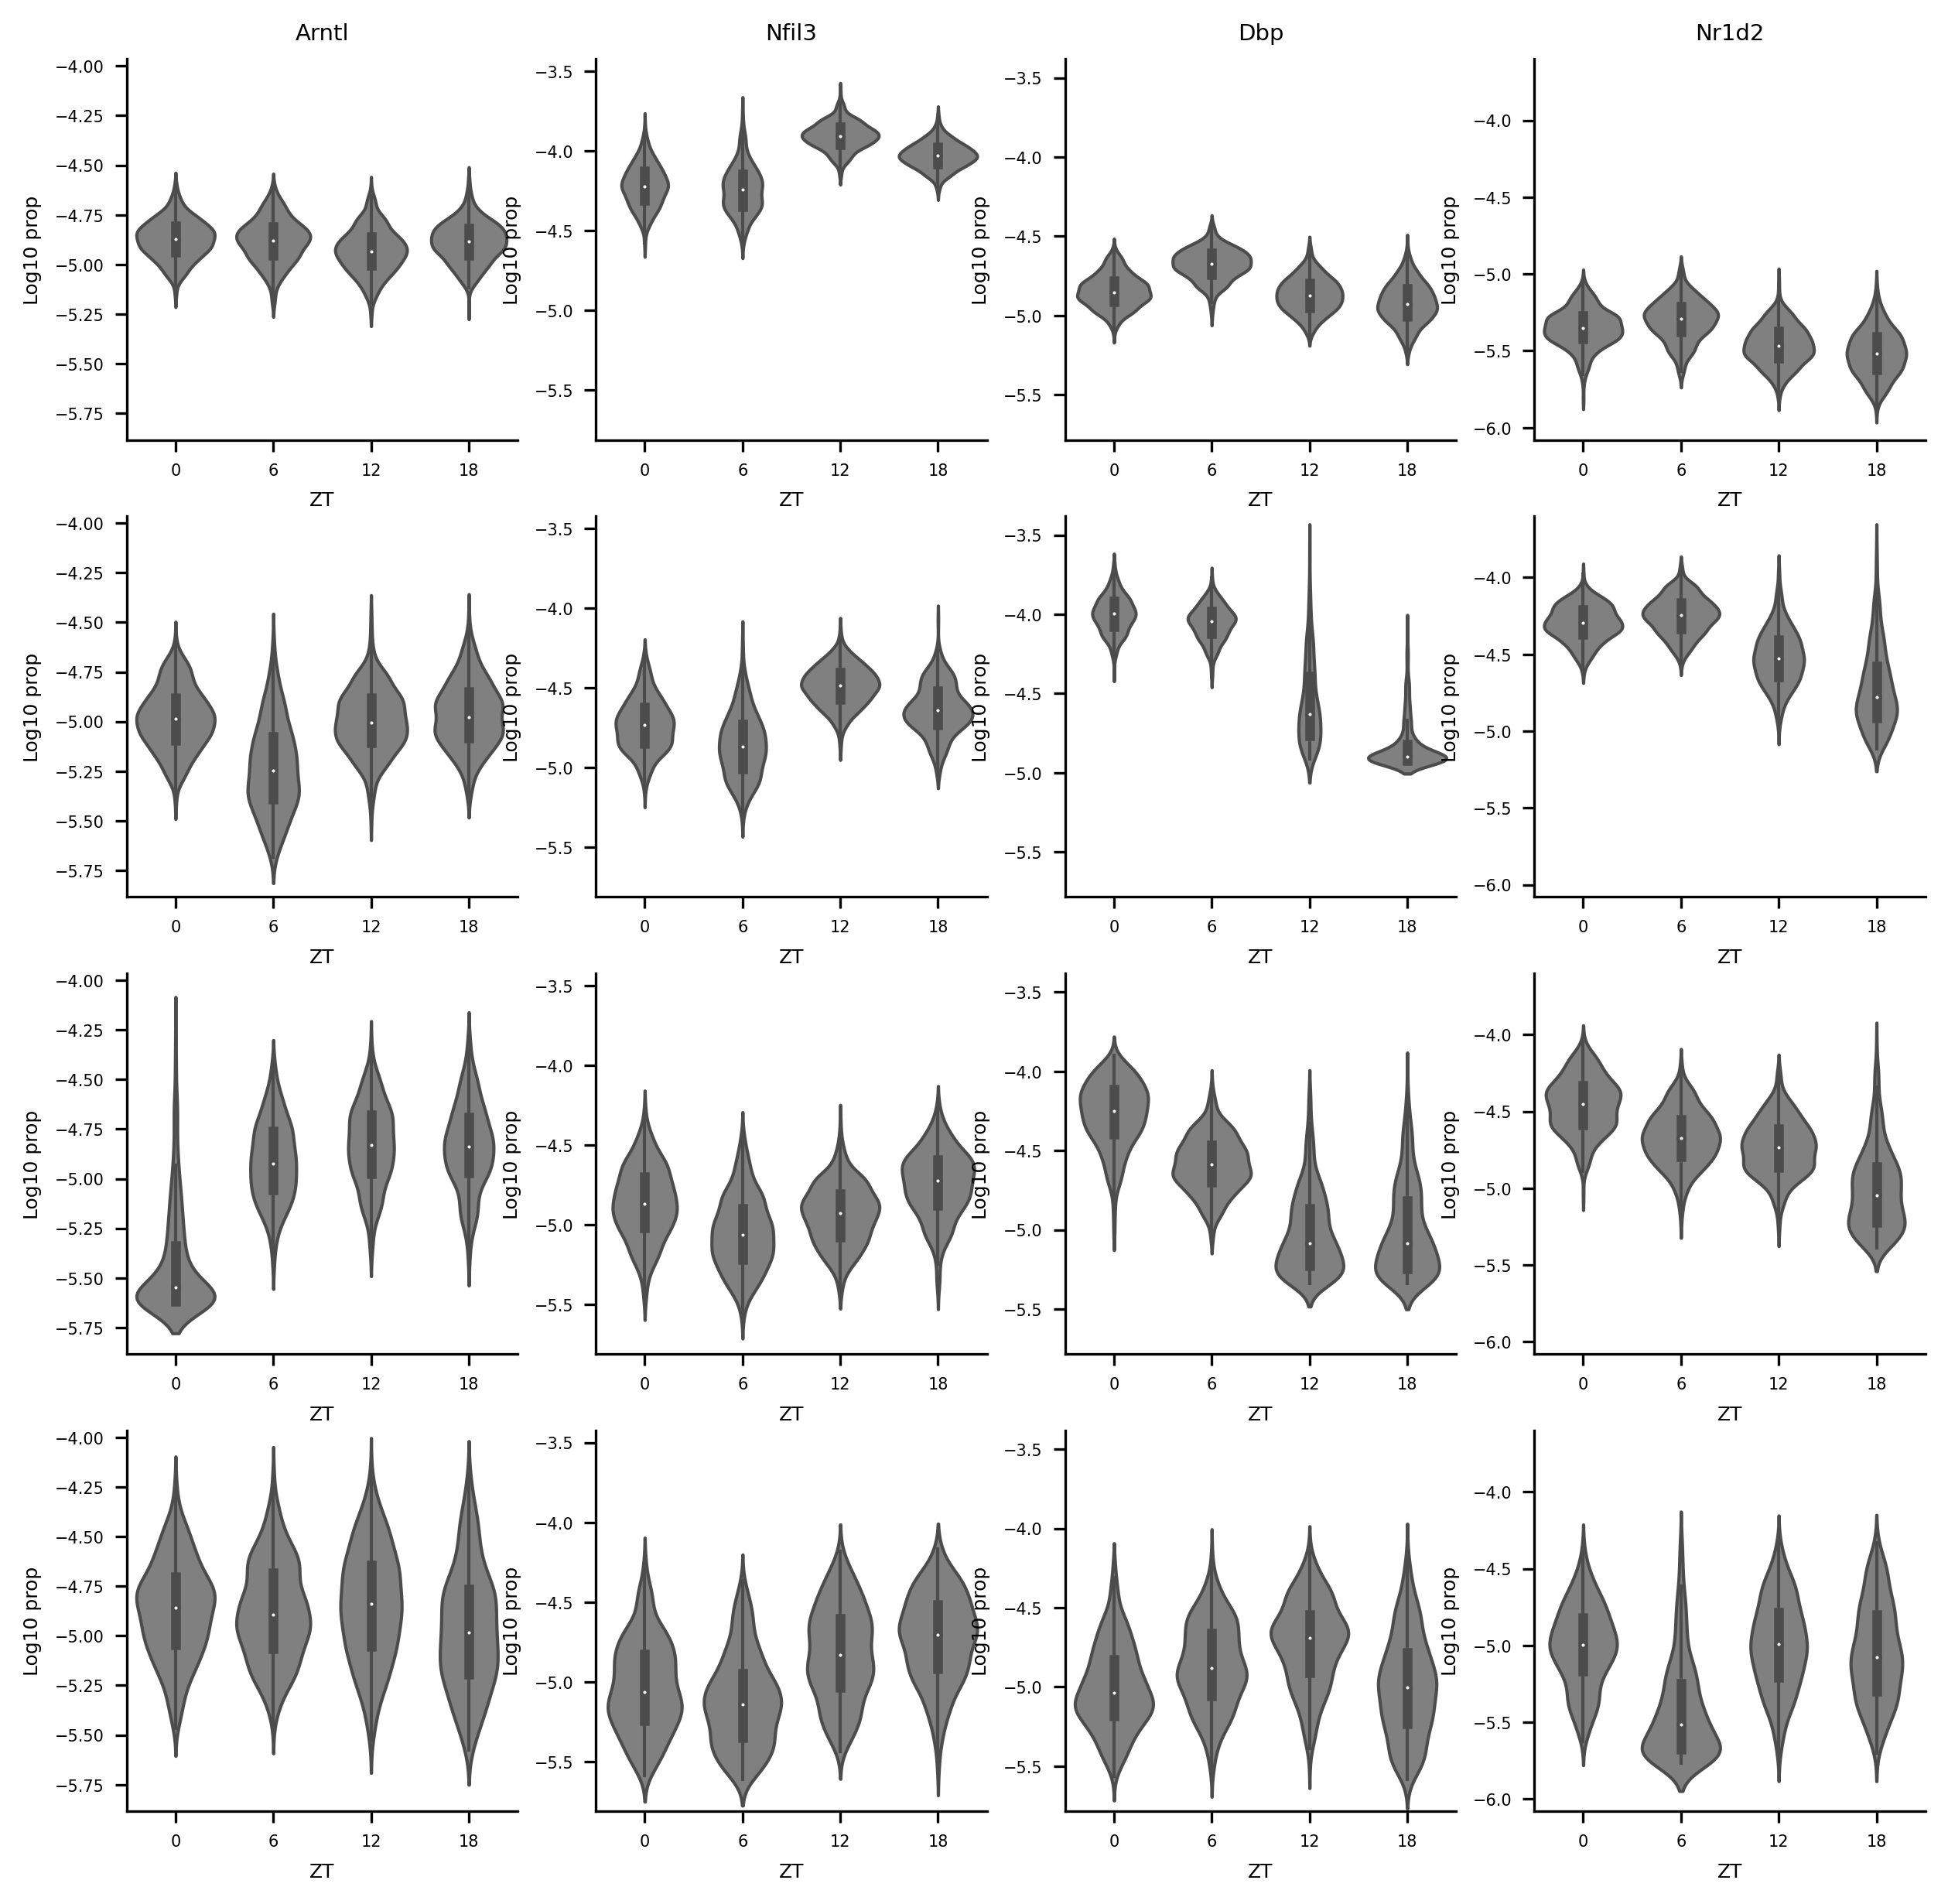

In [92]:
# --- VIZ CORE CLOCK GENES OVER CELL TYPES ---


import torch

clock_genes = ['Arntl', 'Nfil3', 'Dbp', 'Nr1d2']
condition = description


# ** init fig **
fig, axs = plt.subplots(nrows=len(clusters),ncols=len(clock_genes),figsize = (10,10),dpi=300)

# ** init min, max val lists for each gene **
gene_min_log10_vals, gene_max_log10_vals = np.ones((len(clock_genes))) * np.inf, np.ones((len(clock_genes))) * -1 * np.inf

# ** make the violins
for z,cluster in enumerate(clusters):
    
    # get the clock sampled log prop for the cluster
    clock_sampled_log_prop,clock_genes_with_params = helper_functions.get_log_prop_samples(cluster,description,num_waveform_samples,cluster_description_folder_out_dict,gene_list=clock_genes)

    
    for y,gene in enumerate(clock_genes):
    
        
        try:
    
            # get gene index in sampled_log_prop
            gene_index = np.where(np.array(clock_genes_with_params) == gene)[0].item()


            # update the LOG10 min and max values for the gene
            min_val = torch.min(clock_sampled_log_prop[:,:,gene_index].flatten()).item() / np.log(10)
            max_val = torch.max(clock_sampled_log_prop[:,:,gene_index].flatten()).item() / np.log(10)
            if min_val < gene_min_log10_vals[y]:
                gene_min_log10_vals[y] = min_val
            if max_val > gene_max_log10_vals[y]:
                gene_max_log10_vals[y] = max_val



            # make gene df
            val_mat = clock_sampled_log_prop[:,:,gene_index]
            time_mat = np.zeros((num_waveform_samples, 4))
            time_mat[:,0] = 0
            time_mat[:,1] = 6
            time_mat[:,2] = 12
            time_mat[:,3] = 18
            gene_df = pd.DataFrame()
            gene_df['ZT'] = time_mat.flatten().astype(int)
            gene_df['Log10 prop'] = val_mat.flatten().numpy() / np.log(10)


            # viz
            sns.despine()
            axs[z,y] = sns.violinplot(x="ZT", y="Log10 prop", data=gene_df,ax=axs[z,y],color='0.5')
        except:
            pass

        

# ** for each gene, update the y-axis min and max to be the same for all clusters **

# give ourselves some more wiggle room
margin = 0.2
gene_max_log10_vals = gene_max_log10_vals + margin
gene_min_log10_vals = gene_min_log10_vals - margin
for z,cluster in enumerate(clusters):    
    for y,gene in enumerate(clock_genes):
        axs[z,y].set_ylim((gene_min_log10_vals[y],gene_max_log10_vals[y]))
        
        
# ** add gene titles to columns **  
for y,gene in enumerate(clock_genes):
    axs[0,y].set_title(gene)
        
        
# ** savefig **
fileout = '%s/%s_cell_type_clock_gene_violins.pdf' % (folder_out, condition)
plt.savefig(fileout,bbox_inches='tight')


# ** show **
plt.show()














In [93]:
# --- GET SMC CYCLERS (AND DAWN / DUSK) AND SMC PHENOTYPIC SWITCHIN GENES (AND UP / DOWN) ----

# ** SMC cyclers **

# cycler
smc_cyclers = list(cluster_cycler_metric_dfs[0].index)

# # dawn
# smc_dawn_cyclers = list(cluster_cycler_metric_dfs[0][cluster_cycler_metric_dfs[0]['is_dawn_cycler']].index)

# # dusk
# smc_dusk_cyclers = list(cluster_cycler_metric_dfs[0][~cluster_cycler_metric_dfs[0]['is_dawn_cycler']].index)

# ** SMC phenotypic switching genes **

# DE
smc_switching_de_path = '%s/dropbox/athero_data/preprocessed/RPS001-RPS002-RPS003-RPS004-RPS007-RPS008-RPS011-RPS012_scale_True_zero-centered_True_scale-per-batch_False_sample-min-disp_3.0_zsgreen-min_disp_3.0_all-min-disp_0.7/desc_results/subject_RPS001-RPS002-RPS003-RPS004-RPS007-RPS008-RPS011-RPS012_dims_128_resolution_0.35_tol_0.005_run_0/pseudotime_X_velocity_results/nichenet_pseudotime-pseudotime_2_numbins-11_binsubset-[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]_startdebins-[0]_enddebins-[4]/de_genes.txt' % head_folder
with open(smc_switching_de_path) as file_obj:
    smc_switching_de_genes = list(map(lambda x: x.replace('\n',""), file_obj.readlines()))

# down
smc_switching_down_path = '%s/dropbox/athero_data/preprocessed/RPS001-RPS002-RPS003-RPS004-RPS007-RPS008-RPS011-RPS012_scale_True_zero-centered_True_scale-per-batch_False_sample-min-disp_3.0_zsgreen-min_disp_3.0_all-min-disp_0.7/desc_results/subject_RPS001-RPS002-RPS003-RPS004-RPS007-RPS008-RPS011-RPS012_dims_128_resolution_0.35_tol_0.005_run_0/pseudotime_X_velocity_results/nichenet_pseudotime-pseudotime_2_numbins-11_binsubset-[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]_startdebins-[0]_enddebins-[4]/down_genes.txt' % head_folder
with open(smc_switching_down_path) as file_obj:
    smc_switching_down_genes = list(map(lambda x: x.replace('\n',""), file_obj.readlines()))

# up
smc_switching_up_path = '%s/Dropbox/athero_data/preprocessed/RPS001-RPS002-RPS003-RPS004-RPS007-RPS008-RPS011-RPS012_scale_True_zero-centered_True_scale-per-batch_False_sample-min-disp_3.0_zsgreen-min_disp_3.0_all-min-disp_0.7/desc_results/subject_RPS001-RPS002-RPS003-RPS004-RPS007-RPS008-RPS011-RPS012_dims_128_resolution_0.35_tol_0.005_run_0/pseudotime_X_velocity_results/nichenet_pseudotime-pseudotime_2_numbins-11_binsubset-[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]_startdebins-[0]_enddebins-[4]/up_genes.txt' % head_folder
with open(smc_switching_up_path) as file_obj:
    smc_switching_up_genes = list(map(lambda x: x.replace('\n',""), file_obj.readlines()))


    
    


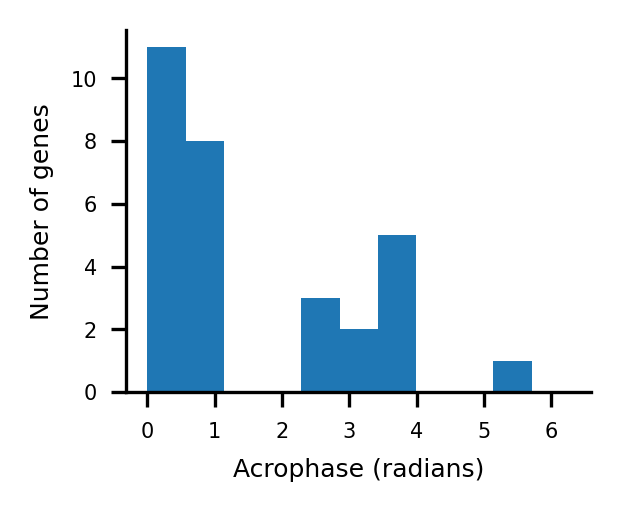

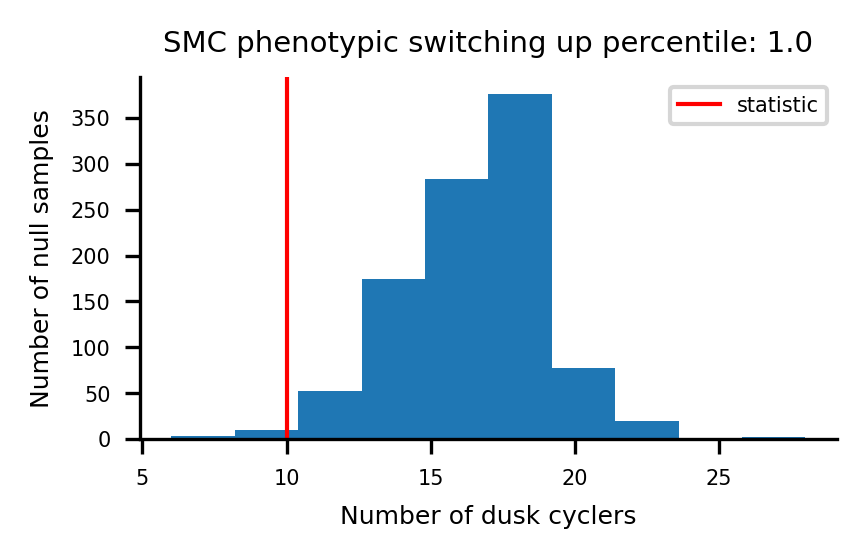

In [94]:
# --- ASSESS IF GENES UPREGULATED DURING VSMC PHENOTYPIC SWITCHING ARE ENRICHED FOR PEAKING IN MIDDLE OF THE DAY ---



# ** get the SMC cyclers and the intersection **
smc_index = 0
df = cluster_metric_dfs[smc_index][cluster_metric_dfs[smc_index]['waveform_over_circadian_component_subtracted_log10_bf'] >= 1]
smc_cyclers = list(df.index)
cycler_smc_up_inter = set(smc_cyclers).intersection(set(smc_switching_up_genes))


# ** viz peak times **
fig,ax = plt.subplots(figsize=(2,1.6),dpi = 300)
plt.hist(df.loc[cycler_smc_up_inter]['expected_acrophase'],bins=np.linspace(0,2*np.pi,12))
sns.despine()
plt.xlabel("Acrophase (radians)")
plt.ylabel("Number of genes")
fileout = '%s/smc_up_dusk_peak_times.pdf' % folder_out
plt.savefig(fileout,bbox_inches='tight')
plt.show()

# ** assess enrichment **

# get the statistic for the gene set of interest
statistic = np.sum(np.array(df.loc[cycler_smc_up_inter]['expected_acrophase'] >= 2) & np.array(df.loc[cycler_smc_up_inter]['expected_acrophase'] <= 4))

# get the null dist
num_shuffles = 1000
null_dist = []
for shuffle in range(0,num_shuffles):
    random_genes = np.random.choice(smc_cyclers,size=len(cycler_smc_up_inter),replace=True)
    random_stat = np.sum(np.array(df.loc[random_genes]['expected_acrophase'] >= (8 / 12) * np.pi) & np.array(df.loc[random_genes]['expected_acrophase'] <= (16 / 12) * np.pi))
    null_dist.append(random_stat)

# viz
fig,ax = plt.subplots(figsize=(3,1.6),dpi = 300)
plt.hist(null_dist)
plt.axvline(x = statistic,c='r',label='statistic')
sns.despine()
percentile = scipy.stats.percentileofscore(null_dist,statistic)
percentile = round(percentile,3)
plt.title("SMC phenotypic switching up percentile: %s" % percentile)
plt.xlabel("Number of dusk cyclers")
plt.ylabel("Number of null samples")
plt.legend()
fileout = '%s/smc_up_dusk_enrichment.pdf' % folder_out
plt.savefig(fileout,bbox_inches='tight')
plt.show()

